In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import partial_dependence,  PartialDependenceDisplay
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, ShuffleSplit
from datetime import datetime
import matplotlib.patches as patches
import joblib
from polyleven import levenshtein
import seaborn as sns
from scipy import stats 
from scipy.stats import t
from sklearn import metrics
import plotly.express as px
import random
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from catboost import CatBoostRegressor, Pool
import multiprocessing
from sklearn.utils import resample

In [2]:
DKcom = pd.read_csv('Final_dataset.csv')
DKcom['Date'] = pd.to_datetime(DKcom['Date'])
DKcom = DKcom[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','LD_interaction',
               'pct','Hospitalization','log_weekly_hospitalization', 'weekly_hospitalization','chain','Date','chain_size',
                'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
DKcom['vcr_lagged'].fillna(0, inplace=True)
DKcom['CHI_lagged'].fillna(21.43, inplace=True)
DKcom.loc[DKcom['chain'] == 'Simulation', 'pct_reif'] = 65
DKcom.loc[DKcom['chain'] == 'Simulation', 'ContainmentHealthIndex_Average'] = 21.43
DKcom.loc[DKcom['chain'] == 'Simulation', 'chain_size'] = 27
DKcom['CH_week'] = DKcom['CHI_lagged'] * DKcom['week_num'] 
DKcom['Month'] = DKcom['Date'].dt.month.astype(int)
DKcom['Quarter'] = DKcom['Date'].dt.quarter.astype('category')
DKcom['year'] = DKcom['Date'].dt.year.astype(int)
DKcom['week'] = DKcom['Date'].dt.isocalendar().week.astype('category')
DKcom['LD_vac2'] = DKcom['LD_vac']
DKcom['LD_interaction'] = DKcom['LD_vac'] * DKcom['LD1']
DKcom = DKcom[DKcom['chain_size'] > 3 ]
DKcom['vcr_LDvac'] = DKcom['vcr_lagged'] * DKcom['LD_vac']
DKcom['CH_week'] = DKcom['CHI_lagged'] * DKcom['week_num']
DKcom['CHI_lagged2'] = DKcom['CHI_lagged']
DKcom['vcr_lagged2']   = DKcom['vcr_lagged']
DKcom['sq_weekly_hospitalization'] = np.sqrt(DKcom['weekly_hospitalization'])
DKcom['log_weekly_hospitalization'] = np.log(DKcom['weekly_hospitalization'])
DKcom['chain'] = DKcom['chain'].astype('str')
DKcom['chain'] = DKcom['chain'].str.replace('.0', '', regex=False)
DKcom.loc[DKcom['chain'] == '412', 'LD_vac'] = 6
DKcom.sort_values(by=['Date', 'chain'], inplace=True)
print(DKcom.head())

   LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3    1       2.0       2         0.0      1.0         1   52.380000   
4    1       6.0       2         0.0      1.0         2   52.380000   
5    1       2.0       2         0.0      1.0         3   50.680000   
6    1       2.0       2         0.0      1.0         4   51.022857   
7    1       2.0       2         0.0      1.0         5   51.790000   

   LD_interaction  pct  Hospitalization  ...     CH_week  Month Quarter  year  \
3               2  1.0             23.0  ...   52.380000      6       2  2020   
4               2  1.0             17.0  ...  104.760000      7       3  2020   
5               2  1.0             12.0  ...  152.040000      7       3  2020   
6               2  1.0             18.0  ...  204.091429      7       3  2020   
7               2  1.0             19.0  ...  258.950000      7       3  2020   

   week  LD_vac2  vcr_LDvac  CHI_lagged2  vcr_lagged2  \
3    27        2        0.0  

In [3]:
# Replace values in the 'chain' column
DKcom['chain2'] = DKcom['chain']
DKcom['chain'] = DKcom['chain'].replace({'37': '29', '412': '378'})
max_week_num_29 = DKcom.loc[DKcom['chain2'] == '29', 'week_num'].max()
max_week_num_378 = DKcom.loc[DKcom['chain2'] == '378', 'week_num'].max()

# Step 2: Update `week_num` values for chain 37 and chain 412
DKcom.loc[DKcom['chain2'] == '37', 'week_num'] += max_week_num_29
DKcom.loc[DKcom['chain2'] == '412', 'week_num'] += max_week_num_378
# Update LD1 values based on the changes in the 'chain' column
DKcom.loc[DKcom['chain'] == '29', 'LD1'] = 1
DKcom.loc[DKcom['chain'] == '378', 'LD1'] = 2

In [4]:
print(DKcom['chain'].unique())

['20' '29' '53' '100' '105' '123' '125' '151' '216' '257' '265' '303'
 '378' '418' 'Simulation']


In [5]:
DKcom1 = DKcom[DKcom['chain']!= 'Simulation']
DKcom1.describe()

,LD1,pct_reif,LD_vac,vcr_lagged,HR_hosp,week_num,CHI_lagged,LD_interaction,pct,Hospitalization,...,chain_size,ContainmentHealthIndex_Average,CH_week,Month,year,LD_vac2,vcr_LDvac,CHI_lagged2,vcr_lagged2,sq_weekly_hospitalization
count,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000,...,233.000000,0.0,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000,233.000000
mean,10.373391,18.446352,15.004292,26.665836,1.216652,10.369099,36.411527,266.017167,0.677079,379.107296,...,17.944206,NaN,328.003041,6.716738,2021.776824,14.965665,568.469823,36.411527,26.665836,13.546007
std,12.435439,18.417989,12.099978,22.365415,0.492598,6.828016,16.995001,455.634514,0.316455,365.455209,...,6.883975,NaN,280.508790,3.755057,1.017932,12.131415,755.667055,16.995001,22.365415,7.655176
min,1.000000,0.000000,1.000000,0.000000,0.920000,1.000000,21.430000,0.000000,0.020075,12.000000,...,6.000000,NaN,21.430000,1.000000,2020.000000,1.000000,0.000000,21.430000,0.000000,1.299928
25%,1.000000,1.000000,5.000000,3.601411,0.920000,5.000000,21.430000,6.000000,0.451289,156.000000,...,10.000000,NaN,128.580000,3.000000,2021.000000,5.000000,31.197945,21.430000,3.601411,8.306624
50%,5.000000,8.000000,11.000000,29.516994,0.920000,9.000000,21.430000,40.000000,0.800069,260.000000,...,19.000000,NaN,258.950000,7.000000,2022.000000,11.000000,161.994971,21.430000,29.516994,12.083046
75%,15.000000,40.000000,20.000000,32.436485,1.640000,16.000000,51.190000,270.000000,0.969697,521.000000,...,24.000000,NaN,412.902857,10.000000,2023.000000,20.000000,648.687136,51.190000,32.436485,17.349352
max,42.000000,49.000000,41.000000,68.246700,2.280000,27.000000,68.570000,1722.000000,1.000000,2326.000000,...,27.000000,NaN,1397.020000,12.000000,2024.000000,41.000000,2286.532348,68.570000,68.246700,43.138849


In [6]:
scaler = MinMaxScaler(feature_range=(0, 100))  # Default range is [0, 1]
DKcom1['CH_week2'] = DKcom1['CH_week']
DKcom1['CH_week'] = scaler.fit_transform(DKcom1[['CH_week']])


/tmp/ipykernel_3896390/2036684335.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DKcom1['CH_week2'] = DKcom1['CH_week']
/tmp/ipykernel_3896390/2036684335.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DKcom1['CH_week'] = scaler.fit_transform(DKcom1[['CH_week']])


In [7]:
DKcom1['CH_week'].describe()

count    233.000000
mean      22.286658
std       20.391889
min        0.000000
25%        7.789385
50%       17.266773
75%       28.458542
max      100.000000
Name: CH_week, dtype: float64

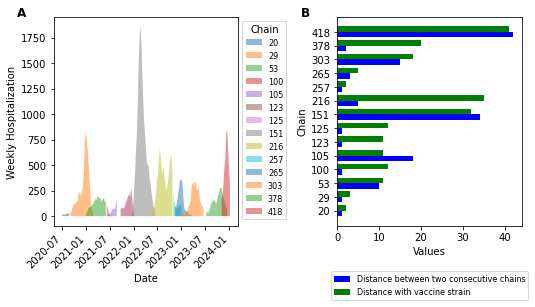

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 10

# Create figure: 1 row, 2 columns. 
# 7.5 inches is the max width for PLOS journals; 4.5 inches is a good proportional height.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 4.5))

# --- 2. Panel A: Area Plot (Chain Hospitalization) ---
# Assuming 'data' dataframe is already loaded in your environment
DKcomd = DKcom1.sort_values('Date')
groups = DKcom1['chain'].unique()

for chain in groups:
    df_group = DKcom1[DKcom1['chain'] == chain]
    ax1.fill_between(df_group['Date'], df_group['weekly_hospitalization'], label=chain, alpha=0.5)

ax1.set_xlabel('Date')
ax1.set_ylabel('Weekly Hospitalization')
ax1.legend(title='Chain', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

# Rotate date labels so they don't overlap
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Add PLOS required 'A' label
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')


# --- 3. Panel B: Horizontal Bar Graph (Distances) ---
unique_df = DKcom1.drop_duplicates(subset='chain')
unique_df = unique_df[unique_df['chain'] != 'Simulation']

bar_width = 0.4
indices = np.arange(len(unique_df))

# Plot LD1
ax2.barh(indices - bar_width/2, unique_df['LD1'], height=bar_width, color='blue', label='Distance between two consecutive chains')

# Plot LD_vac
ax2.barh(indices + bar_width/2, unique_df['LD_vac'], height=bar_width, color='green', label='Distance with vaccine strain')

# Customize y-axis labels
y_labels = unique_df['chain'].tolist()
ax2.set_yticks(indices)
ax2.set_yticklabels(y_labels)

ax2.set_xlabel('Values')
ax2.set_ylabel('Chain')
ax2.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.2))
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

# --- 4. Layout Optimization & Saving ---
# tight_layout ensures legends and labels don't get cut off
plt.tight_layout()

# Save as TIFF, 300 DPI, with LZW compression
plt.savefig(
    'Fig4.tif', 
    format='tif', 
    dpi=300, 
    bbox_inches='tight', 
    pil_kwargs={"compression": "tiff_lzw"}
)

# Display the plot
plt.show()

In [8]:
X = DKcom1[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
            'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
           
#y = DKcom1 ['weekly_hospitalization']
y = DKcom1 ['log_weekly_hospitalization']
# Assuming X and y are your features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=322)



In [9]:
# Define the parameter grid
param_grid = {
    'iterations': [500, 1000, 2000],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [2,4, 6],
    'l2_leaf_reg': [5,10,15,20],
    'loss_function': ['RMSE'],
    'eval_metric': ['RMSE'],
    'random_state': [42]
}

# Create the CatBoostRegressor
cat_model = CatBoostRegressor(verbose=0)

# Define cross-validation scheme
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=cat_model, param_grid=param_grid, cv=cv, scoring='r2', n_jobs=-1,
    verbose=1)




In [10]:
# Fit the GridSearchCV object
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_cat_model = grid_search.best_estimator_
print("Best Parameters:", best_params)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.1, 'loss_function': 'RMSE', 'random_state': 42}


In [11]:
y_pred = best_cat_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Best Parameters:", best_params)
print("Test MAE:", mae)
print("Test R-squared:", r2)
print("Test MAPE:", mape)
print("Test RMSE:", rmse)

Best Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.1, 'loss_function': 'RMSE', 'random_state': 42}
Test MAE: 0.29135762062355175
Test R-squared: 0.8484557093471573
Test MAPE: 0.07625372405516305
Test RMSE: 0.41225856925317095


In [12]:
current_params = best_cat_model.get_params()
print("Current Parameters:", current_params)

# Update the l2_leaf_reg parameter
current_params['l2_leaf_reg'] = 5 
current_params['depth'] = 6 
current_params['learning_rate'] = 0.1
current_params['iterations'] = 1000

# Create a new model with updated parameters
updated_cat_model = CatBoostRegressor(**current_params)

X_train_train, X_val, y_train_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=21)

updated_cat_model.fit(X_train_train, y_train_train,
                      eval_set=(X_val, y_val),
                      early_stopping_rounds=100, 
                      verbose=100)
# Make predictions on the test set
y_pred = updated_cat_model.predict(X_val)

# Evaluate the model
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("Updated Parameters:", current_params)
print("Test MAE:", mae)
print("Test R-squared:", r2)


Current Parameters: {'iterations': 2000, 'learning_rate': 0.1, 'depth': 4, 'l2_leaf_reg': 15, 'loss_function': 'RMSE', 'verbose': 0, 'eval_metric': 'RMSE', 'random_state': 42}
0:	learn: 1.1673770	test: 1.1263375	best: 1.1263375 (0)	total: 6.03ms	remaining: 6.02s
100:	learn: 0.2545788	test: 0.4988611	best: 0.4988611 (100)	total: 237ms	remaining: 2.11s
200:	learn: 0.1194467	test: 0.4483914	best: 0.4483759 (195)	total: 444ms	remaining: 1.76s
300:	learn: 0.0713625	test: 0.4380486	best: 0.4375509 (294)	total: 667ms	remaining: 1.55s
400:	learn: 0.0496128	test: 0.4333507	best: 0.4333507 (400)	total: 888ms	remaining: 1.32s
500:	learn: 0.0360047	test: 0.4317356	best: 0.4314864 (457)	total: 1.11s	remaining: 1.11s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4314864167
bestIteration = 457

Shrink model to first 458 iterations.
Updated Parameters: {'iterations': 1000, 'learning_rate': 0.1, 'depth': 6, 'l2_leaf_reg': 5, 'loss_function': 'RMSE', 'verbose': 0, 'eval_metric': '

In [13]:
cv_scores_train = cross_val_score(updated_cat_model, X_train, y_train, cv=cv, 
                                  scoring='r2', verbose =0)

# Print the cross-validation scores
print("Cross-Validation Scores:", cv_scores_train)
print("Mean CV Score:", cv_scores_train.mean())
print("Standard Deviation of CV Scores:", cv_scores_train.std())



Cross-Validation Scores: [0.79530046 0.69642247 0.84821368 0.90739004 0.77972342]
Mean CV Score: 0.8054100138858911
Standard Deviation of CV Scores: 0.07052995094928777


In [14]:
# Make predictions on the test set
y_pred = updated_cat_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Best Parameters:", best_params)
print("Test MAE:", mae)
print("Test R-squared:", r2)
print("Test MAPE:", mape)
print("Test RMSE:", rmse)

Best Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.1, 'loss_function': 'RMSE', 'random_state': 42}
Test MAE: 0.3082272213164556
Test R-squared: 0.8513437000238497
Test MAPE: 0.07767694854339999
Test RMSE: 0.40831145275861624


In [15]:
y_pred_log = updated_cat_model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)

# Evaluate the model
mape = mean_absolute_percentage_error(y_test_real, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

print("Updated Parameters:", current_params)
print("Test MAPE:", mape)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R-squared:", r2)

Updated Parameters: {'iterations': 1000, 'learning_rate': 0.1, 'depth': 6, 'l2_leaf_reg': 5, 'loss_function': 'RMSE', 'verbose': 0, 'eval_metric': 'RMSE', 'random_state': 42}
Test MAPE: 35.17432336251751
Test RMSE: 68.12591085203437
Test MAE: 45.45029836306853
Test R-squared: 0.8254391502705253


In [16]:
# --- 1. Generate Predictions ---
y_train_pred_log = updated_cat_model.predict(X_train)
y_train_pred = np.exp(y_train_pred_log) 
y_train_real = np.exp(y_train)

y_pred_log = updated_cat_model.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)


# --- 2. Calculate Metrics (Log Scale) ---
train_mae_log = mean_absolute_error(y_train, y_train_pred_log)
test_mae_log = mean_absolute_error(y_test, y_pred_log)

train_rmse_log = np.sqrt(mean_squared_error(y_train, y_train_pred_log))
test_rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))

train_mape_log = mean_absolute_percentage_error(y_train, y_train_pred_log)
test_mape_log = mean_absolute_percentage_error(y_test, y_pred_log)

train_r2_log = r2_score(y_train, y_train_pred_log)
test_r2_log = r2_score(y_test, y_pred_log)


# --- 3. Calculate Metrics (Original Scale) ---
train_mae = mean_absolute_error(y_train_real, y_train_pred)
test_mae = mean_absolute_error(y_test_real, y_pred)

train_rmse = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

train_mape = mean_absolute_percentage_error(y_train_real, y_train_pred)*100
test_mape = mean_absolute_percentage_error(y_test_real, y_pred)*100

train_r2 = r2_score(y_train_real, y_train_pred)
test_r2 = r2_score(y_test_real, y_pred)


# --- 4. Dataset Baselines ---
log_min = DKcom1['log_weekly_hospitalization'].min()
log_avg = DKcom1['log_weekly_hospitalization'].mean()

orig_min = DKcom1['weekly_hospitalization'].min()
orig_avg = DKcom1['weekly_hospitalization'].mean()


# --- 5. Print Results ---
print("--- Log-Transformed Scale ---")
print(f"Minimum: {log_min:.2f}")
print(f"Average: {log_avg:.2f}")
print(f"Train MAE:  {train_mae_log:.2f}")
print(f"Test MAE:   {test_mae_log:.2f}")
print(f"Train RMSE: {train_rmse_log:.2f}")
print(f"Test RMSE:  {test_rmse_log:.2f}")
print(f"Train MAPE: {train_mape_log * 100:.2f}%")
print(f"Test MAPE:  {test_mape_log * 100:.2f}%")
print(f"Train R2:   {train_r2_log:.3f}")
print(f"Test R2:    {test_r2_log:.3f}\n")

print("\n--- Original Scale (Hospitalizations) ---")
print(f"Minimum: {orig_min:.2f}")
print(f"Average: {orig_avg:.2f}")
print(f"Train MAE:  {train_mae:.2f}")
print(f"Test MAE:   {test_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")
print(f"Train MAPE: {train_mape :.2f}%")
print(f"Test MAPE:  {test_mape :.2f}%")
print(f"Train R2:   {train_r2:.3f}")
print(f"Test R2:    {test_r2:.3f}\n")


--- Log-Transformed Scale ---
Minimum: 0.52
Average: 4.90
Train MAE:  0.10
Test MAE:   0.31
Train RMSE: 0.20
Test RMSE:  0.41
Train MAPE: 2.36%
Test MAPE:  7.77%
Train R2:   0.972
Test R2:    0.851


--- Original Scale (Hospitalizations) ---
Minimum: 1.69
Average: 241.84
Train MAE:  15.72
Test MAE:   45.45
Train RMSE: 31.73
Test RMSE:  68.13
Train MAPE: 10.71%
Test MAPE:  35.17%
Train R2:   0.990
Test R2:    0.825



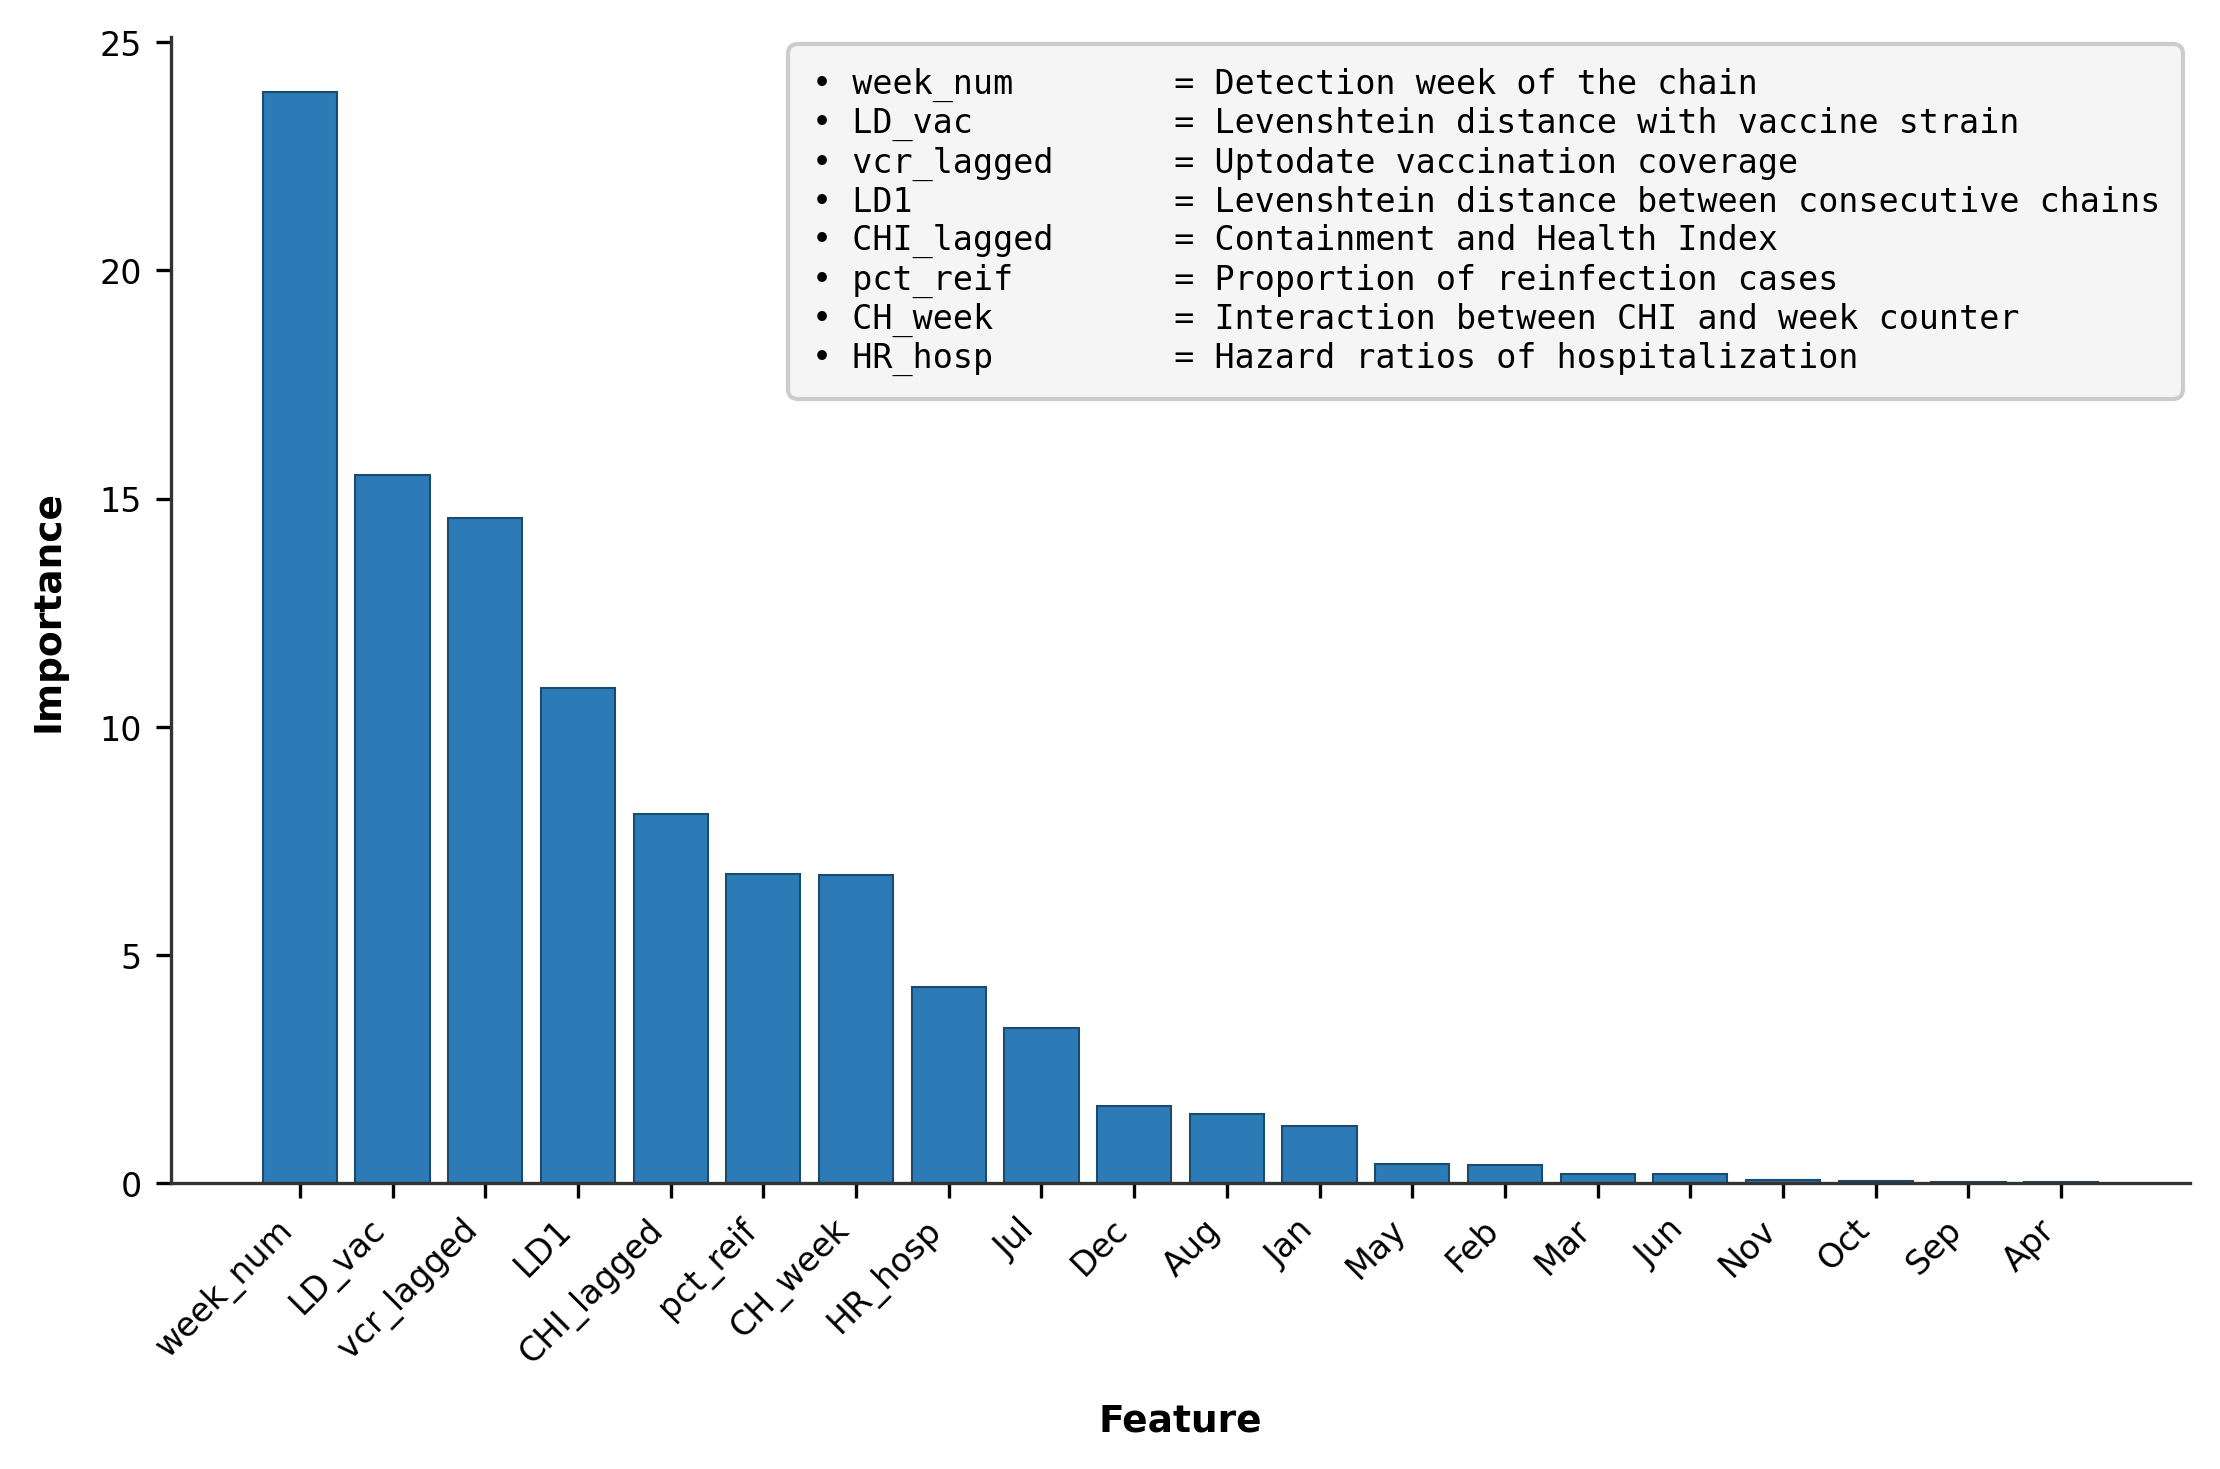

In [18]:
from matplotlib.offsetbox import AnchoredText

importances = updated_cat_model.feature_importances_

feature_names = X.columns

# Create a DataFrame for easier plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


# Your formatted description with aligned equal signs and bullet points
textbox = (
    "• week_num        = Detection week of the chain\n"
    "• LD_vac          = Levenshtein distance with vaccine strain\n"
    "• vcr_lagged      = Uptodate vaccination coverage\n"
    "• LD1             = Levenshtein distance between consecutive chains\n"
    "• CHI_lagged      = Containment and Health Index\n"
    "• pct_reif        = Proportion of reinfection cases\n"
    "• CH_week         = Interaction between CHI and week counter\n"
    "• HR_hosp         = Hazard ratios of hospitalization"
)


# 1. Dimensions: 
fig, ax = plt.subplots(figsize=(7.5, 5.0), dpi=300)

# Set global font to Arial or Helvetica (PLOS approved)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Plot the feature importance
ax.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='#2c7bb6', edgecolor='#1a4a6e', linewidth=0.5)

# 2. Text Box: Adjusted to approved monospace font and compliant 8pt size
anchored_text = AnchoredText(
    textbox, 
    loc='upper right', 
    prop={'fontsize': 8, 'family': 'monospace'}, 
    frameon=True
)
anchored_text.patch.set_boxstyle("round,pad=0.3")
anchored_text.patch.set_facecolor('#f5f5f5')
anchored_text.patch.set_edgecolor('#cccccc')
ax.add_artist(anchored_text)

# 3. Font Sizes: Set to 8pt/9pt to meet PLOS readability standards
ax.set_xlabel('Feature', fontsize=9, fontweight='bold', labelpad=8)
ax.set_ylabel('Importance', fontsize=9, fontweight='bold', labelpad=8)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)

# Clean up top and right spines for a modern, high-quality journal look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# 4. Correct Layout Sequence: tight_layout MUST come before savefig
plt.tight_layout()

# 5. File Export: PLOS specifies naming as 'Fig[Num].tif' and explicit 300+ DPI minimum 
plt.savefig('Fig5.tif', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

In [20]:

# 4. Save the Model
cbmodel2 = "catboost_model.joblib"  # Choose a filename
joblib.dump(updated_cat_model, cbmodel2)
print(f"Model saved to {cbmodel2}")



Model saved to catboost_model.joblib


Sensitivity Analyses

Time only Model

In [22]:
X = DKcom1[['week_num', 'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
           
y = DKcom1 ['log_weekly_hospitalization']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=322)

In [23]:
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params_t = grid_search.best_params_
best_cat_model_t = grid_search.best_estimator_
print("Best Parameters:", best_params_t)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.2, 'loss_function': 'RMSE', 'random_state': 42}


In [24]:
y_pred_log = best_cat_model_t.predict(X_test)
y_pred_t = np.exp(y_pred_log)
y_test_real = np.exp(y_test)
# Evaluate the model
rmse_t = np.sqrt(mean_squared_error(y_test_real, y_pred_t))
mape_t = mean_absolute_percentage_error(y_test_real, y_pred_t) * 100
mae_t = mean_absolute_error(y_test_real, y_pred_t)
r2_t = r2_score(y_test_real, y_pred_t)

print("Final Parameters:", best_params_t)
print("Test RMSE: ", rmse_t)
print("Test MAPE:", mape_t)
print("Test MAE:", mae_t)
print("Test R-squared:", r2_t)

Final Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.2, 'loss_function': 'RMSE', 'random_state': 42}
Test RMSE:  144.3653865365633
Test MAPE: 114.75940888287512
Test MAE: 91.10023578117499
Test R-squared: 0.2161222099908613


Time + Genetic distance model

In [25]:
X = DKcom1[['LD1','LD_vac','week_num',
            'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
           
y = DKcom1 ['log_weekly_hospitalization']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=322)

grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params_tg = grid_search.best_params_
best_cat_model_tg = grid_search.best_estimator_
print("Best Parameters:", best_params_tg)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.2, 'loss_function': 'RMSE', 'random_state': 42}


In [26]:
y_pred_log = best_cat_model_tg.predict(X_test)
y_pred_tg = np.exp(y_pred_log)
y_test_real = np.exp(y_test)
# Evaluate the model
rmse_tg = np.sqrt(mean_squared_error(y_test_real, y_pred_tg))
mape_tg = mean_absolute_percentage_error(y_test_real, y_pred_tg) * 100
mae_tg = mean_absolute_error(y_test_real, y_pred_tg)
r2_tg = r2_score(y_test_real, y_pred_tg)

print("Final Parameters:", best_params_tg)
print("Test MAPE:", mape_tg)
print("Test RMSE: ", rmse_tg)
print("Test MAE:", mae_tg)
print("Test R-squared:", r2_tg)

Final Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.2, 'loss_function': 'RMSE', 'random_state': 42}
Test MAPE: 45.875716551587274
Test RMSE:  70.10701481104049
Test MAE: 41.74488768534245
Test R-squared: 0.815139061462582


Model without genetic distances

In [27]:
X = DKcom1[['pct_reif', 'vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
            'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
           
y = DKcom1 ['log_weekly_hospitalization']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=322)
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params_to = grid_search.best_params_
best_cat_model_to = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [28]:
y_pred_log = best_cat_model_to.predict(X_test)
y_pred_to = np.exp(y_pred_log)
y_test_real = np.exp(y_test)

params = best_cat_model_to.get_params()
# Evaluate the model
rmse_to = np.sqrt(mean_squared_error(y_test_real, y_pred_to))
mape_to = mean_absolute_percentage_error(y_test_real, y_pred_to) * 100
mae_to = mean_absolute_error(y_test_real, y_pred_to)
r2_to = r2_score(y_test_real, y_pred_to)

print("Final Parameters:", best_params_to)
print("Test MAPE:", mape_to)
print("Test RMSE:", rmse_to)
print("Test MAE:", mae_to)
print("Test R-squared:", r2_to)

Final Parameters: {'depth': 6, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 5, 'learning_rate': 0.01, 'loss_function': 'RMSE', 'random_state': 42}
Test MAPE: 52.24584701810515
Test RMSE: 93.64757071948085
Test MAE: 60.43872012846516
Test R-squared: 0.6701509516292377


Model comparison

In [33]:
data = {
    'Model': ['Model - Time only', 'Full Model excluding genetic distance', 'Model - Time + Genetic distance', 'Full Model'],
    'R2': [r2_t, r2_to, r2_tg,  test_r2],
    'MAE': [mae_t, mae_to, mae_tg, test_mae],
    'RMSE': [rmse_t, rmse_to, rmse_tg, test_rmse],
    'MAPE': [mape_t, mape_to, mape_tg, test_mape]
}

# 2. Convert directly to a DataFrame and set the index
metrics_df = pd.DataFrame(data).set_index('Model')

# 3. Print the result rounded to 3 decimal places
print(metrics_df.round(3))

                                          R2     MAE     RMSE     MAPE
Model                                                                 
Model - Time only                      0.216  91.100  144.365  114.759
Full Model excluding genetic distance  0.670  60.439   93.648   52.246
Model - Time + Genetic distance        0.815  41.745   70.107   45.876
Full Model                             0.825  45.450   68.126   35.174


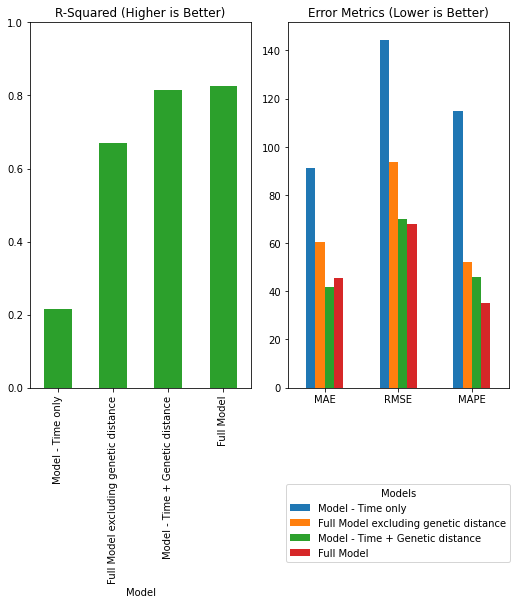

In [34]:
plt.rcParams['font.size'] = 10

# 2. Adjust figsize to fit PLOS max width of 7.5 inches
fig, axes = plt.subplots(1, 2, figsize=(7.5, 8.5))

# Plot R2 
metrics_df[['R2']].plot(kind='bar', ax=axes[0], color='#2ca02c', legend=False)
axes[0].set_title('R-Squared (Higher is Better)')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=90)

# Plot MAE, RMSE, and MAPE 
metrics_df[['MAE', 'RMSE', 'MAPE']].T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Error Metrics (Lower is Better)')
axes[1].tick_params(axis='x', rotation=0) # Set to 0 since there are only 3 metrics to read
axes[1].legend(title='Models', loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=1)

plt.tight_layout()

# Save as TIFF with PLOS requirements: 600 DPI and LZW compression
plt.savefig('sensitivity.tif', 
            format='tiff', 
            dpi=600, 
            bbox_inches='tight', 
            pil_kwargs={"compression": "tiff_lzw"})

plt.show()

Lagged variant proportions for hospitalizations

In [35]:
DKcom1['Date'] = pd.to_datetime(DKcom1['Date'])
DKcom1 = DKcom1.sort_values(by=['chain', 'Date'])
DKcom1['weekly_hospitalization2'] = DKcom1['Hospitalization'] * DKcom1['pct']
DKcom1['week_num_lag1'] = DKcom1.groupby('chain')['week_num'].shift(1)
DKcom1['week_num_lag2'] = DKcom1.groupby('chain')['week_num'].shift(2)

DKcom1['pct_lag1'] = DKcom1.groupby('chain')['pct'].shift(1)
DKcom1['Hospitalization_lag1'] = DKcom1.groupby('chain')['Hospitalization'].shift(1)

DKcom1['pct_lag2'] = DKcom1.groupby('chain')['pct'].shift(2)
DKcom1['Hospitalization_lag2'] = DKcom1.groupby('chain')['Hospitalization'].shift(2)

DKcom1['log_l1_weekly_hospitalization'] = np.log(DKcom1['Hospitalization_lag1'])
DKcom1['log_l2_weekly_hospitalization'] = np.log(DKcom1['Hospitalization_lag2'])
DKcom1

,LD1,pct_reif,LD_vac,vcr_lagged,HR_hosp,week_num,CHI_lagged,LD_interaction,pct,Hospitalization,...,CH_week2,weekly_hospitalization2,week_num_lag1,week_num_lag2,pct_lag1,Hospitalization_lag1,pct_lag2,Hospitalization_lag2,log_l1_weekly_hospitalization,log_l2_weekly_hospitalization
59,1,1.0,12,19.680670,1.64,1,57.910000,12,0.966832,117.0,...,57.910000,113.119307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,1,1.0,12,21.489578,1.64,2,59.248571,12,0.915846,85.0,...,118.497143,77.846911,1.0,NaN,0.966832,117.0,NaN,NaN,4.762174,NaN
61,1,1.0,12,23.406772,1.64,3,59.124286,12,0.657201,54.0,...,177.372857,35.488844,2.0,1.0,0.915846,85.0,0.966832,117.0,4.442651,4.762174
62,1,1.0,12,25.766394,1.64,4,57.451429,12,0.317951,35.0,...,229.805714,11.128288,3.0,2.0,0.657201,54.0,0.915846,85.0,3.988984,4.442651
63,1,1.0,12,29.091762,1.64,5,55.234286,12,0.131360,36.0,...,276.171429,4.728966,4.0,3.0,0.317951,35.0,0.657201,54.0,3.555348,3.988984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54,10,1.0,11,8.488907,1.64,19,65.084286,110,0.954761,168.0,...,1236.601429,160.399900,18.0,17.0,0.954748,145.0,0.962952,184.0,4.976734,5.214936
55,10,1.0,11,9.973673,1.64,20,65.051429,110,0.972245,175.0,...,1301.028571,170.142857,19.0,18.0,0.954761,168.0,0.954748,145.0,5.123964,4.976734
56,10,1.0,11,13.244504,1.64,21,63.891429,110,1.000000,177.0,...,1341.720000,177.000000,20.0,19.0,0.972245,175.0,0.954761,168.0,5.164786,5.123964
57,10,1.0,11,16.132444,1.64,22,62.937143,110,1.000000,136.0,...,1384.617143,136.000000,21.0,20.0,1.000000,177.0,0.972245,175.0,5.176150,5.164786


In [36]:
features = ['LD1', 'pct_reif', 'LD_vac', 'vcr_lagged', 'HR_hosp', 'week_num_lag1', 
            'CHI_lagged', 'CH_week', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',  
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
target = 'log_l1_weekly_hospitalization'

l1_data = DKcom1[features + [target]].copy()

l1_data = l1_data.dropna()

# 4. Now cleanly separate into X and y
X = l1_data[features]
y = l1_data[target]
# Assuming X and y are your features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=322)

# Fit the GridSearchCV object
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params_l1 = grid_search.best_params_
best_cat_model_l1 = grid_search.best_estimator_
print("Best Parameters:", best_params_l1)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.1, 'loss_function': 'RMSE', 'random_state': 42}


In [37]:
# Make predictions on the test set
y_pred = best_cat_model_l1.predict(X_test)

params = best_cat_model_l1.get_params()
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Final Parameters:", best_params)
print("Test MAE:", mae)
print("Test R-squared:", r2)

Final Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.1, 'loss_function': 'RMSE', 'random_state': 42}
Test MAE: 0.191987291282354
Test R-squared: 0.9269445649087114


In [38]:
# Get feature importances
l1_importances = best_cat_model_l1.feature_importances_
l1_sorted_features = sorted(zip(features, l1_importances), key=lambda x: x[1], reverse=True)
# Print the name and importance of each feature
for feature, importance in l1_sorted_features:
    print('Feature: {:15} Importance: {:.2f}'.format(feature, importance))

Feature: week_num_lag1   Importance: 15.92
Feature: LD_vac          Importance: 13.21
Feature: LD1             Importance: 10.19
Feature: vcr_lagged      Importance: 9.92
Feature: Jul             Importance: 8.82
Feature: Jan             Importance: 8.04
Feature: pct_reif        Importance: 7.06
Feature: Dec             Importance: 4.57
Feature: HR_hosp         Importance: 4.33
Feature: CHI_lagged      Importance: 4.23
Feature: Aug             Importance: 3.94
Feature: CH_week         Importance: 3.90
Feature: Nov             Importance: 2.64
Feature: Jun             Importance: 2.02
Feature: Sep             Importance: 0.60
Feature: Feb             Importance: 0.29
Feature: May             Importance: 0.17
Feature: Mar             Importance: 0.09
Feature: Apr             Importance: 0.06
Feature: Oct             Importance: 0.03


In [39]:
features = ['LD1', 'pct_reif', 'LD_vac', 'vcr_lagged', 'HR_hosp', 'week_num_lag2', 
            'CHI_lagged', 'CH_week', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',  
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            
target = 'log_l2_weekly_hospitalization'

l2_data = DKcom1[features + [target]].copy()

l2_data = l2_data.dropna()

# 4. Now cleanly separate into X and y
X = l2_data[features]
y = l2_data[target]
# Assuming X and y are your features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=322)

# Fit the GridSearchCV object
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params_l2 = grid_search.best_params_
best_cat_model_l2 = grid_search.best_estimator_
print("Best Parameters:", best_params_l2)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 10, 'learning_rate': 0.2, 'loss_function': 'RMSE', 'random_state': 42}


In [40]:
# Make predictions on the test set
y_pred = best_cat_model_l2.predict(X_test)

params = best_cat_model_l2.get_params()
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Final Parameters:", best_params)
print("Test MAE:", mae)
print("Test R-squared:", r2)

Final Parameters: {'depth': 4, 'eval_metric': 'RMSE', 'iterations': 2000, 'l2_leaf_reg': 15, 'learning_rate': 0.1, 'loss_function': 'RMSE', 'random_state': 42}
Test MAE: 0.21929080060722134
Test R-squared: 0.9111241255912792


In [41]:
# Get feature importances
l2_importances = best_cat_model_l2.feature_importances_
l2_sorted_features = sorted(zip(features, l2_importances), key=lambda x: x[1], reverse=True)

# Print the name and importance of each feature
for feature, importance in l2_sorted_features:
    print('Feature: {:15} Importance: {:.2f}'.format(feature, importance))

Feature: vcr_lagged      Importance: 13.69
Feature: pct_reif        Importance: 11.72
Feature: week_num_lag2   Importance: 10.94
Feature: LD1             Importance: 10.90
Feature: LD_vac          Importance: 10.74
Feature: CH_week         Importance: 7.74
Feature: Jul             Importance: 7.43
Feature: Jan             Importance: 7.03
Feature: CHI_lagged      Importance: 6.82
Feature: Aug             Importance: 4.64
Feature: Dec             Importance: 2.71
Feature: Nov             Importance: 2.03
Feature: HR_hosp         Importance: 1.90
Feature: Jun             Importance: 1.06
Feature: Mar             Importance: 0.19
Feature: May             Importance: 0.14
Feature: Sep             Importance: 0.09
Feature: Feb             Importance: 0.08
Feature: Apr             Importance: 0.08
Feature: Oct             Importance: 0.06


Model comparison 2

In [ ]:
importances_l1 = best_cat_model_l1.feature_importances_
importances_l2 = best_cat_model_l2.feature_importances_

features_l0 = ['LD1', 'pct_reif', 'LD_vac', 'vcr_lagged', 'HR_hosp', 'week_num',      'CHI_lagged', 'CH_week', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
features_l1 = ['LD1', 'pct_reif', 'LD_vac', 'vcr_lagged', 'HR_hosp', 'week_num_lag1', 'CHI_lagged', 'CH_week', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
features_l2 = ['LD1', 'pct_reif', 'LD_vac', 'vcr_lagged', 'HR_hosp', 'week_num_lag2', 'CHI_lagged', 'CH_week', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

importances = pd.Series(importances, index=features_l0)
importances_l1 = pd.Series(importances_l1, index=features_l1).rename({'week_num_lag1': 'week_num'})
importances_l2 = pd.Series(importances_l2, index=features_l2).rename({'week_num_lag2': 'week_num'})

# 2. Combine them into a single DataFrame
importance_df = pd.DataFrame({
    'Feature': features_l0,
    'L0 Model': importances,
    'L1 Model': importances_l1,
    'L2 Model': importances_l2
})

# 3. Sort the DataFrame based on the L0 Model's importance (descending)
importance_df = importance_df.sort_values(by='L0 Model', ascending=False)

# 4. Set 'Feature' as the index so it becomes the X-axis labels
importance_df.set_index('Feature', inplace=True)

importance_df

,L0 Model,L1 Model,L2 Model
Feature,,,
week_num,23.916584,15.915849,10.940999
LD_vac,15.511974,13.207134,10.740707
vcr_lagged,14.566173,9.916988,13.685288
LD1,10.842129,10.192759,10.902103
CHI_lagged,8.089157,4.226099,6.820703
pct_reif,6.766048,7.058610,11.724695
CH_week,6.749998,3.902054,7.737498
HR_hosp,4.301222,4.334443,1.897411
Jul,3.401900,8.819070,7.426806


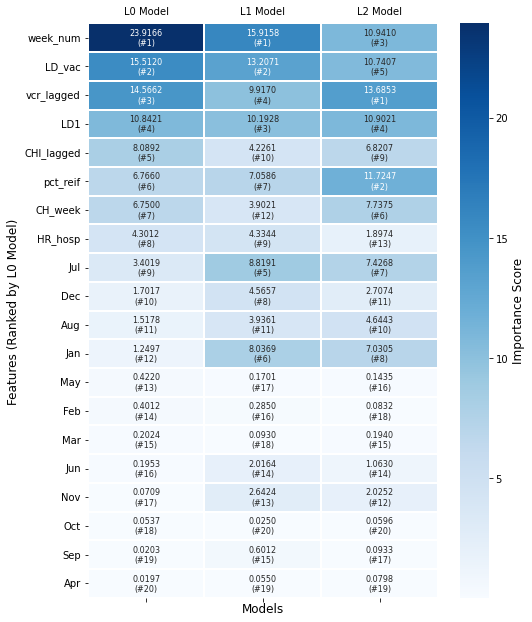

In [43]:
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Assume importance_df is already defined
rank_df = importance_df.rank(ascending=False, method='min').astype(int)

# 2. Sort BOTH dataframes by L0 Model importance (descending)
importance_df = importance_df.sort_values(by='L0 Model', ascending=False)
rank_df = rank_df.loc[importance_df.index] # Align ranks to the new sorted order

# 3. Create a custom text array that combines the Score and the Rank
annot_array = np.empty_like(importance_df, dtype=object)
for i in range(importance_df.shape[0]):
    for j in range(importance_df.shape[1]):
        val = importance_df.iloc[i, j]
        rnk = rank_df.iloc[i, j]
        # Format: "0.1234 \n (#1)"
        annot_array[i, j] = f"{val:.4f}\n(#{rnk})"

# 4. Plot the Heatmap
# PLOS max dimensions are 7.5 inches width x 8.75 inches height.
plt.figure(figsize=(7.5, 8.75)) 

sns.heatmap(
    importance_df, 
    annot=annot_array, 
    fmt="", 
    cmap='Blues', 
    linewidths=1, 
    cbar_kws={'label': 'Importance Score'},
    annot_kws={'size': 8}  # Keep annotations at 8pt to fit smaller squares
)

# 5. Formatting
# Note: plt.title() is removed; PLOS requires titles in the manuscript caption, not the figure.
plt.ylabel('Features (Ranked by L0 Model)')
plt.xlabel('Models')

# Move X-axis labels to the top for easier reading
plt.tick_params(axis='x', which='major', labeltop=True, labelbottom=False)

plt.tight_layout()

# 6. Export to PLOS Standards
# PLOS requires TIFF or EPS formats, 300 PPI minimum, with LZW compression
plt.savefig('sensitivity2.tif', format='tiff', dpi=300, bbox_inches='tight', 
            pil_kwargs={"compression": "tiff_lzw"})

plt.show()

Model evaluation

In [44]:
X = DKcom1[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
            'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
           
y = DKcom1 ['log_weekly_hospitalization']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=322)


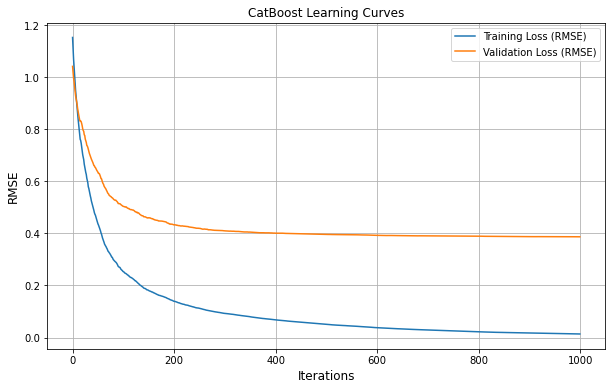

Number of iterations used: 998


In [45]:
# Fit the model and store the evaluation results
eval_results = updated_cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=False, # Important: set this to False for manual plotting
)

# Extract the training and validation loss values
train_loss = eval_results.get_evals_result()['learn']['RMSE']
validation_loss = eval_results.get_evals_result()['validation']['RMSE']

# Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss (RMSE)')
plt.plot(validation_loss, label='Validation Loss (RMSE)')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('CatBoost Learning Curves')
plt.legend()
plt.grid(True)
plt.savefig('learningcurve.png')
plt.show()

#To get the number of iterations Catboost used with early stopping:
print(f"Number of iterations used: {updated_cat_model.get_best_iteration()}")

/tmp/ipykernel_2766618/3597279266.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DKcom1['cb_prediction'] = y_pred
/tmp/ipykernel_2766618/3597279266.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DKcom1['cb_prediction_n'] = np.exp(DKcom1['cb_prediction'])


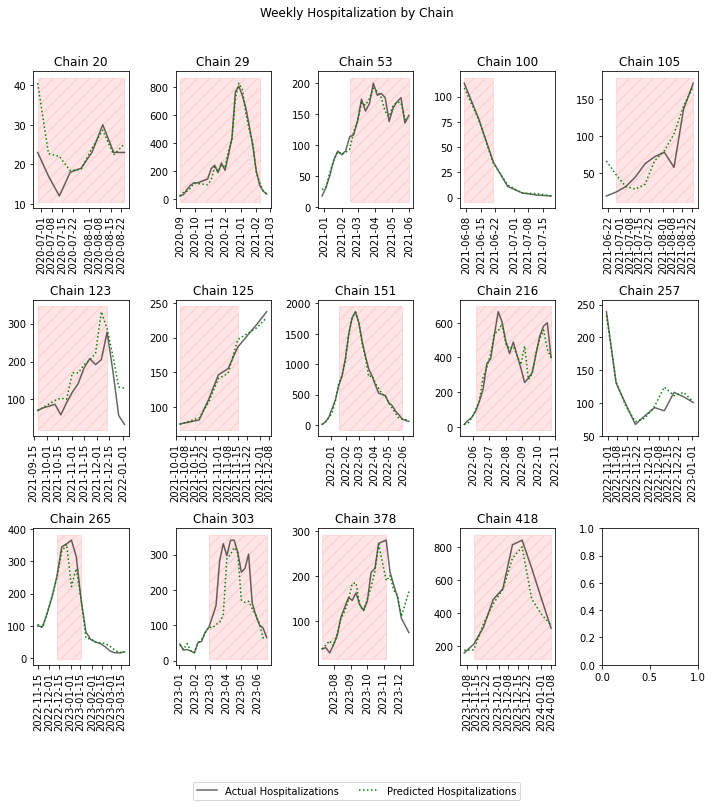

In [19]:
# Make predictions using the testing set
y_pred = updated_cat_model.predict(X)

# add to dataset
DKcom1['cb_prediction'] = y_pred

chains = DKcom1['chain'].unique()
DKcom1['cb_prediction_n'] = np.exp(DKcom1['cb_prediction'])
# Create a figure and axes 
fig, axs = plt.subplots(3,5, figsize=(10, 10), dpi=72)

# Flatten the axes array
axs = axs.flatten()

# Loop over each unique chain
for i, chain in enumerate(chains):
    # Filter the data for the current chain
    chain_df = DKcom1[DKcom1['chain'] == chain]
    
    # Create an area plot on the current axes
    axs[i].plot(chain_df['Date'], chain_df['weekly_hospitalization'], color="Black", alpha=0.6, label='Actual Hospitalizations')
    axs[i].plot(chain_df['Date'], chain_df['cb_prediction_n'], color="green", linestyle=':', label='Predicted Hospitalizations')
    
    # Highlight the area where 'pct' is 0.5 or higher
    high_pct = chain_df['pct'] >= 0.5
    axs[i].fill_between(chain_df['Date'][high_pct], axs[i].get_ylim()[0], 
                        axs[i].get_ylim()[1], color="red", alpha=0.1, hatch = '//')
    
    
    # Set the title for the current axes
    axs[i].set_title(f'Chain {chain}')
    
    # Rotate x-axis labels
    for label in axs[i].get_xticklabels():
        label.set_rotation(90)

# Add a title to the figure
fig.suptitle('Weekly Hospitalization by Chain', y=1.02)

# Adjust the layout
plt.tight_layout()
# Add a single legend outside the subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05),ncol=4)

#plt.savefig("simulated1.png", bbox_inches='tight')
plt.show()

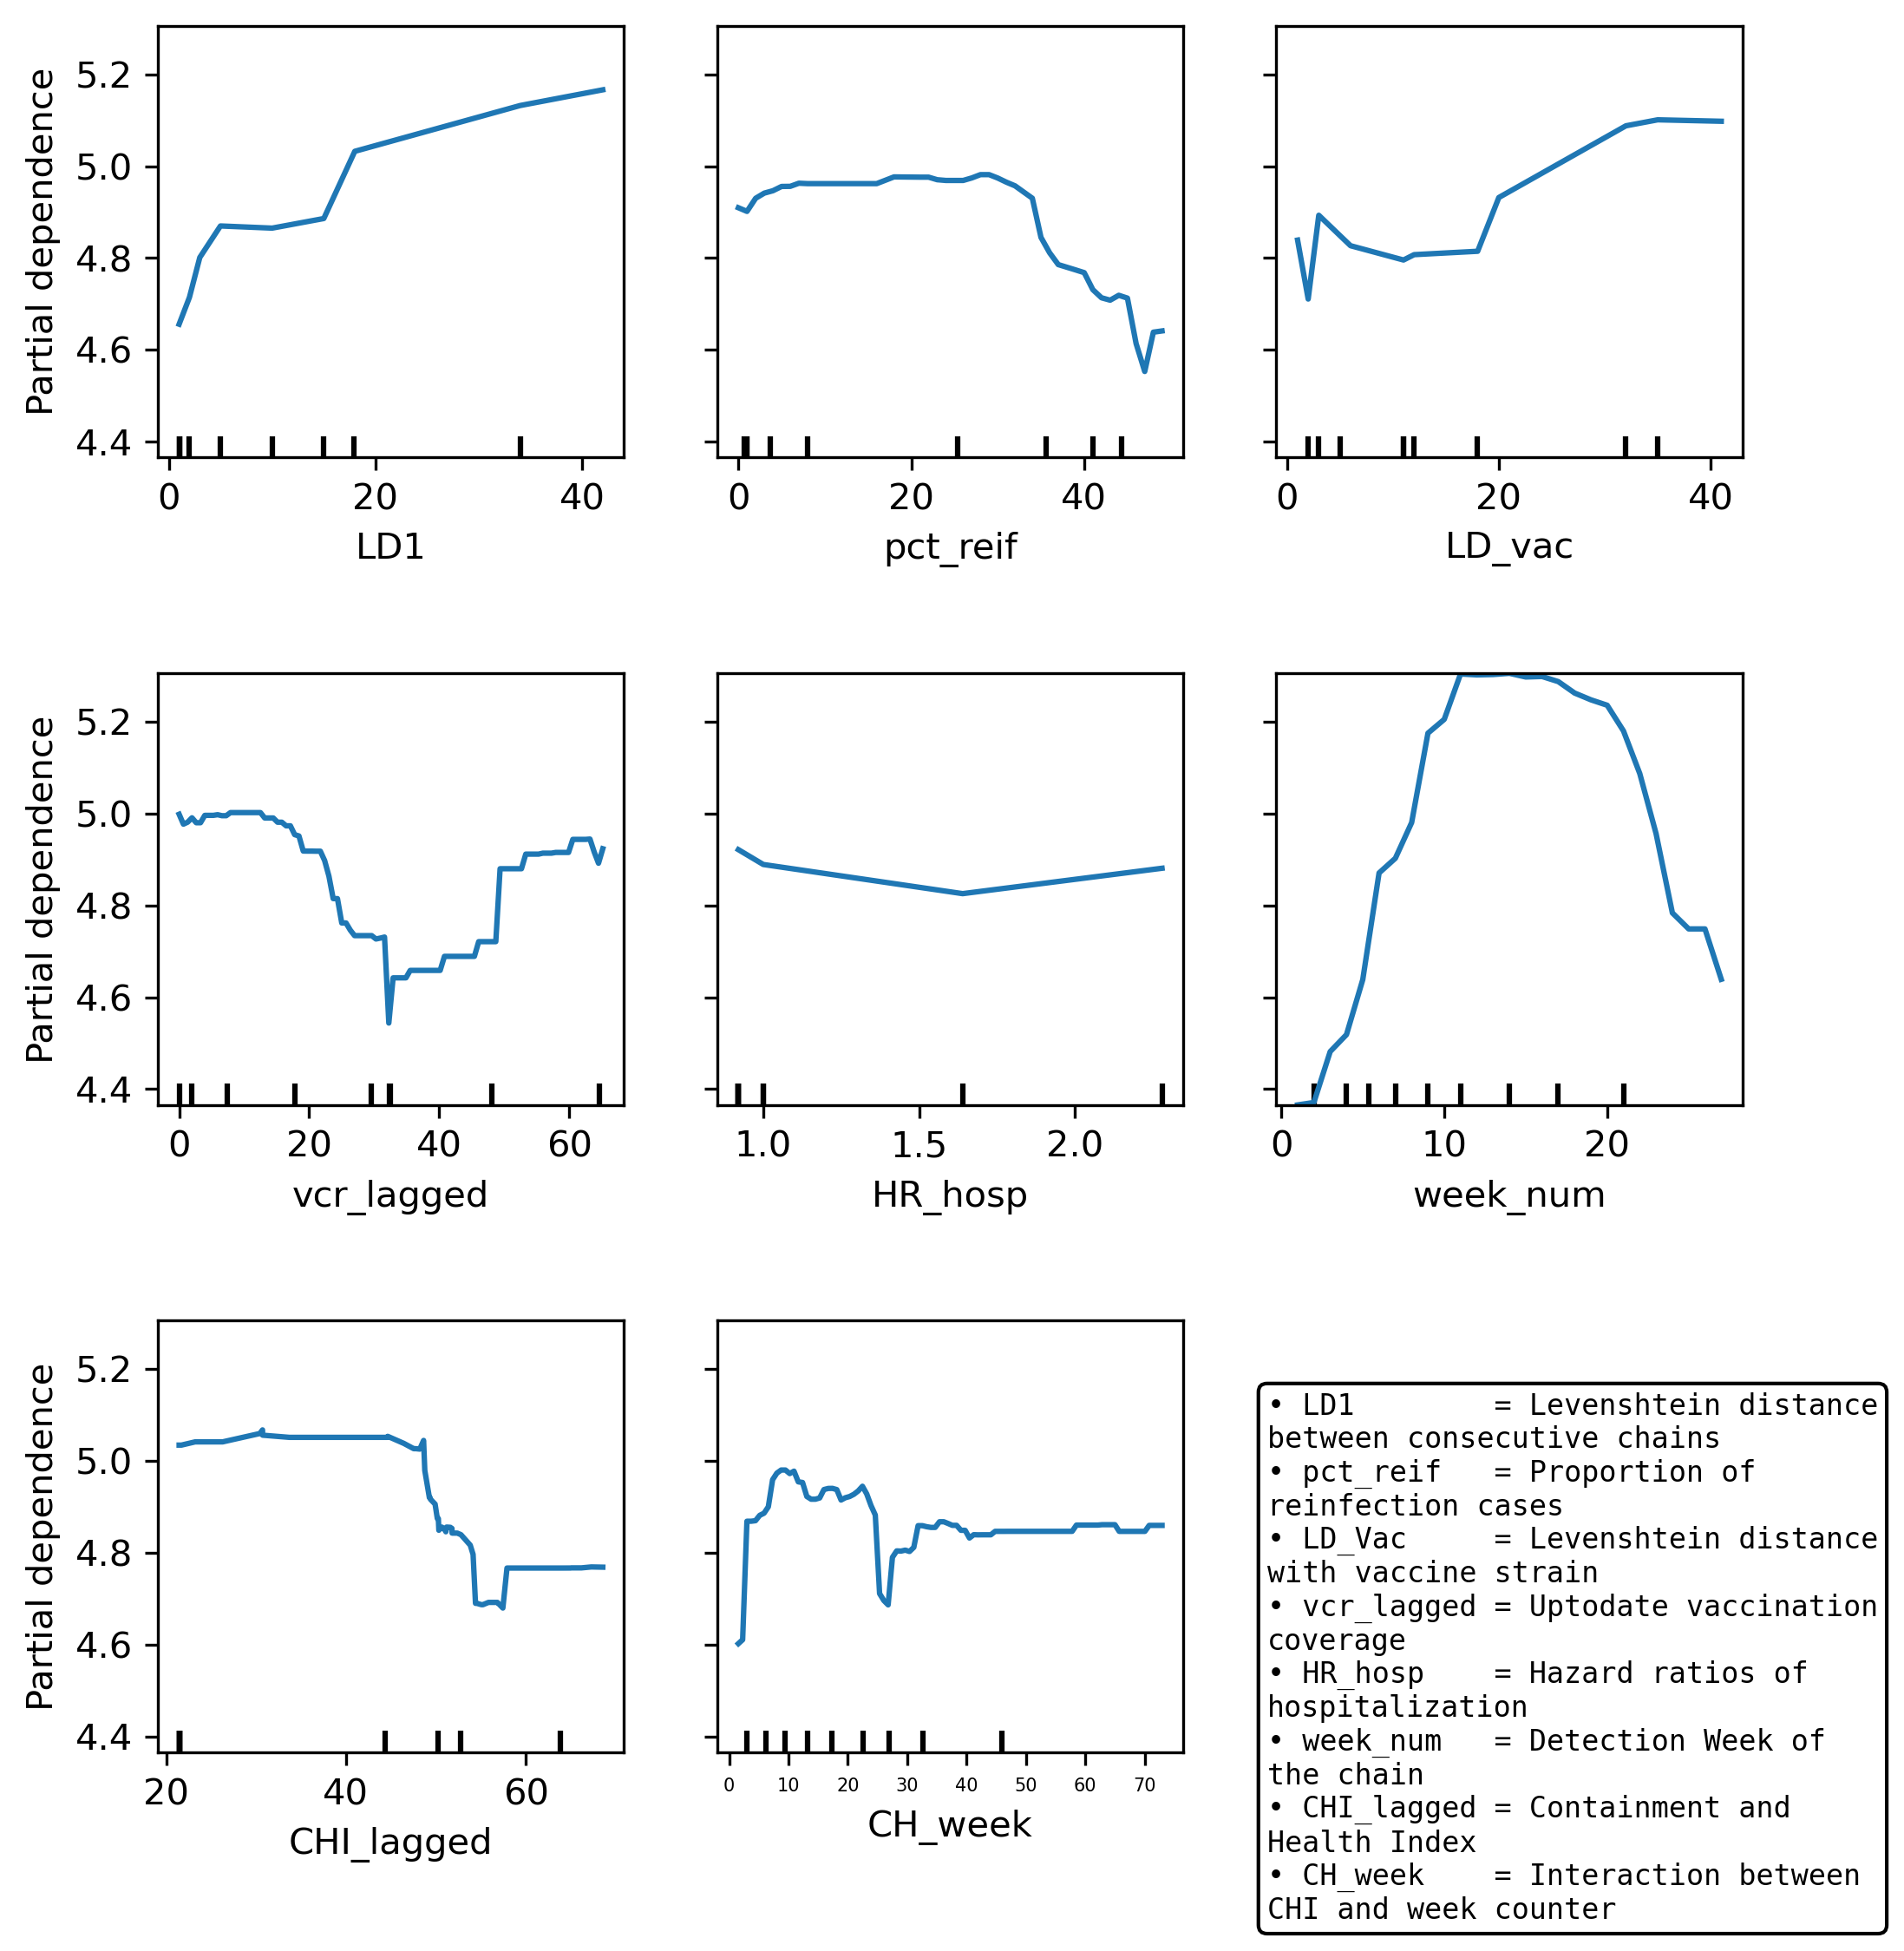

In [21]:

from matplotlib.offsetbox import AnchoredText
import textwrap
# Define the variables
first_7_variables = list(range(8))

fig, ax = plt.subplots(figsize=(7.5, 7.5), dpi=300)
PartialDependenceDisplay.from_estimator(updated_cat_model, X, first_7_variables, ax=ax)
plt.subplots_adjust(hspace=0.5)

lines = [
    "• LD1        = Levenshtein distance between consecutive chains",
    "• pct_reif   = Proportion of reinfection cases",
    "• LD_Vac     = Levenshtein distance with vaccine strain",
    "• vcr_lagged = Uptodate vaccination coverage",
    "• HR_hosp    = Hazard ratios of hospitalization",
    "• week_num   = Detection Week of the chain",
    "• CHI_lagged = Containment and Health Index",
    "• CH_week    = Interaction between CHI and week counter"
    ]

# Optional: wrap long lines for narrower shape
wrapped_lines = [textwrap.fill(line, width=35) for line in lines]

# Join wrapped lines into full textbox content
textbox = "\n".join(wrapped_lines)


# Add text box to upper right corner
anchored_text = AnchoredText(textbox, loc='lower right', prop={'fontsize': 6, 'family': 'monospace'}, frameon=True)
#ax.add_artist(anchored_text)
ax.text(0.7, -0.1, textbox,
        transform=ax.transAxes,
        fontsize=8,
        family='monospace',
        ha='left',
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'))
plt.tick_params(labelsize=5)
#plt.suptitle('Partial Dependence Plots for CatBoost Model')
#fig.text(0.5, -0.05, "Supplementary Figure S12a. Partial dependence plots of selected variables showing the impact of each variable" \
#"\non CatBoost model predictions for weekly hospitalizations in Denmark,\n" \
#"while holding all other variables constant.",
#         ha='center', va='bottom', fontsize=7)
#plt.savefig('Supplementary Figure S12a.pdf', format='pdf', bbox_inches='tight')
plt.tight_layout()
plt.savefig('Supplementary Figure S12a.png', bbox_inches='tight')
plt.show()





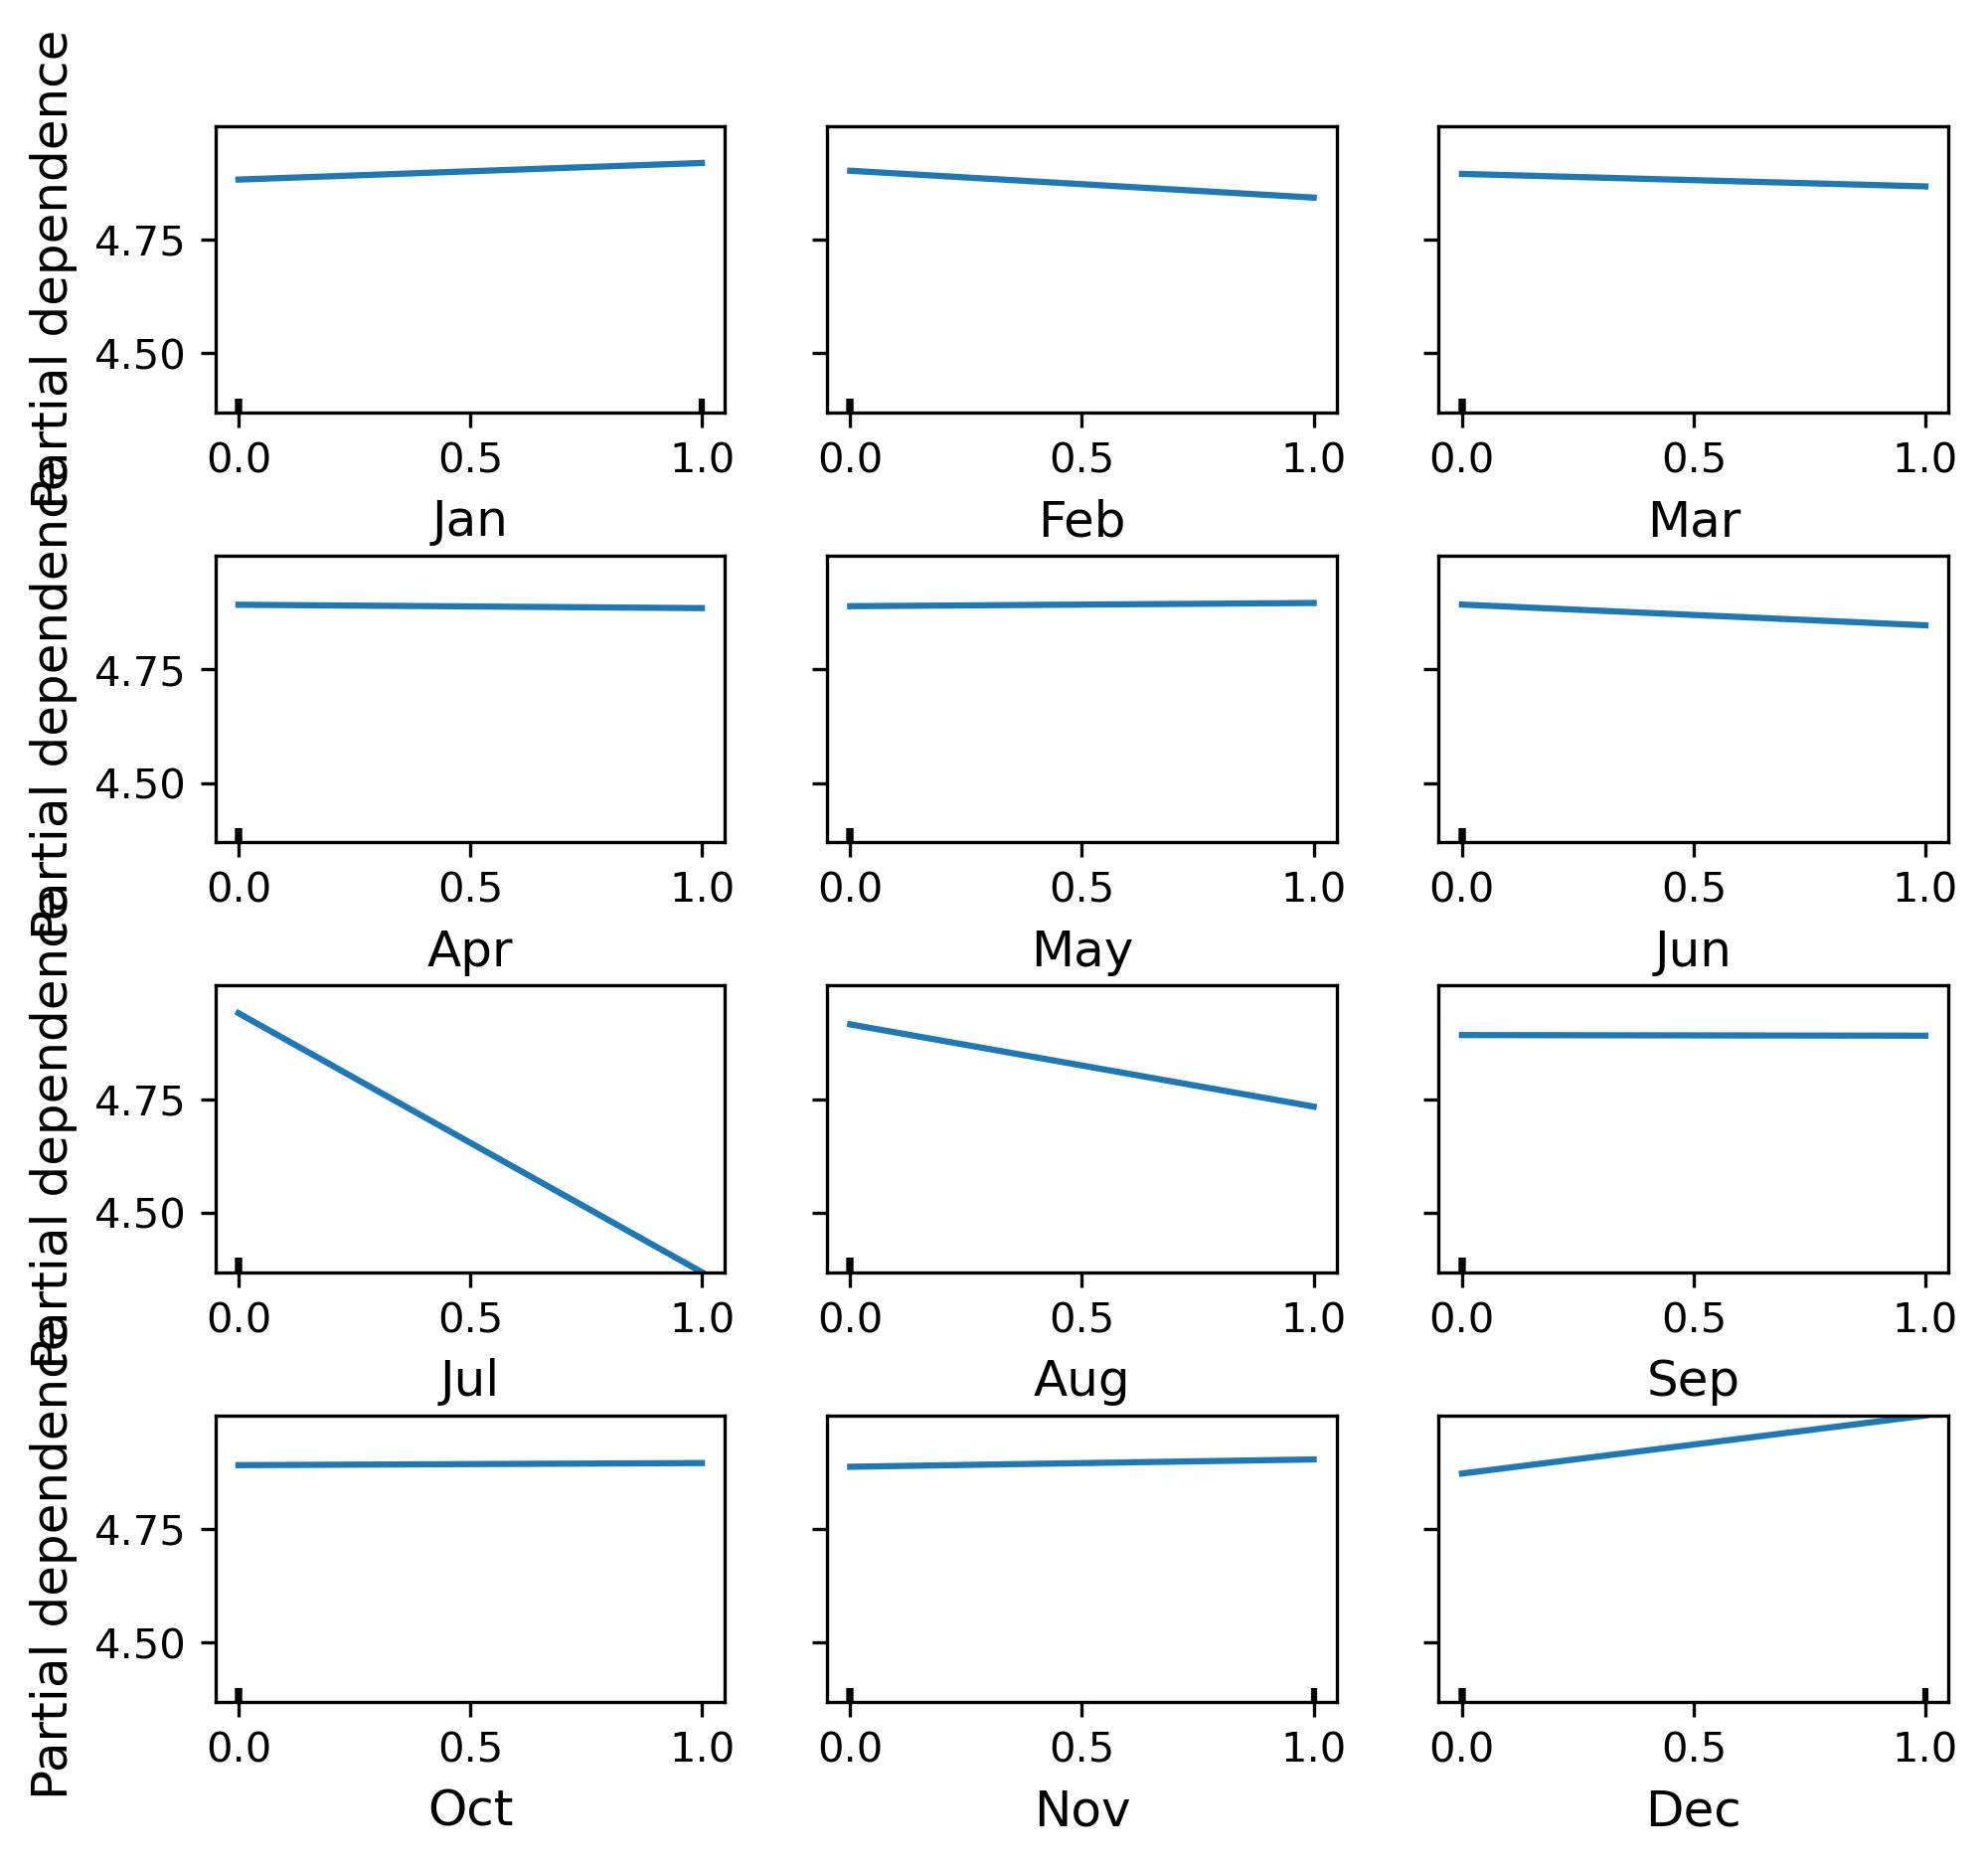

In [49]:
last_12_variables = list(range(8, 20))
#last_2 = list(range(19,21))

# Plot PDP for the last 12 variables
fig, ax = plt.subplots(figsize=(7.5, 7), dpi=300)
PartialDependenceDisplay.from_estimator(updated_cat_model, X, last_12_variables, ax=ax)
plt.subplots_adjust(hspace=0.5)
#plt.suptitle('Partial Dependence Plots for Last 12 Variables')

#plt.savefig('Supplementary Figure S13.pdf', format='pdf', bbox_inches='tight')
#plt.tick_params(labelsize=5)
plt.savefig('Supplementary Figure S12b.png', bbox_inches='tight')
plt.show()

In [22]:
print(feature_importance_df)

       Feature  Importance
5     week_num   23.916584
2       LD_vac   15.511974
3   vcr_lagged   14.566173
0          LD1   10.842129
6   CHI_lagged    8.089157
1     pct_reif    6.766048
7      CH_week    6.749998
4      HR_hosp    4.301222
14         Jul    3.401900
19         Dec    1.701725
15         Aug    1.517838
8          Jan    1.249688
12         May    0.421978
9          Feb    0.401170
10         Mar    0.202440
13         Jun    0.195284
18         Nov    0.070902
17         Oct    0.053727
16         Sep    0.020312
11         Apr    0.019750


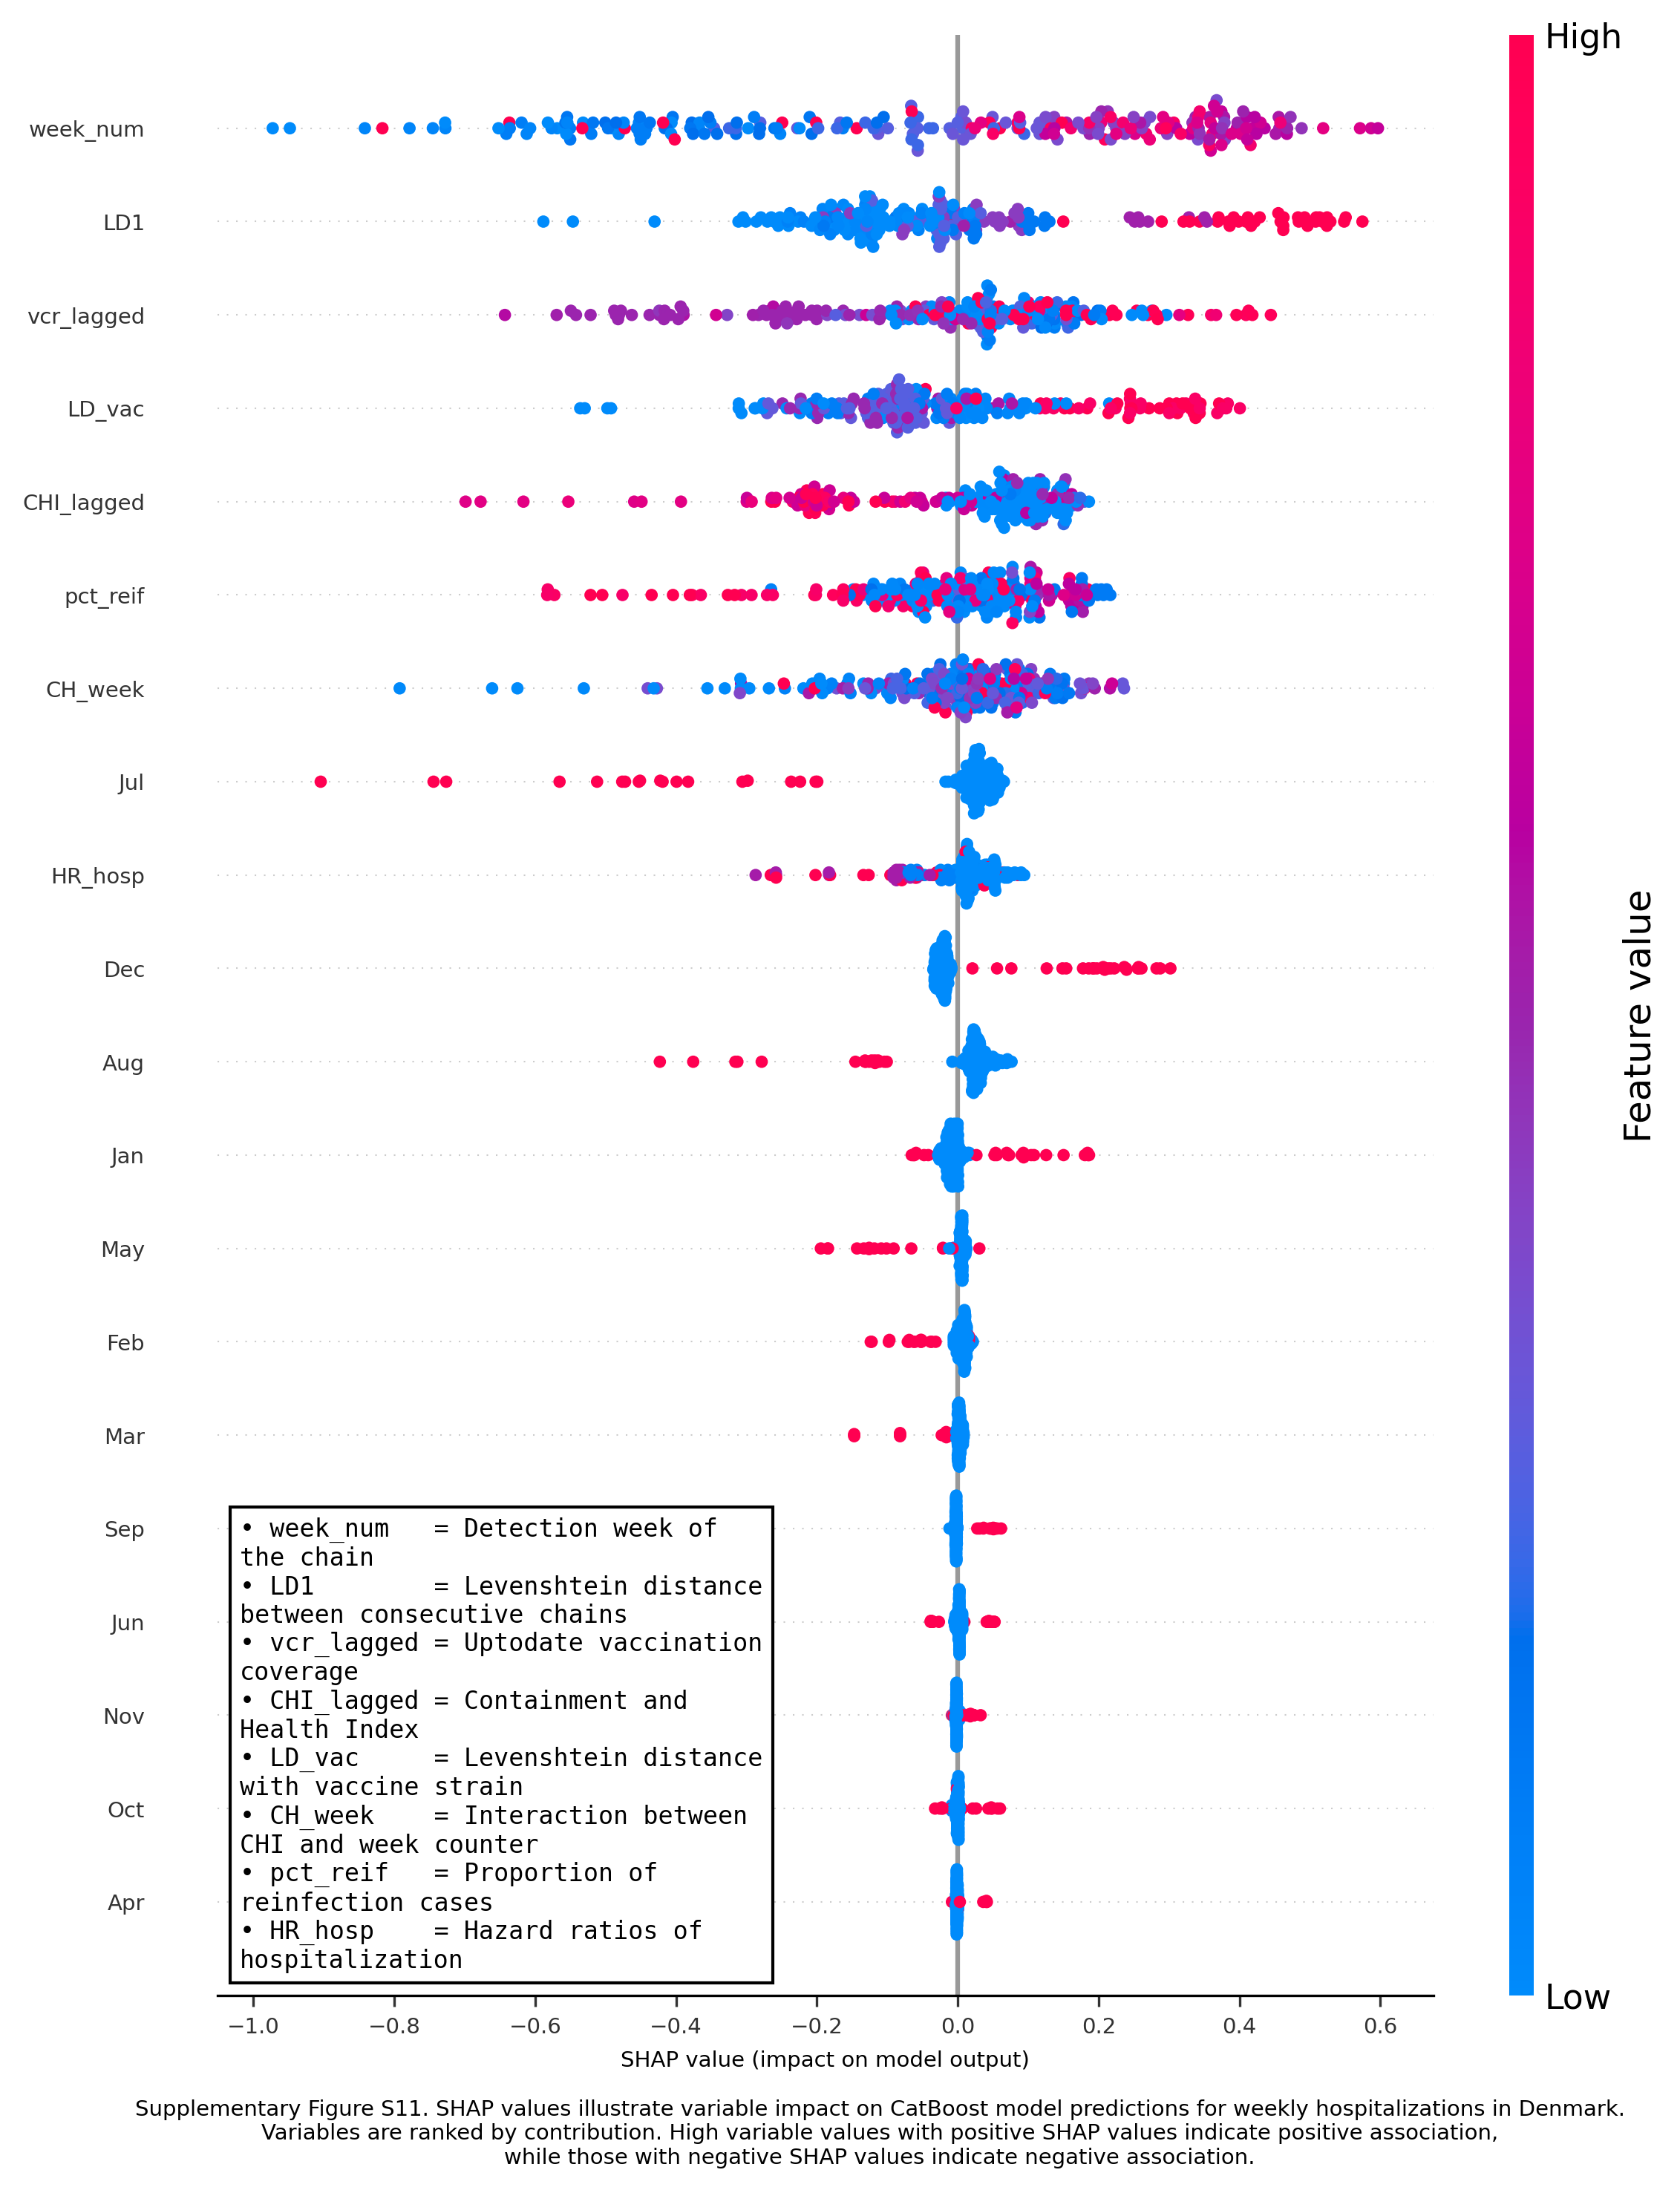

In [23]:
import shap
import textwrap
from matplotlib.offsetbox import AnchoredText

explainer = shap.TreeExplainer(updated_cat_model)
shap_values = explainer.shap_values(X)
fig = plt.figure(figsize=(7.5, 5), dpi=300)
shap.summary_plot(shap_values, X, show=False)
ax = plt.gca()


# Descriptive content
# Bullet-point lines stored individually
lines = [
    "• week_num   = Detection week of the chain",
    "• LD1        = Levenshtein distance between consecutive chains",
    "• vcr_lagged = Uptodate vaccination coverage",
    "• CHI_lagged = Containment and Health Index",
    "• LD_vac     = Levenshtein distance with vaccine strain",
    "• CH_week    = Interaction between CHI and week counter",
    "• pct_reif   = Proportion of reinfection cases",
    "• HR_hosp    = Hazard ratios of hospitalization"
]

# Optional: wrap long lines for narrower shape
wrapped_lines = [textwrap.fill(line, width=35) for line in lines]

# Join wrapped lines into full textbox content
textbox = "\n".join(wrapped_lines)
# Create and position the textbox in lower-left corner
anchored_text = AnchoredText(textbox, loc='lower left',
                             prop={'fontsize': 8, 'family': 'monospace'},
                             frameon=True, pad=0.4)

ax.add_artist(anchored_text)

plt.tick_params(labelsize=7)
#plt.ylabel("Feature", fontsize=7)
plt.xlabel("SHAP value (impact on model output)", fontsize=7)
#plt.suptitle('Partial Dependence Plots for CatBoost Model')
fig.text(0.5, -0.03, "Supplementary Figure S11. SHAP values illustrate variable impact on CatBoost model predictions for weekly hospitalizations in Denmark." \
"\nVariables are ranked by contribution. High variable values with positive SHAP values indicate positive association," \
"\nwhile those with negative SHAP values indicate negative association.",
         ha='center', va='bottom', fontsize=7)
plt.savefig('Supplementary Figure S11.pdf', format='pdf', bbox_inches='tight')
plt.savefig('Supplementary Figure S11.png', bbox_inches='tight')

# Finalize layout and show
plt.tight_layout()
plt.show()

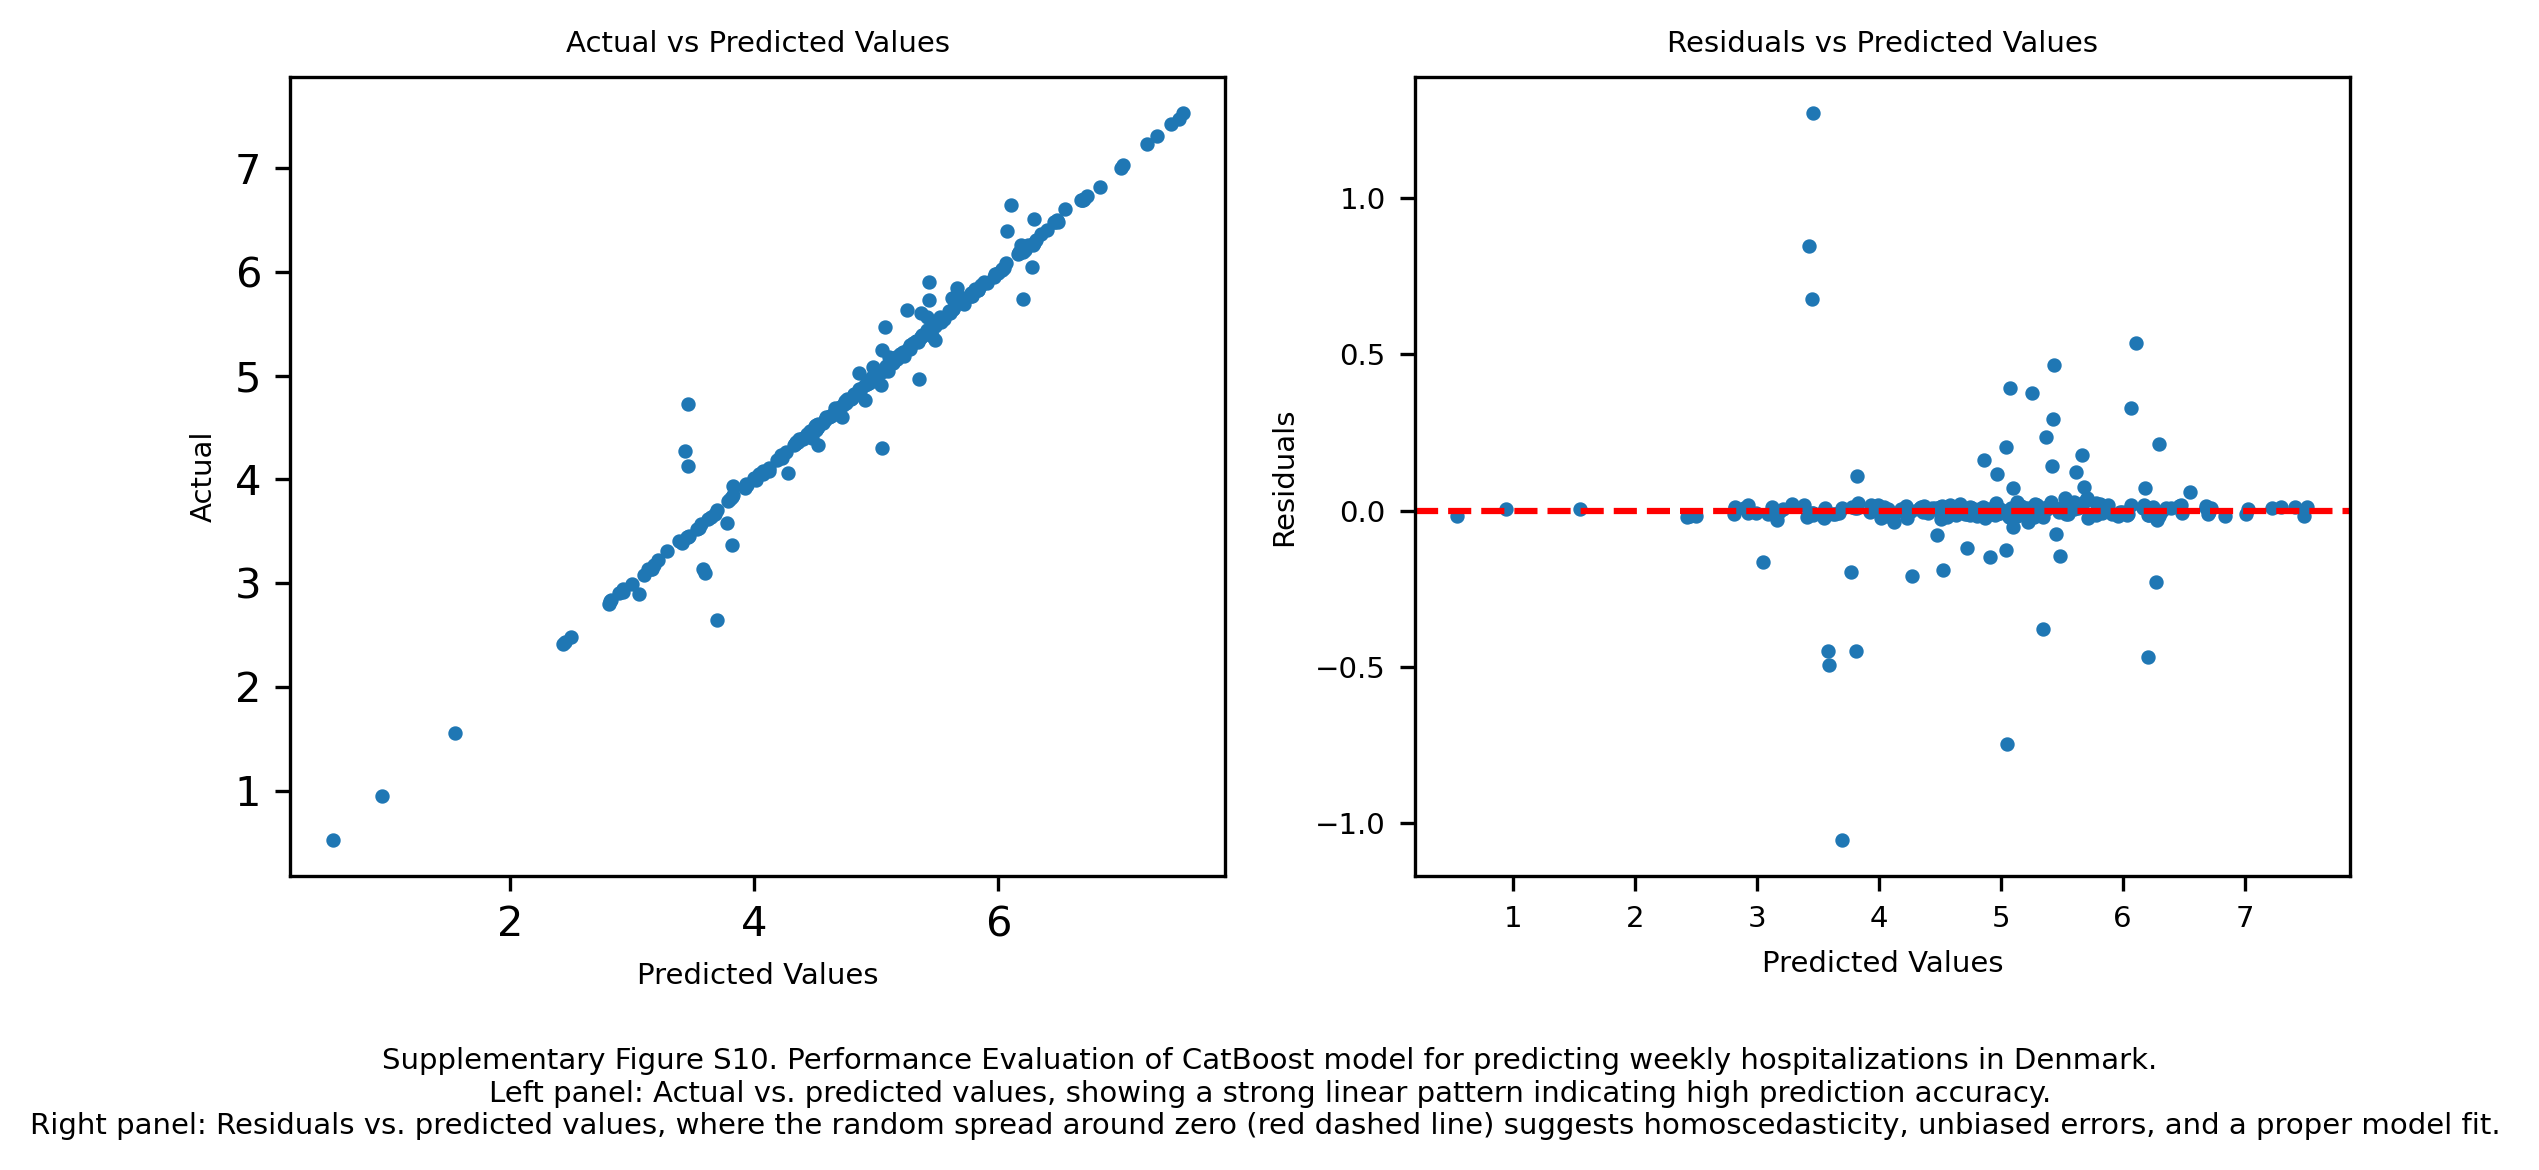

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5), dpi=300)

# Plot the prediction
ax1.scatter(y_pred, y, s=6)
ax1.set_xlabel('Predicted Values', fontsize=7)
ax1.set_ylabel('Actual', fontsize=7)
ax1.set_title('Actual vs Predicted Values', fontsize=7)

# Calculate residuals
residuals = y - y_pred 

# Plot the residuals
ax2.scatter(y_pred, residuals, s=6)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values', fontsize=7)
ax2.set_ylabel('Residuals', fontsize=7)
ax2.set_title('Residuals vs Predicted Values', fontsize=7)

plt.tick_params(labelsize=7)
fig.text(0.5, -0.1, "Supplementary Figure S10. Performance Evaluation of CatBoost model for predicting weekly hospitalizations in Denmark." \
"\nLeft panel: Actual vs. predicted values, showing a strong linear pattern indicating high prediction accuracy." \
"\nRight panel: Residuals vs. predicted values, where the random spread around zero (red dashed line) suggests homoscedasticity, unbiased errors, and a proper model fit. ",
         ha='center', va='bottom', fontsize=7)
plt.savefig('Supplementary Figure S10.pdf', format='pdf', bbox_inches='tight')

plt.tight_layout()
plt.savefig("Model performance.png", bbox_inches='tight')
plt.show()

In [24]:
modified_data = DKcom1.copy(deep=True)
modified_data['Cumu_Hospitalization'] = modified_data.groupby('chain')['weekly_hospitalization'].cumsum()


In [25]:
# Convert the 'Date' column to datetime
#modified_data[['CH_week']] = scaler.fit_transform(modified_data[['CH_week']])


X_modified = modified_data[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
           'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]

    
log_predictions = updated_cat_model.predict(X_modified)
    
# Transform predictions back to the original scale
predictions = np.exp(log_predictions)
    
# Add predictions to the modified data
modified_data['simulation_2024'] = predictions
modified_data['simulation_2024_log'] = log_predictions

# Print the modified data with new columns
print(modified_data.head())

   LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3    1       2.0       2         0.0      1.0         1   52.380000   
4    1       6.0       2         0.0      1.0         2   52.380000   
5    1       2.0       2         0.0      1.0         3   50.680000   
6    1       2.0       2         0.0      1.0         4   51.022857   
7    1       2.0       2         0.0      1.0         5   51.790000   

   LD_interaction  pct  Hospitalization  ...  CHI_lagged2  vcr_lagged2  \
3               2  1.0             23.0  ...    52.380000          0.0   
4               2  1.0             17.0  ...    52.380000          0.0   
5               2  1.0             12.0  ...    50.680000          0.0   
6               2  1.0             18.0  ...    51.022857          0.0   
7               2  1.0             19.0  ...    51.790000          0.0   

  sq_weekly_hospitalization chain2    CH_week2  cb_prediction  \
3                  4.795832     20   52.380000       3.700956  

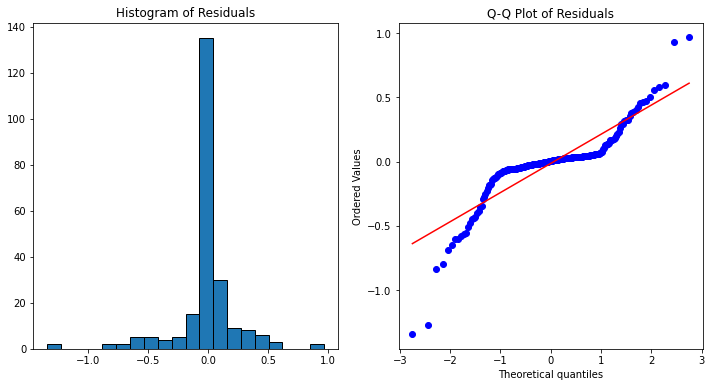

Mean of Residuals: -0.014635024273605874
Standard Deviation of Residuals: 0.2546567791166199
Residuals Range: -1.3425987496136802 to 0.965867247554713


In [26]:
residuals = modified_data["log_weekly_hospitalization"] - modified_data["simulation_2024_log"]

# Visualizations
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title("Histogram of Residuals")

plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.show()

# Descriptive Statistics
print(f"Mean of Residuals: {np.mean(residuals)}")
print(f"Standard Deviation of Residuals: {np.std(residuals)}")
print(f"Residuals Range: {np.min(residuals)} to {np.max(residuals)}")

In [27]:
from scipy.stats import shapiro

print(np.isnan(residuals).any())  # Check for NaNs
print(np.isinf(residuals).any())  # Check for infinities

# Example: residuals
stat, p_value = shapiro(residuals)

print(f"Test Statistic: {stat}")
print(f"P-value: {p_value}")

if p_value > 0.05:
    print("Residuals appear to be normally distributed (fail to reject null hypothesis).")
else:
    print("Residuals do not appear to be normally distributed (reject null hypothesis).")


False
False
Test Statistic: 0.7883325815200806
P-value: 4.6261177561603993e-17
Residuals do not appear to be normally distributed (reject null hypothesis).


In [28]:
n_bootstraps = 1000  # Or more for more stable CIs

model_params = updated_cat_model.get_params()

# 2. Parallelized Bootstrapping:
def bootstrap_iteration(i, X_train, y_train, X_modified, model_params):
    X_resampled, y_resampled = resample(X_train, y_train, replace=True, random_state=i)
    bootstrap_model = CatBoostRegressor(**model_params) # Use model_params
    bootstrap_model.fit(X_resampled, y_resampled)
    return bootstrap_model.predict(X_modified)

def get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params):
    pool = multiprocessing.Pool(processes=multiprocessing.cpu_count()) #Use all cores
    results = [pool.apply_async(bootstrap_iteration, (i, X_train, y_train, X_modified, model_params)) for i in range(n_bootstraps)]
    predictions = [result.get() for result in results]
    pool.close()
    pool.join()
    return np.array(predictions)

predictions = get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params)


# 3. Calculate Confidence Intervals (Vectorized):
alpha = 0.05  # For 95% CI
lower_bound = np.quantile(predictions, alpha / 2, axis=0)
upper_bound = np.quantile(predictions, 1 - alpha / 2, axis=0)

# Calculate confidence intervals
modified_data['lower_2024_log'] = lower_bound
modified_data['upper_2024_log'] = upper_bound

modified_data['lower_2024'] = np.exp(modified_data['lower_2024_log'])
modified_data['upper_2024'] = np.exp(modified_data['upper_2024_log'])

modified_data['Cumu_lower_2024'] = modified_data.groupby('chain')['lower_2024'].cumsum()
modified_data['Cumu_upper_2024'] = modified_data.groupby('chain')['upper_2024'].cumsum()

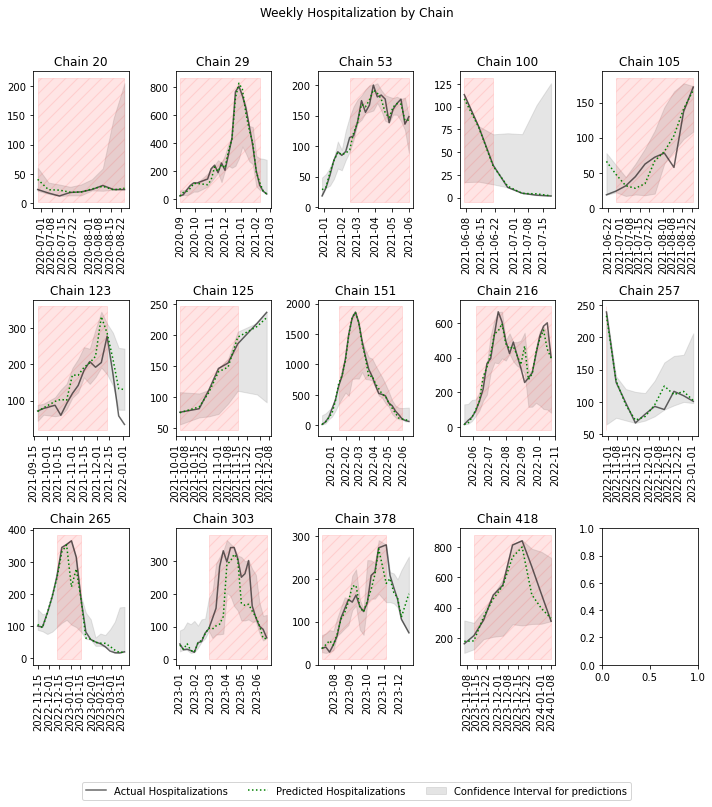

In [29]:
# Create a figure and axes 
fig, axs = plt.subplots(3,5, figsize=(10, 10), dpi=72)

# Flatten the axes array
axs = axs.flatten()

# Loop over each unique chain
for i, chain in enumerate(chains):
    # Filter the data for the current chain
    chain_df = modified_data[modified_data['chain'] == chain]
    
    # Create an area plot on the current axes
    axs[i].plot(chain_df['Date'], chain_df['weekly_hospitalization'], color="Black", alpha=0.6, label='Actual Hospitalizations')
    axs[i].plot(chain_df['Date'], chain_df['simulation_2024'], color="green", linestyle=':', label='Predicted Hospitalizations')
    axs[i].fill_between(chain_df['Date'], chain_df['lower_2024'], chain_df['upper_2024'], alpha=0.2, color='gray', 
                        label='Confidence Interval for predictions')
    # Highlight the area where 'pct' is 0.5 or higher
    high_pct = chain_df['pct'] >= 0.5
    axs[i].fill_between(chain_df['Date'][high_pct], axs[i].get_ylim()[0], 
                        axs[i].get_ylim()[1], color="red", alpha=0.1, hatch = '//')
    
    
    # Set the title for the current axes
    axs[i].set_title(f'Chain {chain}')
    
    # Rotate x-axis labels
    for label in axs[i].get_xticklabels():
        label.set_rotation(90)

# Add a title to the figure
fig.suptitle('Weekly Hospitalization by Chain', y=1.02)

# Adjust the layout
plt.tight_layout()
# Add a single legend outside the subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05),ncol=4)

plt.savefig("CB_simulated2.png", bbox_inches='tight')
plt.show()

In [30]:
modified_data['LD_vac'] = np.where(modified_data['LD_vac'] >=15, 5, modified_data['LD_vac'])


X_modified = modified_data[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
           'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]

log_predictions = updated_cat_model.predict(X_modified)

# Transform predictions back to the original scale
predictions = np.exp(log_predictions)

# Add predictions to the modified data
modified_data['simulation_LDvac'] = predictions
modified_data['simulation_LDvac_log'] = log_predictions

modified_data['LD_vac'] = modified_data['LD_vac2']



In [31]:
model_params = updated_cat_model.get_params()
n_bootstraps = 1000  # Or more for more stable CIs

# 2. Parallelized Bootstrapping:
def bootstrap_iteration(i, X_train, y_train, X_modified, model_params):
    X_resampled, y_resampled = resample(X_train, y_train, replace=True, random_state=i)
    bootstrap_model = CatBoostRegressor(**model_params) # Use model_params
    bootstrap_model.fit(X_resampled, y_resampled)
    return bootstrap_model.predict(X_modified)

def get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params):
    pool = multiprocessing.Pool(processes=multiprocessing.cpu_count()) #Use all cores
    results = [pool.apply_async(bootstrap_iteration, (i, X_train, y_train, X_modified, model_params)) for i in range(n_bootstraps)]
    predictions = [result.get() for result in results]
    pool.close()
    pool.join()
    return np.array(predictions)


predictions = get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params)


# 3. Calculate Confidence Intervals (Vectorized):
alpha = 0.05  # For 95% CI
lower_bound = np.quantile(predictions, alpha / 2, axis=0)
upper_bound = np.quantile(predictions, 1 - alpha / 2, axis=0)

In [32]:

# Calculate confidence intervals
modified_data['lower_LDvac_log'] = lower_bound
modified_data['upper_LDvac_log'] = upper_bound

modified_data['lower_LDvac'] = np.exp(modified_data['lower_LDvac_log'])
modified_data['upper_LDvac'] = np.exp(modified_data['upper_LDvac_log'])

modified_data['Cumu_lower_LDvac'] = modified_data.groupby('chain')['lower_LDvac'].cumsum()
modified_data['Cumu_upper_LDvac'] = modified_data.groupby('chain')['upper_LDvac'].cumsum()


# Print the modified data with new columns
print(modified_data.head())

   LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3    1       2.0       2         0.0      1.0         1   52.380000   
4    1       6.0       2         0.0      1.0         2   52.380000   
5    1       2.0       2         0.0      1.0         3   50.680000   
6    1       2.0       2         0.0      1.0         4   51.022857   
7    1       2.0       2         0.0      1.0         5   51.790000   

   LD_interaction  pct  Hospitalization  ...  Cumu_lower_2024  \
3               2  1.0             23.0  ...        20.813296   
4               2  1.0             17.0  ...        36.358490   
5               2  1.0             12.0  ...        48.351254   
6               2  1.0             18.0  ...        61.392737   
7               2  1.0             19.0  ...        74.465978   

   Cumu_upper_2024 simulation_LDvac simulation_LDvac_log  lower_LDvac_log  \
3        60.409649        40.485986             3.700956         3.035592   
4        95.292913        22

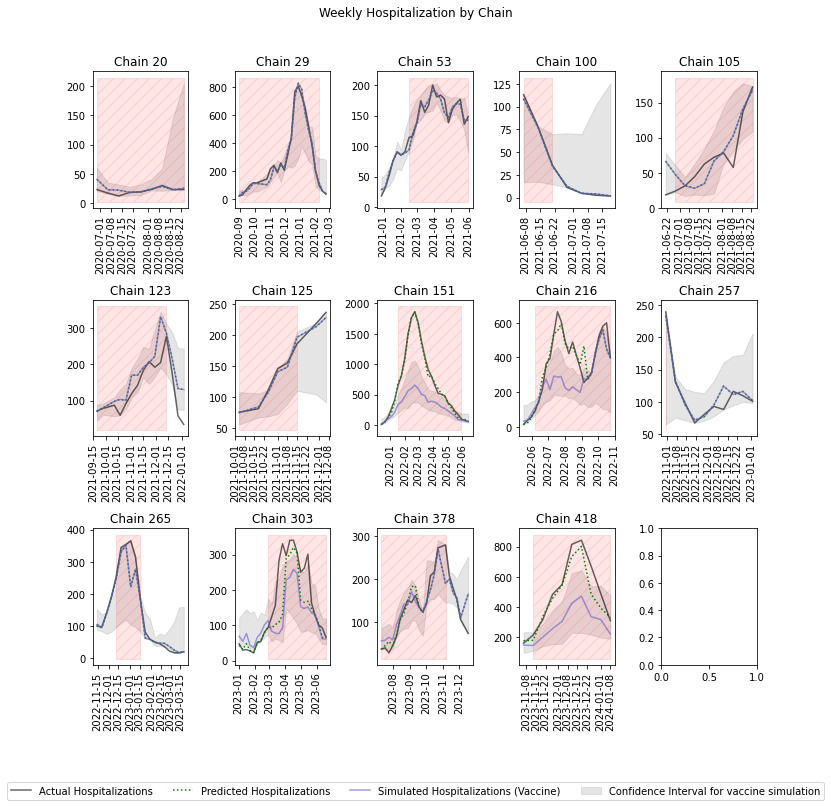

In [33]:
chains = modified_data['chain'].unique()
# Create a figure and axes 
fig, axs = plt.subplots(3,5, figsize=(10, 10), dpi=72)

# Flatten the axes array
axs = axs.flatten()

# Loop over each unique chain
for i, chain in enumerate(chains):
    # Filter the data for the current chain
    chain_df = modified_data[modified_data['chain'] == chain]
    
    # Create an area plot on the current axes
    axs[i].plot(chain_df['Date'], chain_df['weekly_hospitalization'], color="Black", alpha=0.6, label='Actual Hospitalizations')
    axs[i].plot(chain_df['Date'], chain_df['simulation_2024'], color="green", linestyle=':', label='Predicted Hospitalizations')
    axs[i].plot(chain_df['Date'], chain_df['simulation_LDvac'], c="Slateblue",alpha=0.6, label='Simulated Hospitalizations (Vaccine)')
    axs[i].fill_between(chain_df['Date'], chain_df['lower_LDvac'], chain_df['upper_LDvac'], alpha=0.2, color='gray', 
                        label='Confidence Interval for vaccine simulation')
    
    # Highlight the area where 'pct' is 0.5 or higher
    high_pct = chain_df['pct'] >= 0.5
    axs[i].fill_between(chain_df['Date'][high_pct], axs[i].get_ylim()[0], 
                        axs[i].get_ylim()[1], color="red", alpha=0.1, hatch = '//')
    
    
    # Set the title for the current axes
    axs[i].set_title(f'Chain {chain}')
    
    # Rotate x-axis labels
    for label in axs[i].get_xticklabels():
        label.set_rotation(90)

# Add a title to the figure
fig.suptitle('Weekly Hospitalization by Chain', y=1.02)

# Adjust the layout
plt.tight_layout()
# Add a single legend outside the subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05),ncol=4)

plt.savefig("simulatedLDvac.png", bbox_inches='tight')
plt.show()

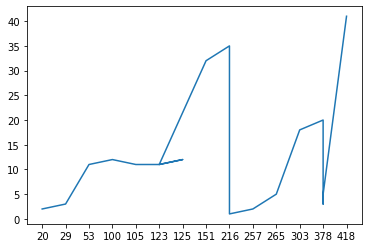

In [34]:
plt.plot(modified_data['chain'], modified_data['LD_vac'])

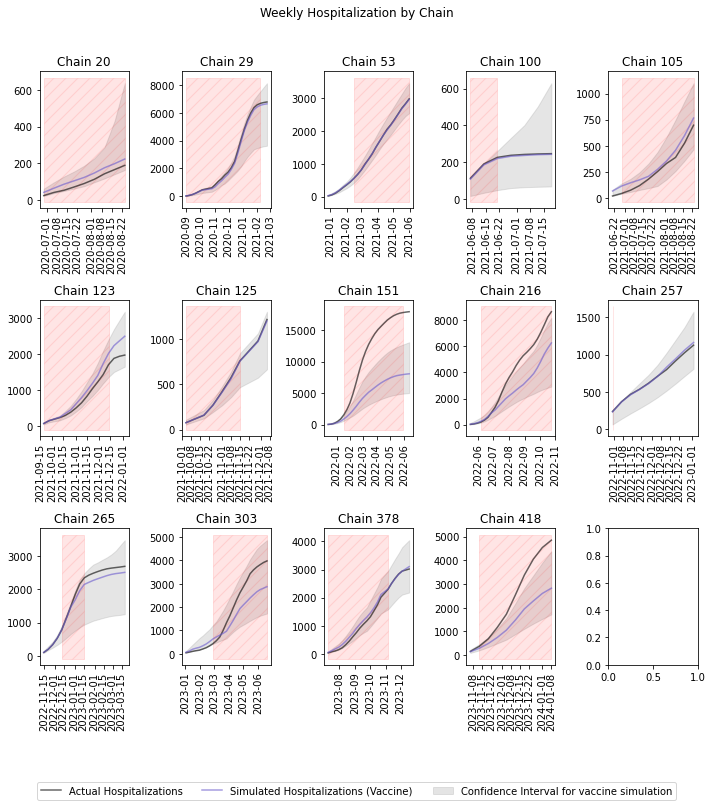

In [35]:
#modified_data.loc[modified_data['chain'] == 'Simulation', 'weekly_hospitalization'] = modified_data['simulation_2024']
modified_data['Cumu_Hospitalization_LD_vac'] = modified_data.groupby('chain')['simulation_LDvac'].cumsum()
modified_data['Cumulative_Hospitalization'] = modified_data.groupby('chain')['weekly_hospitalization'].cumsum()

chains = modified_data['chain'].unique()
# Create a figure and axes 
fig, axs = plt.subplots(3,5, figsize=(10, 10), dpi=72)

# Flatten the axes array
axs = axs.flatten()

# Loop over each unique chain
for i, chain in enumerate(chains):
    # Filter the data for the current chain
    chain_df = modified_data[modified_data['chain'] == chain]
    
    # Create an area plot on the current axes
    axs[i].plot(chain_df['Date'], chain_df['Cumulative_Hospitalization'], color="Black", alpha=0.6, label='Actual Hospitalizations')
    #axs[i].plot(chain_df['Date'], chain_df['simulation_2024'], color="green", linestyle=':', label='Predicted Hospitalizations')
    axs[i].plot(chain_df['Date'], chain_df['Cumu_Hospitalization_LD_vac'], c="Slateblue",alpha=0.6, label='Simulated Hospitalizations (Vaccine)')
    axs[i].fill_between(chain_df['Date'], chain_df['Cumu_lower_LDvac'], chain_df['Cumu_upper_LDvac'], alpha=0.2, color='gray', 
                        label='Confidence Interval for vaccine simulation')
    
    # Highlight the area where 'pct' is 0.5 or higher
    high_pct = chain_df['pct'] >= 0.5
    axs[i].fill_between(chain_df['Date'][high_pct], axs[i].get_ylim()[0], 
                        axs[i].get_ylim()[1], color="red", alpha=0.1, hatch = '//')
    
    
    # Set the title for the current axes
    axs[i].set_title(f'Chain {chain}')
    
    # Rotate x-axis labels
    for label in axs[i].get_xticklabels():
        label.set_rotation(90)

# Add a title to the figure
fig.suptitle('Weekly Hospitalization by Chain', y=1.02)

# Adjust the layout
plt.tight_layout()
# Add a single legend outside the subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05),ncol=4)

#plt.savefig("simulated1.png", bbox_inches='tight')
plt.show()

In [36]:
def update_stringency_index(modified_data):
    # Update the first 2 weeks (assuming each week is 7 days)
    modified_data.loc[(modified_data['week_num'] >= 6) & (modified_data['week_num'] < 15), 'CHI_lagged'] = 68.57
    # Update the next 2 weeks
    modified_data.loc[(modified_data['week_num'] >= 15), 'CHI_lagged'] = 68.57
    return modified_data

modified_data = update_stringency_index(modified_data)
modified_data['CH_week'] = modified_data['CHI_lagged'] * modified_data['week_num']
modified_data['CH_week'] = scaler.fit_transform(modified_data[['CH_week']])
#modified_data[['reinf_LD1', 'vcr_LDvac']] = scaler.fit_transform(modified_data[['reinf_LD1', 'vcr_LDvac']])

X_modified = modified_data[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
           'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
    
    
    
log_predictions = updated_cat_model.predict(X_modified)
    
# Transform predictions back to the original scale
predictions = np.exp(log_predictions)
    
# Add predictions to the modified data
modified_data['predicted_y_SI_newt'] = predictions
modified_data['predicted_y_SI_newt_log'] = log_predictions

modified_data['Cumu_Hospitalization_simulated_2024'] = modified_data.groupby('chain')['simulation_2024'].cumsum()
modified_data['Cumu_Hospitalization_simulated_SI_newt'] = modified_data.groupby('chain')['predicted_y_SI_newt'].cumsum()

modified_data['CHI_lagged'] = modified_data['CHI_lagged2']
modified_data['CH_week'] = modified_data['CHI_lagged'] * modified_data['week_num']

In [37]:

predictions = get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params)


# 3. Calculate Confidence Intervals (Vectorized):
alpha = 0.05  # For 95% CI
lower_bound = np.quantile(predictions, alpha / 2, axis=0)
upper_bound = np.quantile(predictions, 1 - alpha / 2, axis=0)

modified_data['lower_SI_Newt_log'] = lower_bound
modified_data['upper_SI_Newt_log'] = upper_bound

modified_data['lower_SI_Newt'] = np.exp(modified_data['lower_SI_Newt_log'])
modified_data['upper_SI_Newt'] = np.exp(modified_data['upper_SI_Newt_log'])
modified_data['Cumu_lci_SI_newt'] = modified_data.groupby('chain')['lower_SI_Newt'].cumsum()
modified_data['Cumu_uci_SI_newt'] = modified_data.groupby('chain')['upper_SI_Newt'].cumsum()

print(modified_data)

     LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3      1       2.0       2    0.000000     1.00         1   52.380000   
4      1       6.0       2    0.000000     1.00         2   52.380000   
5      1       2.0       2    0.000000     1.00         3   50.680000   
6      1       2.0       2    0.000000     1.00         4   51.022857   
7      1       2.0       2    0.000000     1.00         5   51.790000   
..   ...       ...     ...         ...      ...       ...         ...   
228    2      40.0       5   18.480633     0.92        22   21.430000   
235   42      40.0      41   18.480633     0.92         7   21.430000   
236   42      34.0      41   18.757490     0.92         8   21.430000   
237   42      40.0      41   18.921380     0.92         9   21.430000   
238   42      39.0      41   18.939095     0.92        10   21.430000   

     LD_interaction       pct  Hospitalization  ...  predicted_y_SI_newt  \
3                 2  1.000000             23.0 

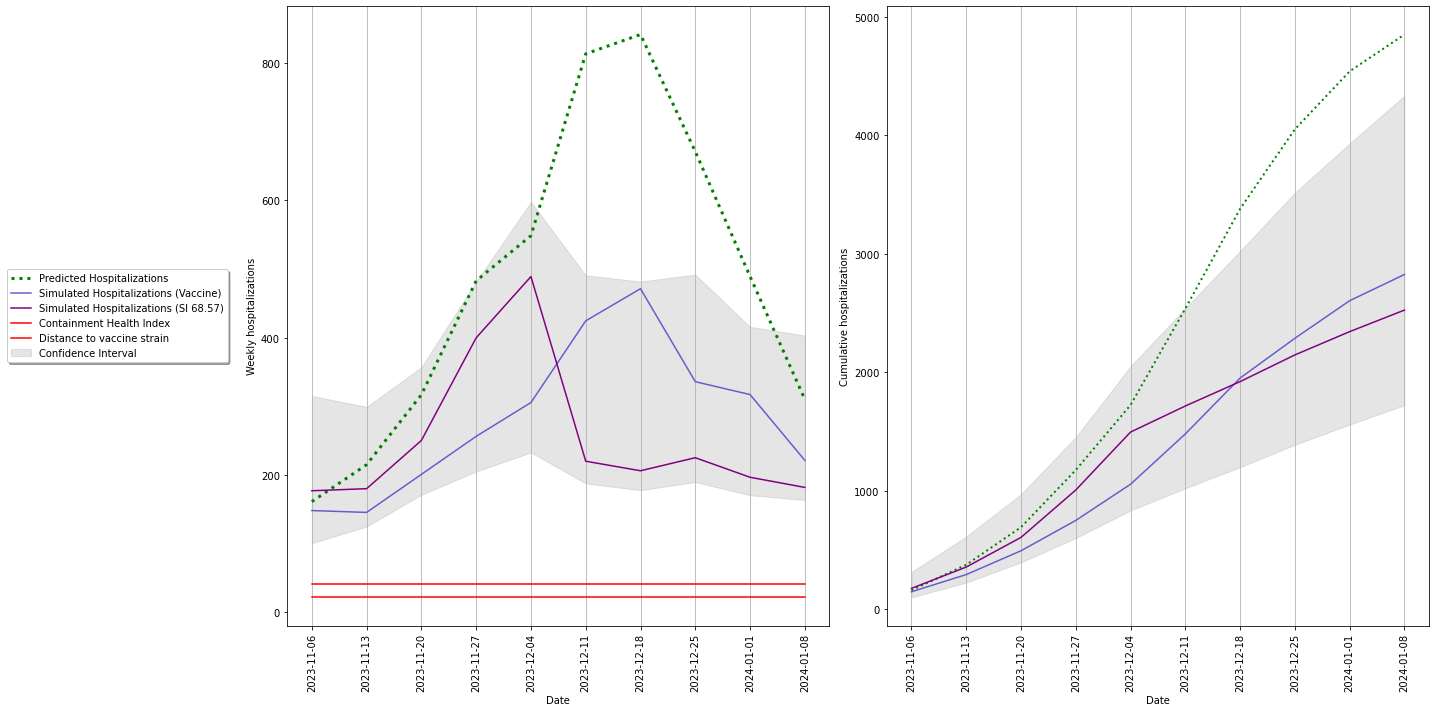

In [38]:

modified_data2 = modified_data[modified_data['chain']== '418']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), dpi=72)
ax1.plot(modified_data2['Date'], modified_data2['weekly_hospitalization'], color="green",linestyle=':', linewidth = 3, label='Predicted Hospitalizations')
ax1.plot(modified_data2['Date'], modified_data2['simulation_LDvac'], c="Slateblue", label='Simulated Hospitalizations (Vaccine)')
ax1.plot(modified_data2['Date'], modified_data2['predicted_y_SI_newt'], c="purple", label='Simulated Hospitalizations (SI 68.57)')
ax1.plot(modified_data2['Date'], modified_data2['CHI_lagged'], c="red", label='Containment Health Index')
ax1.plot(modified_data2['Date'], modified_data2['LD_vac'], c="red", label='Distance to vaccine strain')
ax1.fill_between(modified_data2['Date'], modified_data2['lower_SI_Newt'], modified_data2['upper_SI_Newt'], alpha=0.2, color='gray', 
                        label='Confidence Interval')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax1.legend(loc ='center right', bbox_to_anchor=(-0.1, 0.5), fancybox=True, shadow=True) 
ax1.grid(axis='x') 
ax1.set_xlabel('Date') 
ax1.set_ylabel('Weekly hospitalizations')

ax2.plot(modified_data2['Date'], modified_data2['Cumulative_Hospitalization'],linestyle=':', color="green", linewidth = 2, label='Predicted Hospitalizations')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_LD_vac'], c="Slateblue", label='Simulations (Distance to Vaccine)')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_simulated_SI_newt'], c="purple", label='Simulations (SI 68.57)')
ax2.fill_between(modified_data2['Date'], modified_data2['Cumu_lci_SI_newt'], modified_data2['Cumu_uci_SI_newt'], alpha=0.2, color='gray', 
                        label='Confidence Interval for vaccine simulation')
#ax2.legend(loc ='center left', bbox_to_anchor=(1, 0.5), fancybox=True, shadow=True) 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
# Set major locator to start weeks from Monday 
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax2.grid(axis='x') 
ax2.set_xlabel('Date') 
ax2.set_ylabel('Cumulative hospitalizations')


# Rotate date labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=90)

# Ensure the subplots are the same size
plt.tight_layout()

# Show the plot
plt.show()

In [39]:
modified_data['CHI_lagged'] = modified_data['CHI_lagged2']
def update_stringency_index(modified_data):
    
    modified_data.loc[(modified_data['week_num'] >= 6) & (modified_data['week_num'] < 15), 'CHI_lagged'] = 68.57
    return modified_data

modified_data = update_stringency_index(modified_data)
modified_data['CH_week'] = modified_data['CHI_lagged'] * modified_data['week_num']
modified_data['CH_week'] = scaler.fit_transform(modified_data[['CH_week']])
#modified_data[['reinf_LD1', 'vcr_LDvac']] = scaler.fit_transform(modified_data[['reinf_LD1', 'vcr_LDvac']])

X_modified = modified_data[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
           'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
    

log_predictions = updated_cat_model.predict(X_modified)
    
# Transform predictions back to the original scale
predictions = np.exp(log_predictions)
    
# Add predictions to the modified data
modified_data['predicted_y_SI_new'] = predictions
modified_data['predicted_y_SI_new_log'] = log_predictions

modified_data['Cumu_Hospitalization_simulated_SI_new'] = modified_data.groupby('chain')['predicted_y_SI_new'].cumsum()



In [40]:


predictions = get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params)


# 3. Calculate Confidence Intervals (Vectorized):
alpha = 0.05  # For 95% CI
lower_bound = np.quantile(predictions, alpha / 2, axis=0)
upper_bound = np.quantile(predictions, 1 - alpha / 2, axis=0)

# Calculate confidence intervals
modified_data['lower_SI_New_log'] = lower_bound
modified_data['upper_SI_New_log'] = upper_bound

modified_data['lower_SI_New'] = np.exp(modified_data['lower_SI_New_log'])
modified_data['upper_SI_New'] = np.exp(modified_data['upper_SI_New_log'])

modified_data['Cumu_lci_SI_new'] = modified_data.groupby('chain')['lower_SI_New'].cumsum()
modified_data['Cumu_uci_SI_new'] = modified_data.groupby('chain')['upper_SI_New'].cumsum()

print(modified_data)

     LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3      1       2.0       2    0.000000     1.00         1   52.380000   
4      1       6.0       2    0.000000     1.00         2   52.380000   
5      1       2.0       2    0.000000     1.00         3   50.680000   
6      1       2.0       2    0.000000     1.00         4   51.022857   
7      1       2.0       2    0.000000     1.00         5   51.790000   
..   ...       ...     ...         ...      ...       ...         ...   
228    2      40.0       5   18.480633     0.92        22   21.430000   
235   42      40.0      41   18.480633     0.92         7   68.570000   
236   42      34.0      41   18.757490     0.92         8   68.570000   
237   42      40.0      41   18.921380     0.92         9   68.570000   
238   42      39.0      41   18.939095     0.92        10   68.570000   

     LD_interaction       pct  Hospitalization  ...  Cumu_uci_SI_newt  \
3                 2  1.000000             23.0  ..

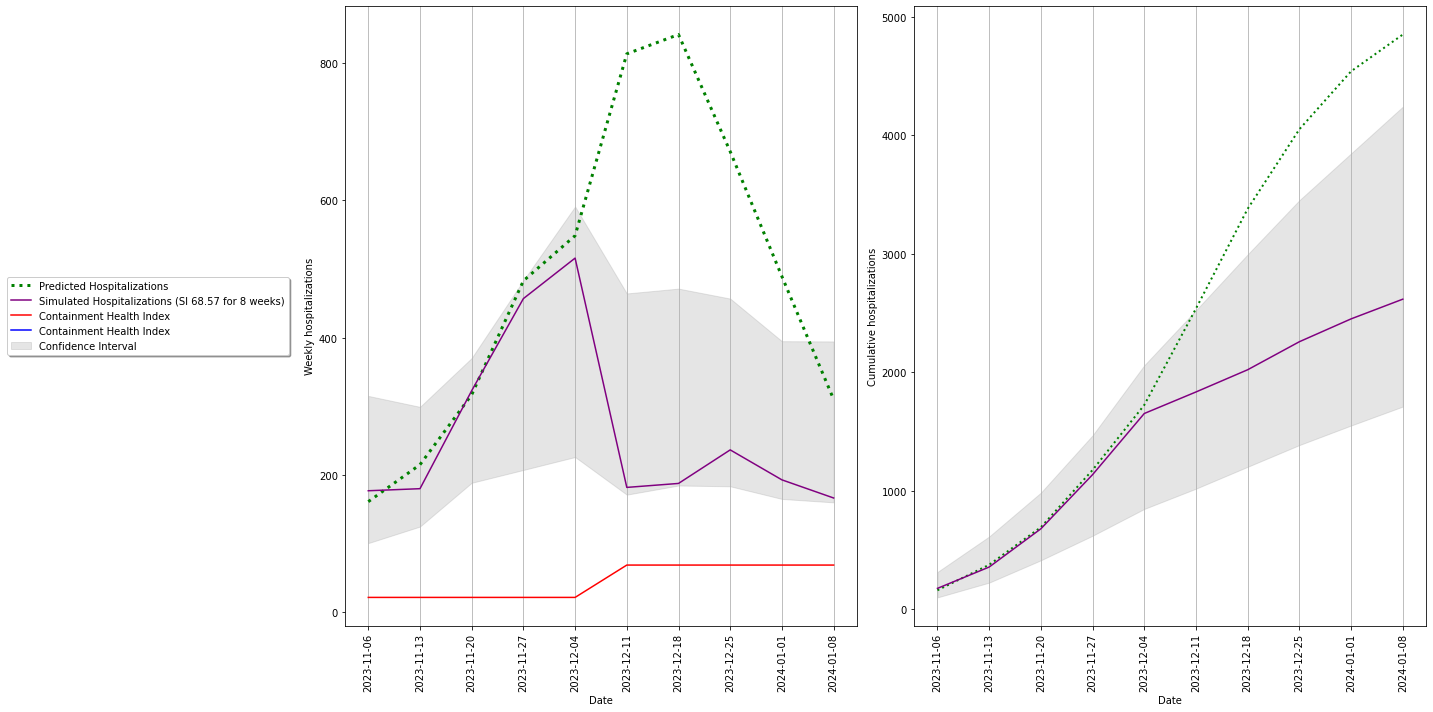

In [41]:
modified_data2 = modified_data[modified_data['chain']== '418']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), dpi=72)
ax1.plot(modified_data2['Date'], modified_data2['weekly_hospitalization'], color="green",linestyle=':', linewidth = 3, label='Predicted Hospitalizations')
#ax1.plot(modified_data2['Date'], modified_data2['simulation_LDvac'], c="Slateblue", label='Simulated Hospitalizations (Vaccine)')
ax1.plot(modified_data2['Date'], modified_data2['predicted_y_SI_new'], c="purple", label='Simulated Hospitalizations (SI 68.57 for 8 weeks)')
ax1.plot(modified_data2['Date'], modified_data2['CHI_lagged'], c="red", label='Containment Health Index')
ax1.plot(modified_data2['Date'], modified_data2['ContainmentHealthIndex_Average'], c="blue", label='Containment Health Index')
ax1.fill_between(modified_data2['Date'], modified_data2['lower_SI_New'], modified_data2['upper_SI_New'], alpha=0.2, color='gray', 
                        label='Confidence Interval')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax1.legend(loc ='center right', bbox_to_anchor=(-0.1, 0.5), fancybox=True, shadow=True) 
ax1.grid(axis='x') 
ax1.set_xlabel('Date') 
ax1.set_ylabel('Weekly hospitalizations')

ax2.plot(modified_data2['Date'], modified_data2['Cumulative_Hospitalization'],linestyle=':', color="green", linewidth = 2, label='Predicted Hospitalizations')
#ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_LD_vac'], c="Slateblue", label='Simulations (Distance to Vaccine)')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_simulated_SI_new'], c="purple", label='Simulations (SI 68.57 for 8 weeks)')
#ax2.legend(loc ='center left', bbox_to_anchor=(1, 0.5), fancybox=True, shadow=True) 
ax2.fill_between(modified_data2['Date'], modified_data2['Cumu_lci_SI_new'], modified_data2['Cumu_uci_SI_new'], alpha=0.2, color='gray', 
                        label='Confidence Interval')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
# Set major locator to start weeks from Monday 
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax2.grid(axis='x') 
ax2.set_xlabel('Date') 
ax2.set_ylabel('Cumulative hospitalizations')


# Rotate date labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=90)

# Ensure the subplots are the same size
plt.tight_layout()

# Show the plot
plt.show()

In [42]:
modified_data['vcr_lagged'] = modified_data['vcr_lagged2']

def update_vcr(modified_data):
    # Update the after 8 weeks
    modified_data.loc[(modified_data['week_num'] >= 6) , 'vcr_lagged'] *= 2
    modified_data.loc[modified_data['vcr_lagged'] > 96, 'vcr_lagged'] = 96
    return modified_data


modified_data = update_vcr(modified_data)


X_modified = modified_data[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',#'reinf_LD1',
           'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
    
    
    
log_predictions = updated_cat_model.predict(X_modified)
    
# Transform predictions back to the original scale
predictions = np.exp(log_predictions)
    
# Add predictions to the modified data
modified_data['predicted_y_SI_new2'] = predictions
modified_data['predicted_y_SI_new2_log'] = log_predictions
modified_data['Cumu_Hospitalization_simulated_SI_new2'] = modified_data.groupby('chain')['predicted_y_SI_new2'].cumsum()



In [43]:

predictions = get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params)


# 3. Calculate Confidence Intervals (Vectorized):
alpha = 0.05  # For 95% CI
lower_bound = np.quantile(predictions, alpha / 2, axis=0)
upper_bound = np.quantile(predictions, 1 - alpha / 2, axis=0)

# Calculate confidence intervals
modified_data['lower_SI_New2_log'] = lower_bound
modified_data['upper_SI_New2_log'] = upper_bound

modified_data['lower_SI_New2'] = np.exp(modified_data['lower_SI_New2_log'])
modified_data['upper_SI_New2'] = np.exp(modified_data['upper_SI_New2_log'])

modified_data['Cumu_lci_SI_new2'] = modified_data.groupby('chain')['lower_SI_New2'].cumsum()
modified_data['Cumu_uci_SI_new2'] = modified_data.groupby('chain')['upper_SI_New2'].cumsum()

print(modified_data)

     LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3      1       2.0       2    0.000000     1.00         1   52.380000   
4      1       6.0       2    0.000000     1.00         2   52.380000   
5      1       2.0       2    0.000000     1.00         3   50.680000   
6      1       2.0       2    0.000000     1.00         4   51.022857   
7      1       2.0       2    0.000000     1.00         5   51.790000   
..   ...       ...     ...         ...      ...       ...         ...   
228    2      40.0       5   36.961266     0.92        22   21.430000   
235   42      40.0      41   36.961266     0.92         7   68.570000   
236   42      34.0      41   37.514981     0.92         8   68.570000   
237   42      40.0      41   37.842760     0.92         9   68.570000   
238   42      39.0      41   37.878191     0.92        10   68.570000   

     LD_interaction       pct  Hospitalization  ...  Cumu_uci_SI_new  \
3                 2  1.000000             23.0  ...

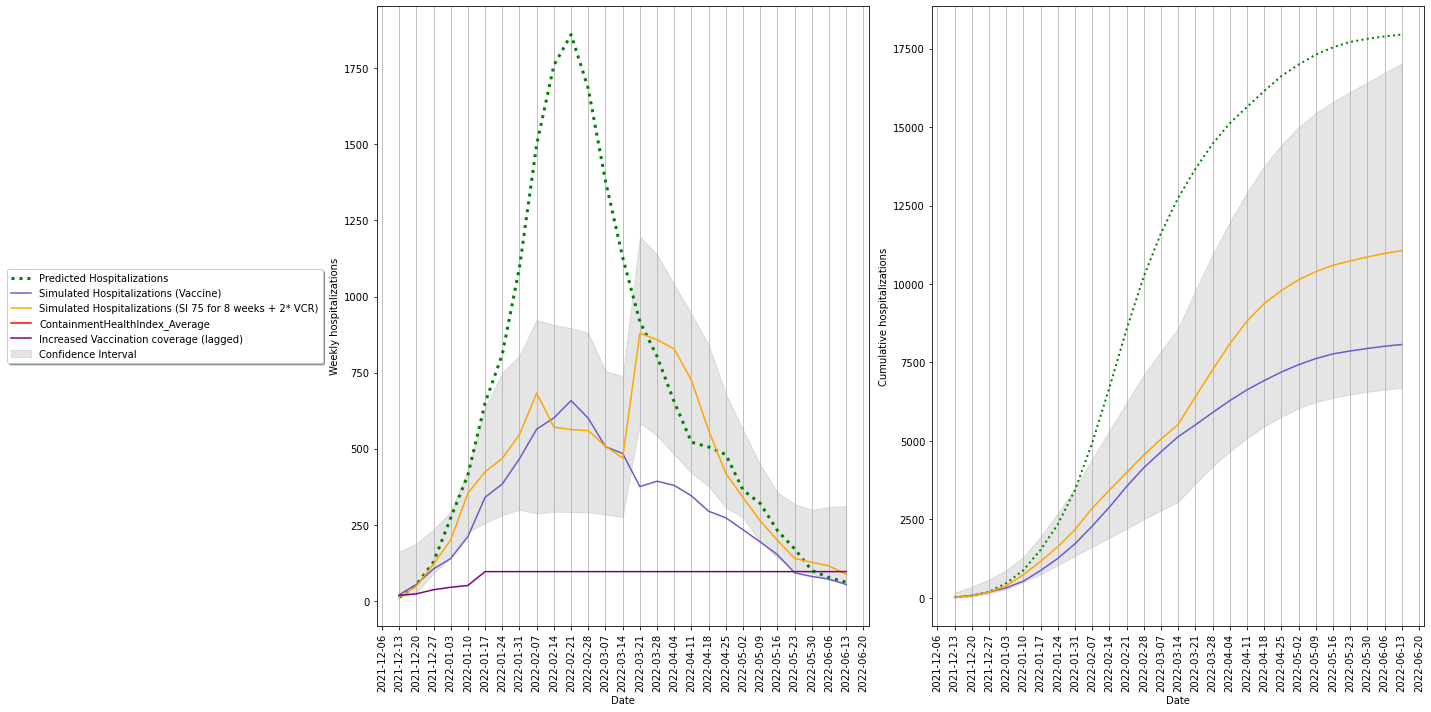

In [44]:
modified_data2 = modified_data[modified_data['chain']== '151']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), dpi=72)
ax1.plot(modified_data2['Date'], modified_data2['weekly_hospitalization'], color="green",linestyle=':', linewidth = 3, label='Predicted Hospitalizations')
ax1.plot(modified_data2['Date'], modified_data2['simulation_LDvac'], c="Slateblue", label='Simulated Hospitalizations (Vaccine)')
ax1.plot(modified_data2['Date'], modified_data2['predicted_y_SI_new2'], c="orange", label='Simulated Hospitalizations (SI 75 for 8 weeks + 2* VCR)')
ax1.plot(modified_data2['Date'], modified_data2['ContainmentHealthIndex_Average'], c="red", label='ContainmentHealthIndex_Average')
ax1.plot(modified_data2['Date'], modified_data2['vcr_lagged'], c="purple", label='Increased Vaccination coverage (lagged)')
ax1.fill_between(modified_data2['Date'], modified_data2['lower_SI_New2'], modified_data2['upper_SI_New2'], alpha=0.2, color='gray', 
                        label='Confidence Interval')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax1.legend(loc ='center right', bbox_to_anchor=(-0.1, 0.5), fancybox=True, shadow=True) 
ax1.grid(axis='x') 
ax1.set_xlabel('Date') 
ax1.set_ylabel('Weekly hospitalizations')

ax2.plot(modified_data2['Date'], modified_data2['Cumulative_Hospitalization'],linestyle=':', color="green", linewidth = 2, label='Predicted Hospitalizations')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_LD_vac'], c="Slateblue", label='Simulations (Distance to Vaccine)')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_simulated_SI_new2'], c="orange", label='Simulations (SI 75 for 8 weeks + 2* VCR)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
ax2.fill_between(modified_data2['Date'], modified_data2['Cumu_lci_SI_new2'], modified_data2['Cumu_uci_SI_new2'], alpha=0.2, color='gray', 
                        label='Confidence Interval')
# Set major locator to start weeks from Monday 
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax2.grid(axis='x') 
ax2.set_xlabel('Date') 
ax2.set_ylabel('Cumulative hospitalizations')


# Rotate date labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=90)

# Ensure the subplots are the same size
plt.tight_layout()

# Show the plot
plt.show()

In [45]:
modified_data['CHI_lagged'] = modified_data['CHI_lagged2']
modified_data['CH_week'] = modified_data['CHI_lagged'] * modified_data['week_num']
modified_data['CH_week'] = scaler.fit_transform(modified_data[['CH_week']])

#modified_data2['vcr_uptodate'] = modified_data2['vcr_uptodate2']

X_modified = modified_data[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',#'reinf_LD1',
           'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
    
    
log_predictions = updated_cat_model.predict(X_modified)
    
# Transform predictions back to the original scale
predictions = np.exp(log_predictions)
    
# Add predictions to the modified data
modified_data['predicted_y_SI_new3'] = predictions
modified_data['predicted_y_SI_new3_log'] = log_predictions
modified_data['Cumu_Hospitalization_simulated_SI_new3'] = modified_data.groupby('chain')['predicted_y_SI_new3'].cumsum()



In [46]:

predictions = get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params)


# 3. Calculate Confidence Intervals (Vectorized):
alpha = 0.05  # For 95% CI
lower_bound = np.quantile(predictions, alpha / 2, axis=0)
upper_bound = np.quantile(predictions, 1 - alpha / 2, axis=0)

# Calculate confidence intervals
modified_data['lower_SI_New3_log'] = lower_bound
modified_data['upper_SI_New3_log'] = upper_bound

modified_data['lower_SI_New3'] = np.exp(modified_data['lower_SI_New3_log'])
modified_data['upper_SI_New3'] = np.exp(modified_data['upper_SI_New3_log'])

modified_data['Cumu_lci_SI_new3'] = modified_data.groupby('chain')['lower_SI_New3'].cumsum()
modified_data['Cumu_uci_SI_new3'] = modified_data.groupby('chain')['upper_SI_New3'].cumsum()

print(modified_data)

     LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3      1       2.0       2    0.000000     1.00         1   52.380000   
4      1       6.0       2    0.000000     1.00         2   52.380000   
5      1       2.0       2    0.000000     1.00         3   50.680000   
6      1       2.0       2    0.000000     1.00         4   51.022857   
7      1       2.0       2    0.000000     1.00         5   51.790000   
..   ...       ...     ...         ...      ...       ...         ...   
228    2      40.0       5   36.961266     0.92        22   21.430000   
235   42      40.0      41   36.961266     0.92         7   21.430000   
236   42      34.0      41   37.514981     0.92         8   21.430000   
237   42      40.0      41   37.842760     0.92         9   21.430000   
238   42      39.0      41   37.878191     0.92        10   21.430000   

     LD_interaction       pct  Hospitalization  ...  Cumu_uci_SI_new2  \
3                 2  1.000000             23.0  ..

In [47]:
def update_stringency_index(modified_data):
    # Update the first 2 weeks (assuming each week is 7 days)
    modified_data.loc[(modified_data['week_num'] >= 6) & (modified_data['week_num'] < 15), 'CHI_lagged'] = 68.57
    # Update the next 2 weeks
    modified_data.loc[(modified_data['week_num'] >= 15), 'CHI_lagged'] = 68.57
    return modified_data

modified_data = update_stringency_index(modified_data)
modified_data['CH_week'] = modified_data['CHI_lagged'] * modified_data['week_num']
modified_data['CH_week'] = scaler.fit_transform(modified_data[['CH_week']])

#modified_data[['reinf_LD1', 'vcr_LDvac']] = scaler.fit_transform(modified_data[['reinf_LD1', 'vcr_LDvac']])

X_modified = modified_data[['LD1','pct_reif', 'LD_vac','vcr_lagged','HR_hosp','week_num', 'CHI_lagged','CH_week',
           'Jan', 'Feb', 'Mar', 'Apr', 'May',  'Jun', 'Jul','Aug',  'Sep' ,'Oct','Nov','Dec']]
    
log_predictions = updated_cat_model.predict(X_modified)
    
# Transform predictions back to the original scale
predictions = np.exp(log_predictions)
    
# Add predictions to the modified data
modified_data['predicted_y_SI_new4'] = predictions
modified_data['predicted_y_SI_new4_log'] = log_predictions
modified_data['Cumu_Hospitalization_simulated_SI_new4'] = modified_data.groupby('chain')['predicted_y_SI_new4'].cumsum()



In [48]:

predictions = get_bootstrap_predictions(X_train, y_train, X_modified, n_bootstraps, model_params)


# 3. Calculate Confidence Intervals (Vectorized):
alpha = 0.05  # For 95% CI
lower_bound = np.quantile(predictions, alpha / 2, axis=0)
upper_bound = np.quantile(predictions, 1 - alpha / 2, axis=0)

# Calculate confidence intervals
modified_data['lower_SI_New4_log'] = lower_bound
modified_data['upper_SI_New4_log'] = upper_bound

modified_data['lower_SI_New4'] = np.exp(modified_data['lower_SI_New4_log'])
modified_data['upper_SI_New4'] = np.exp(modified_data['upper_SI_New4_log'])

modified_data['Cumu_lci_SI_new4'] = modified_data.groupby('chain')['lower_SI_New4'].cumsum()
modified_data['Cumu_uci_SI_new4'] = modified_data.groupby('chain')['upper_SI_New4'].cumsum()

print(modified_data)


     LD1  pct_reif  LD_vac  vcr_lagged  HR_hosp  week_num  CHI_lagged  \
3      1       2.0       2    0.000000     1.00         1   52.380000   
4      1       6.0       2    0.000000     1.00         2   52.380000   
5      1       2.0       2    0.000000     1.00         3   50.680000   
6      1       2.0       2    0.000000     1.00         4   51.022857   
7      1       2.0       2    0.000000     1.00         5   51.790000   
..   ...       ...     ...         ...      ...       ...         ...   
228    2      40.0       5   36.961266     0.92        22   68.570000   
235   42      40.0      41   36.961266     0.92         7   68.570000   
236   42      34.0      41   37.514981     0.92         8   68.570000   
237   42      40.0      41   37.842760     0.92         9   68.570000   
238   42      39.0      41   37.878191     0.92        10   68.570000   

     LD_interaction       pct  Hospitalization  ...  Cumu_uci_SI_new3  \
3                 2  1.000000             23.0  ..

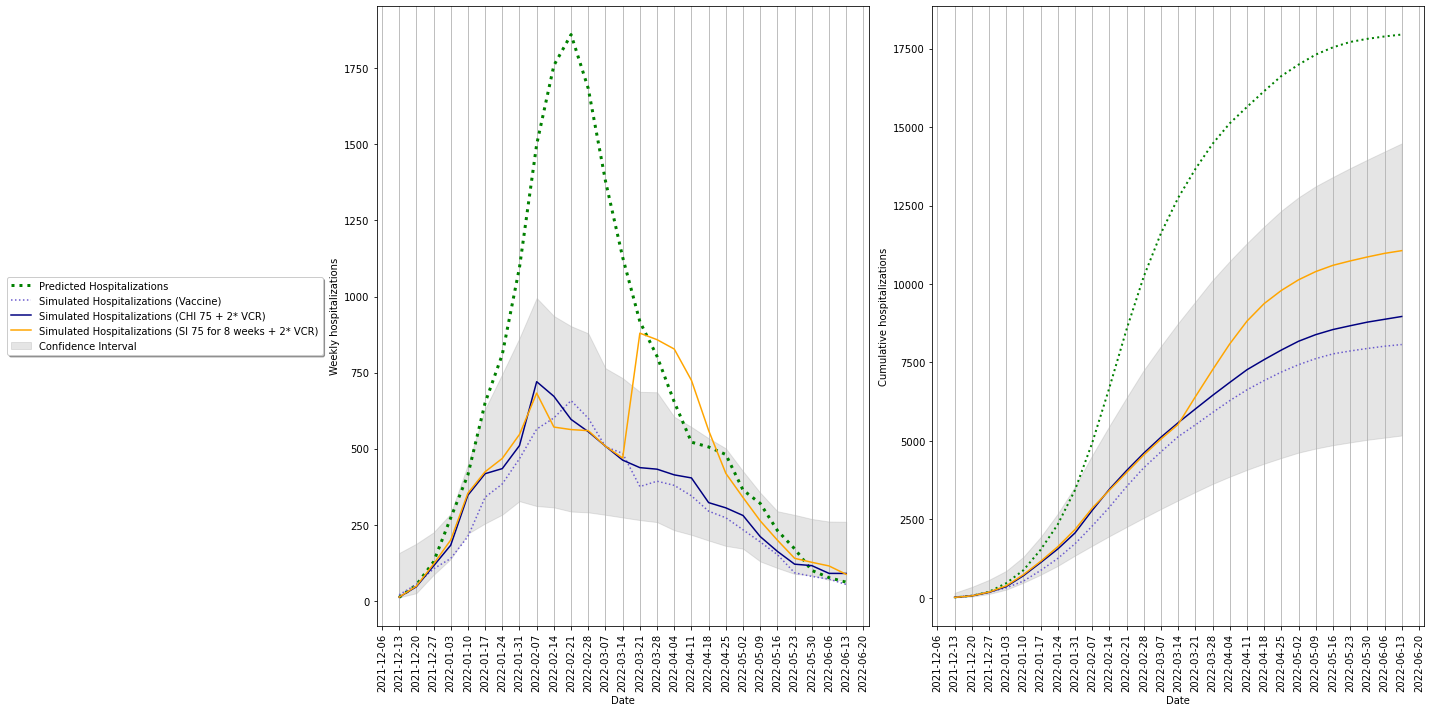

In [49]:

#modified_data2 = modified_data[modified_data['chain']== 'Simulation']
modified_data2 = modified_data[modified_data['chain']== '151']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), dpi=72)
ax1.plot(modified_data2['Date'], modified_data2['weekly_hospitalization'], color="green",linestyle=':', linewidth = 3, label='Predicted Hospitalizations')
ax1.plot(modified_data2['Date'], modified_data2['simulation_LDvac'], c="Slateblue",linestyle=':', label='Simulated Hospitalizations (Vaccine)')
ax1.plot(modified_data2['Date'], modified_data2['predicted_y_SI_new4'], c="navy", label='Simulated Hospitalizations (CHI 75 + 2* VCR)')
#ax1.plot(modified_data2['Date'], modified_data2['ContainmentHealthIndex_Average'], c="red", label='ContainmentHealthIndex')
#ax1.plot(modified_data2['Date'], modified_data2['vcr_uptodate'], c="purple", label='Increased Vaccination coverage')
ax1.plot(modified_data2['Date'], modified_data2['predicted_y_SI_new2'], c="orange", label='Simulated Hospitalizations (SI 75 for 8 weeks + 2* VCR)')
ax1.fill_between(modified_data2['Date'], modified_data2['lower_SI_New4'], modified_data2['upper_SI_New4'], alpha=0.2, color='gray', 
                        label='Confidence Interval')
ax1.legend(loc ='center right', bbox_to_anchor=(-0.1, 0.5), fancybox=True, shadow=True) 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax1.grid(axis='x') 
ax1.set_xlabel('Date') 
ax1.set_ylabel('Weekly hospitalizations')

ax2.plot(modified_data2['Date'], modified_data2['Cumulative_Hospitalization'],linestyle=':', color="green", linewidth = 2, label='Predicted Hospitalizations')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_LD_vac'], c="Slateblue",linestyle=':', label='Simulations (Distance to Vaccine)')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_simulated_SI_new4'], c="navy", label='Simulations (CHI 75 + 2* VCR)')
ax2.plot(modified_data2['Date'], modified_data2['Cumu_Hospitalization_simulated_SI_new2'], c="orange", label='Simulations (SI 75 for 8 weeks + 2* VCR)')
ax2.fill_between(modified_data2['Date'], modified_data2['Cumu_lci_SI_new4'], modified_data2['Cumu_uci_SI_new4'], alpha=0.2, color='gray', 
                        label='Confidence Interval')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) 
# Set major locator to start weeks from Monday 
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MONDAY, interval=1))
ax2.grid(axis='x') 
ax2.set_xlabel('Date') 
ax2.set_ylabel('Cumulative hospitalizations')


# Rotate date labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=90)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=90)

# Ensure the subplots are the same size
plt.tight_layout()

# Show the plot
plt.show()



In [50]:
modified_data['chain2'] = modified_data['chain']

modified_data['Cumu_Hospitalization_LD_vac'] = modified_data.groupby('chain')['simulation_LDvac'].cumsum()
modified_data['Cumulative_Hospitalization'] = modified_data.groupby('chain')['weekly_hospitalization'].cumsum()
modified_data['Cumu_lower_LDvac'] = modified_data.groupby('chain')['lower_LDvac'].cumsum()
modified_data['Cumu_upper_LDvac'] = modified_data.groupby('chain')['upper_LDvac'].cumsum()
modified_data['Cumu_Hospitalization_simulated_SI_new'] = modified_data.groupby('chain')['predicted_y_SI_new'].cumsum()
modified_data['Cumu_lci_SI_new'] = modified_data.groupby('chain')['lower_SI_New'].cumsum()
modified_data['Cumu_uci_SI_new'] = modified_data.groupby('chain')['upper_SI_New'].cumsum()
modified_data['Cumu_Hospitalization_simulated_SI_newt'] = modified_data.groupby('chain')['predicted_y_SI_newt'].cumsum()
modified_data['Cumu_lci_SI_newt'] = modified_data.groupby('chain')['lower_SI_Newt'].cumsum()
modified_data['Cumu_uci_SI_newt'] = modified_data.groupby('chain')['upper_SI_Newt'].cumsum()
modified_data['Cumu_Hospitalization_simulated_SI_new2'] = modified_data.groupby('chain')['predicted_y_SI_new2'].cumsum()
modified_data['Cumu_lci_SI_new2'] = modified_data.groupby('chain')['lower_SI_New2'].cumsum()
modified_data['Cumu_uci_SI_new2'] = modified_data.groupby('chain')['upper_SI_New2'].cumsum()
modified_data['Cumu_Hospitalization_simulated_SI_new3'] = modified_data.groupby('chain')['predicted_y_SI_new3'].cumsum()
modified_data['Cumu_lci_SI_new3'] = modified_data.groupby('chain')['lower_SI_New3'].cumsum()
modified_data['Cumu_uci_SI_new3'] = modified_data.groupby('chain')['upper_SI_New3'].cumsum()
modified_data['Cumu_Hospitalization_simulated_SI_new3'] = modified_data.groupby('chain')['predicted_y_SI_new3'].cumsum()
modified_data['Cumu_lci_SI_new3'] = modified_data.groupby('chain')['lower_SI_New3'].cumsum()
modified_data['Cumu_uci_SI_new3'] = modified_data.groupby('chain')['upper_SI_New3'].cumsum()

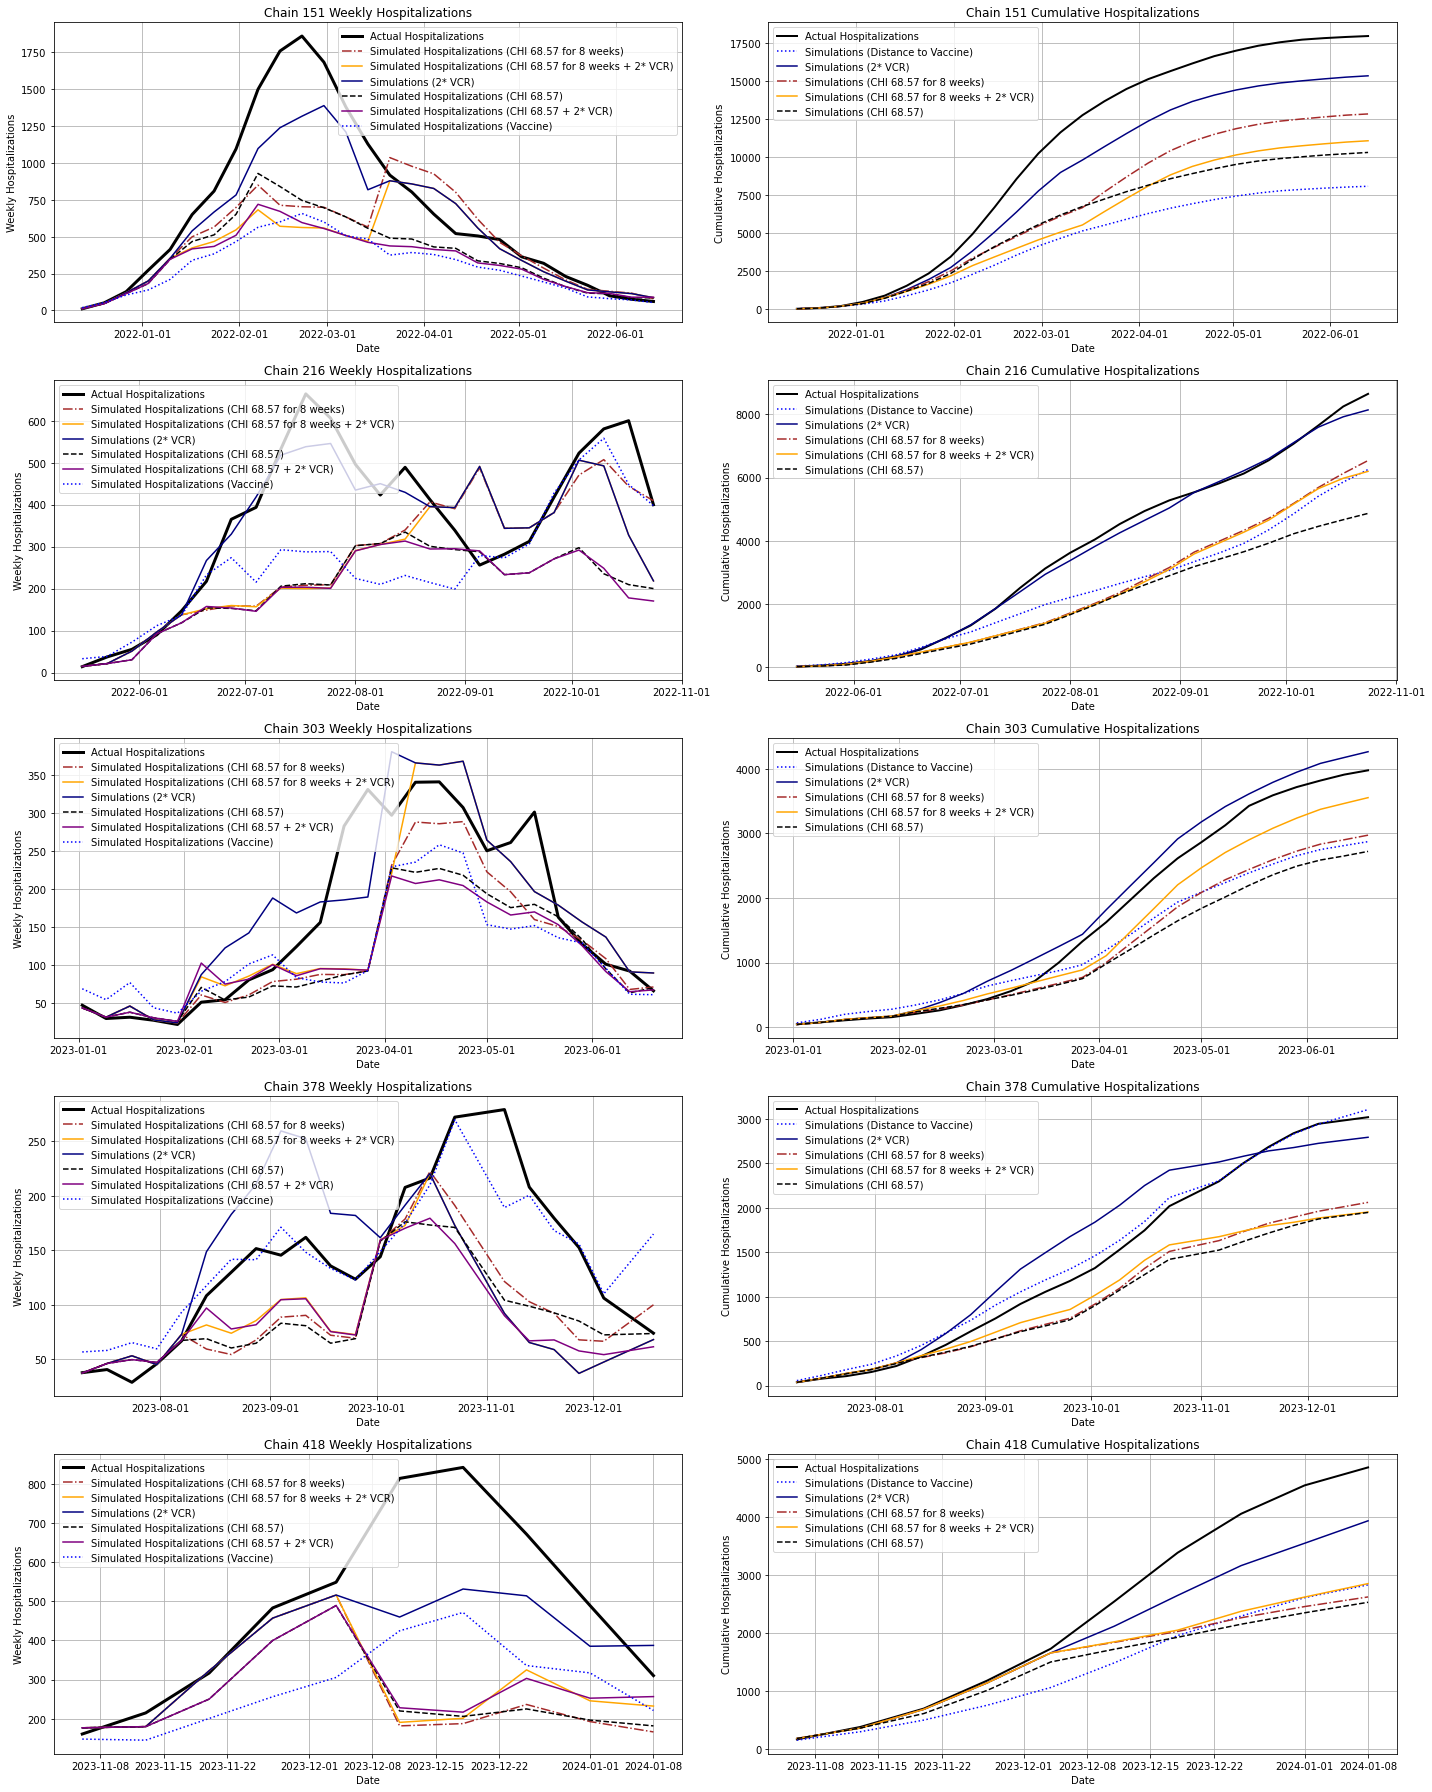

In [51]:
chains_to_plot = [151, 216,303, 378, 418]  # Chains to include
fig, axs = plt.subplots(len(chains_to_plot), 2, figsize=(20, 5 * len(chains_to_plot)), dpi=72)  # Grid layout

for i, chain in enumerate(chains_to_plot):
    # Filter data for the current chain
    chain_data = modified_data[modified_data['chain'] == str(chain)]
    
    # Subplot for weekly hospitalizations
    axs[i, 0].plot(chain_data['Date'], chain_data['weekly_hospitalization'], color="black", linewidth=3, label='Actual Hospitalizations')
    axs[i, 0].plot(chain_data['Date'], chain_data['predicted_y_SI_new'], color="brown", linestyle='-.', label='Simulated Hospitalizations (CHI 68.57 for 8 weeks)')
    axs[i, 0].plot(chain_data['Date'], chain_data['predicted_y_SI_new2'], color="orange", label='Simulated Hospitalizations (CHI 68.57 for 8 weeks + 2* VCR)')
    axs[i, 0].plot(chain_data['Date'], chain_data['predicted_y_SI_new3'], c="navy", label='Simulations (2* VCR)')
    axs[i, 0].plot(chain_data['Date'], chain_data['predicted_y_SI_newt'], c="black",linestyle='--', label='Simulated Hospitalizations (CHI 68.57)')
    axs[i, 0].plot(chain_data['Date'], chain_data['predicted_y_SI_new4'], c="purple", label='Simulated Hospitalizations (CHI 68.57 + 2* VCR)')
    axs[i, 0].plot(chain_data['Date'], chain_data['simulation_LDvac'], c="blue",linestyle=':', label='Simulated Hospitalizations (Vaccine)')
    axs[i, 0].legend(loc='best')
    axs[i, 0].set_title(f'Chain {chain} Weekly Hospitalizations')
    axs[i, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axs[i, 0].set_xlabel('Date')
    axs[i, 0].set_ylabel('Weekly Hospitalizations')
    axs[i, 0].grid(True)
    
    # Subplot for cumulative hospitalizations
    axs[i, 1].plot(chain_data['Date'], chain_data['Cumulative_Hospitalization'], color="black", linewidth=2, label='Actual Hospitalizations')
    #axs[i, 1].plot(chain_data['Date'], chain_data['Cumu_Hospitalization_simulated_2024'], color="green", linestyle=':', linewidth=2, label='Simulated Hospitalizations')
    axs[i, 1].plot(chain_data['Date'], chain_data['Cumu_Hospitalization_LD_vac'], c="blue", linestyle=':',label='Simulations (Distance to Vaccine)')
    axs[i, 1].plot(chain_data['Date'], chain_data['Cumu_Hospitalization_simulated_SI_new3'], c="navy", label='Simulations (2* VCR)')
    axs[i, 1].plot(chain_data['Date'], chain_data['Cumu_Hospitalization_simulated_SI_new'], c="brown",linestyle='-.', label='Simulations (CHI 68.57 for 8 weeks)')
    axs[i, 1].plot(chain_data['Date'], chain_data['Cumu_Hospitalization_simulated_SI_new2'], c="orange", label='Simulations (CHI 68.57 for 8 weeks + 2* VCR)')
    axs[i, 1].plot(chain_data['Date'], chain_data['Cumu_Hospitalization_simulated_SI_newt'], c="black",linestyle='--', label='Simulations (CHI 68.57)')
    #axs[i, 1].plot(chain_data['Date'], chain_data['Cumu_Hospitalization_simulated_SI_new'], color="brown", linestyle='-.', label='Cumulative Simulated Hospitalizations (CHI 75 for 8 weeks)')
    axs[i, 1].legend(loc='best')
    axs[i, 1].set_title(f'Chain {chain} Cumulative Hospitalizations')
    axs[i, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axs[i, 1].set_xlabel('Date')
    axs[i, 1].set_ylabel('Cumulative Hospitalizations')
    axs[i, 1].grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('hospitalizations_chains.png')
plt.show()


In [52]:
sum_value = modified_data.groupby('chain')[['simulation_LDvac', 'lower_LDvac', 'upper_LDvac']].sum().reset_index()
sum_value = sum_value.rename(columns={
    'simulation_LDvac': 'values',
    'lower_LDvac': 'lower',
    'upper_LDvac': 'upper'
})
sum_value['name'] = 'LDvac'

sum_value2 = modified_data.groupby('chain')[['predicted_y_SI_new', 'lower_SI_New', 'upper_SI_New']].sum().reset_index()  # Correct groupby
sum_value2 = sum_value2.rename(columns={  # Rename columns for sum_value2
    'predicted_y_SI_new': 'values',
    'lower_SI_New': 'lower',
    'upper_SI_New': 'upper'
})
sum_value2['name'] = 'SI_New'

sum_value3 = modified_data.groupby('chain')[['predicted_y_SI_newt', 'lower_SI_Newt', 'upper_SI_Newt']].sum().reset_index()  # Correct groupby
sum_value3 = sum_value3.rename(columns={  # Rename columns for sum_value3
    'predicted_y_SI_newt': 'values',
    'lower_SI_Newt': 'lower',
    'upper_SI_Newt': 'upper'
})
sum_value3['name'] = 'SI_Newt'

sum_value4 = modified_data.groupby('chain')[['predicted_y_SI_new2', 'lower_SI_New2', 'upper_SI_New2']].sum().reset_index()  # Correct groupby
sum_value4 = sum_value4.rename(columns={  # Rename columns for sum_value4
    'predicted_y_SI_new2': 'values',
    'lower_SI_New2': 'lower',
    'upper_SI_New2': 'upper'
})
sum_value4['name'] = 'SI_New2'

sum_value5 = modified_data.groupby('chain')[['predicted_y_SI_new3', 'lower_SI_New3', 'upper_SI_New3']].sum().reset_index()  # Correct groupby
sum_value5 = sum_value5.rename(columns={  # Rename columns for sum_value5
    'predicted_y_SI_new3': 'values',
    'lower_SI_New3': 'lower',
    'upper_SI_New3': 'upper'
})
sum_value5['name'] = 'SI_New3'

sum_value6 = modified_data.groupby('chain')[['predicted_y_SI_new4', 'lower_SI_New4', 'upper_SI_New4']].sum().reset_index()  # Correct groupby
sum_value6 = sum_value6.rename(columns={  # Rename columns for sum_value6
    'predicted_y_SI_new4': 'values',
    'lower_SI_New4': 'lower',
    'upper_SI_New4': 'upper'
})
sum_value6['name'] = 'SI_New4'

sum_value7 = modified_data.groupby('chain')[['weekly_hospitalization']].sum().reset_index()  # Correct groupby
sum_value7 = sum_value7.rename(columns={  # Rename columns for sum_value7
    'weekly_hospitalization': 'values'
})
sum_value7['name'] = 'weekly_hospitalization'

#sum_value8 = modified_data.groupby('chain')[['simulation_2024']].sum().reset_index()  # Correct groupby
#sum_value8 = sum_value8.rename(columns={  # Rename columns for sum_value8
#    'simulation_2024': 'values'
#})
#sum_value8['name'] = 'simulation_2024'



combined_df = pd.concat([sum_value, sum_value2, sum_value3, sum_value4, sum_value5, sum_value6, sum_value7], ignore_index=True)
print(combined_df)

   chain       values        lower         upper                    name
0    100   242.849460    68.549882    628.620235                   LDvac
1    105   765.244002   465.291886   1099.304426                   LDvac
2    123  2504.005876  1656.034980   3188.144378                   LDvac
3    125  1197.554427   664.022395   1299.983427                   LDvac
4    151  8070.123485  5005.957123  13090.310459                   LDvac
..   ...          ...          ...           ...                     ...
93    29  6777.914045          NaN           NaN  weekly_hospitalization
94   303  3976.101181          NaN           NaN  weekly_hospitalization
95   378  3018.459987          NaN           NaN  weekly_hospitalization
96   418  4850.901173          NaN           NaN  weekly_hospitalization
97    53  2985.172017          NaN           NaN  weekly_hospitalization

[98 rows x 5 columns]


In [53]:
name_mapping = {
    'LDvac': 'Closer vaccine strain',  
    'SI_New': 'CHI 68.57 for 8 weeks',  
    'SI_Newt': 'CHI 68.57',  
    'SI_New2': 'CHI 68.57 for 8 weeks + 2* VCR',  
    'SI_New3': '2* VCR',  
    'SI_New4': 'CHI 68.57 + 2* VCR',  
    'weekly_hospitalization': 'Hospitalizations'#,  
    #'simulation_2024': 'Simulation'  
}

combined_df['name2'] = combined_df['name'].map(name_mapping)

In [54]:
# Extract required columns and rename `values` to `actual`
sum_value7_modified = sum_value7[['chain', 'values']].rename(columns={'values': 'actual'})

# Merge the modified sum_value7 with df
#df = df.merge(sum_value7_modified, on='chain', how='left')
combined_df = combined_df.merge(sum_value7_modified, on='chain', how='left')

print(combined_df)

   chain       values        lower         upper                    name  \
0    100   242.849460    68.549882    628.620235                   LDvac   
1    105   765.244002   465.291886   1099.304426                   LDvac   
2    123  2504.005876  1656.034980   3188.144378                   LDvac   
3    125  1197.554427   664.022395   1299.983427                   LDvac   
4    151  8070.123485  5005.957123  13090.310459                   LDvac   
..   ...          ...          ...           ...                     ...   
93    29  6777.914045          NaN           NaN  weekly_hospitalization   
94   303  3976.101181          NaN           NaN  weekly_hospitalization   
95   378  3018.459987          NaN           NaN  weekly_hospitalization   
96   418  4850.901173          NaN           NaN  weekly_hospitalization   
97    53  2985.172017          NaN           NaN  weekly_hospitalization   

                    name2        actual  
0   Closer vaccine strain    246.590690  
1  

In [55]:
combined_df['percent_reduction'] = ((combined_df['values'] - combined_df['actual'] ) / combined_df['actual']) * 100
combined_df['percent_reduction_lci'] = ((combined_df['lower'] - combined_df['actual']) / combined_df['actual']) * 100
combined_df['percent_reduction_uci'] = ((combined_df['upper'] - combined_df['actual']) / combined_df['actual']) * 100
print(combined_df)

   chain       values        lower         upper                    name  \
0    100   242.849460    68.549882    628.620235                   LDvac   
1    105   765.244002   465.291886   1099.304426                   LDvac   
2    123  2504.005876  1656.034980   3188.144378                   LDvac   
3    125  1197.554427   664.022395   1299.983427                   LDvac   
4    151  8070.123485  5005.957123  13090.310459                   LDvac   
..   ...          ...          ...           ...                     ...   
93    29  6777.914045          NaN           NaN  weekly_hospitalization   
94   303  3976.101181          NaN           NaN  weekly_hospitalization   
95   378  3018.459987          NaN           NaN  weekly_hospitalization   
96   418  4850.901173          NaN           NaN  weekly_hospitalization   
97    53  2985.172017          NaN           NaN  weekly_hospitalization   

                    name2        actual  percent_reduction  \
0   Closer vaccine strain

In [56]:
result = modified_data.groupby('chain')['CHI_lagged2'].agg(
    average_CHI_lagged='mean',
    max_CHI_lagged='max'
).reset_index()
merged_df = pd.merge(combined_df, result, on='chain', how='left')
result2 = modified_data.groupby('chain')['vcr_lagged2'].agg(
    max_vcr_lagged='max'
).reset_index()

merged_df = pd.merge(merged_df, result2, on='chain', how='left')

result3 = modified_data.groupby('chain')['LD1'].agg(
    LD1='max'
).reset_index()

merged_df = pd.merge(merged_df, result3, on='chain', how='left')

result4 = modified_data.groupby('chain')['LD_vac2'].agg(
    LDvac='max'
).reset_index()

merged_df = pd.merge(merged_df, result4, on='chain', how='left')

print(merged_df)

   chain       values        lower         upper                    name  \
0    100   242.849460    68.549882    628.620235                   LDvac   
1    105   765.244002   465.291886   1099.304426                   LDvac   
2    123  2504.005876  1656.034980   3188.144378                   LDvac   
3    125  1197.554427   664.022395   1299.983427                   LDvac   
4    151  8070.123485  5005.957123  13090.310459                   LDvac   
..   ...          ...          ...           ...                     ...   
93    29  6777.914045          NaN           NaN  weekly_hospitalization   
94   303  3976.101181          NaN           NaN  weekly_hospitalization   
95   378  3018.459987          NaN           NaN  weekly_hospitalization   
96   418  4850.901173          NaN           NaN  weekly_hospitalization   
97    53  2985.172017          NaN           NaN  weekly_hospitalization   

                    name2        actual  percent_reduction  \
0   Closer vaccine strain

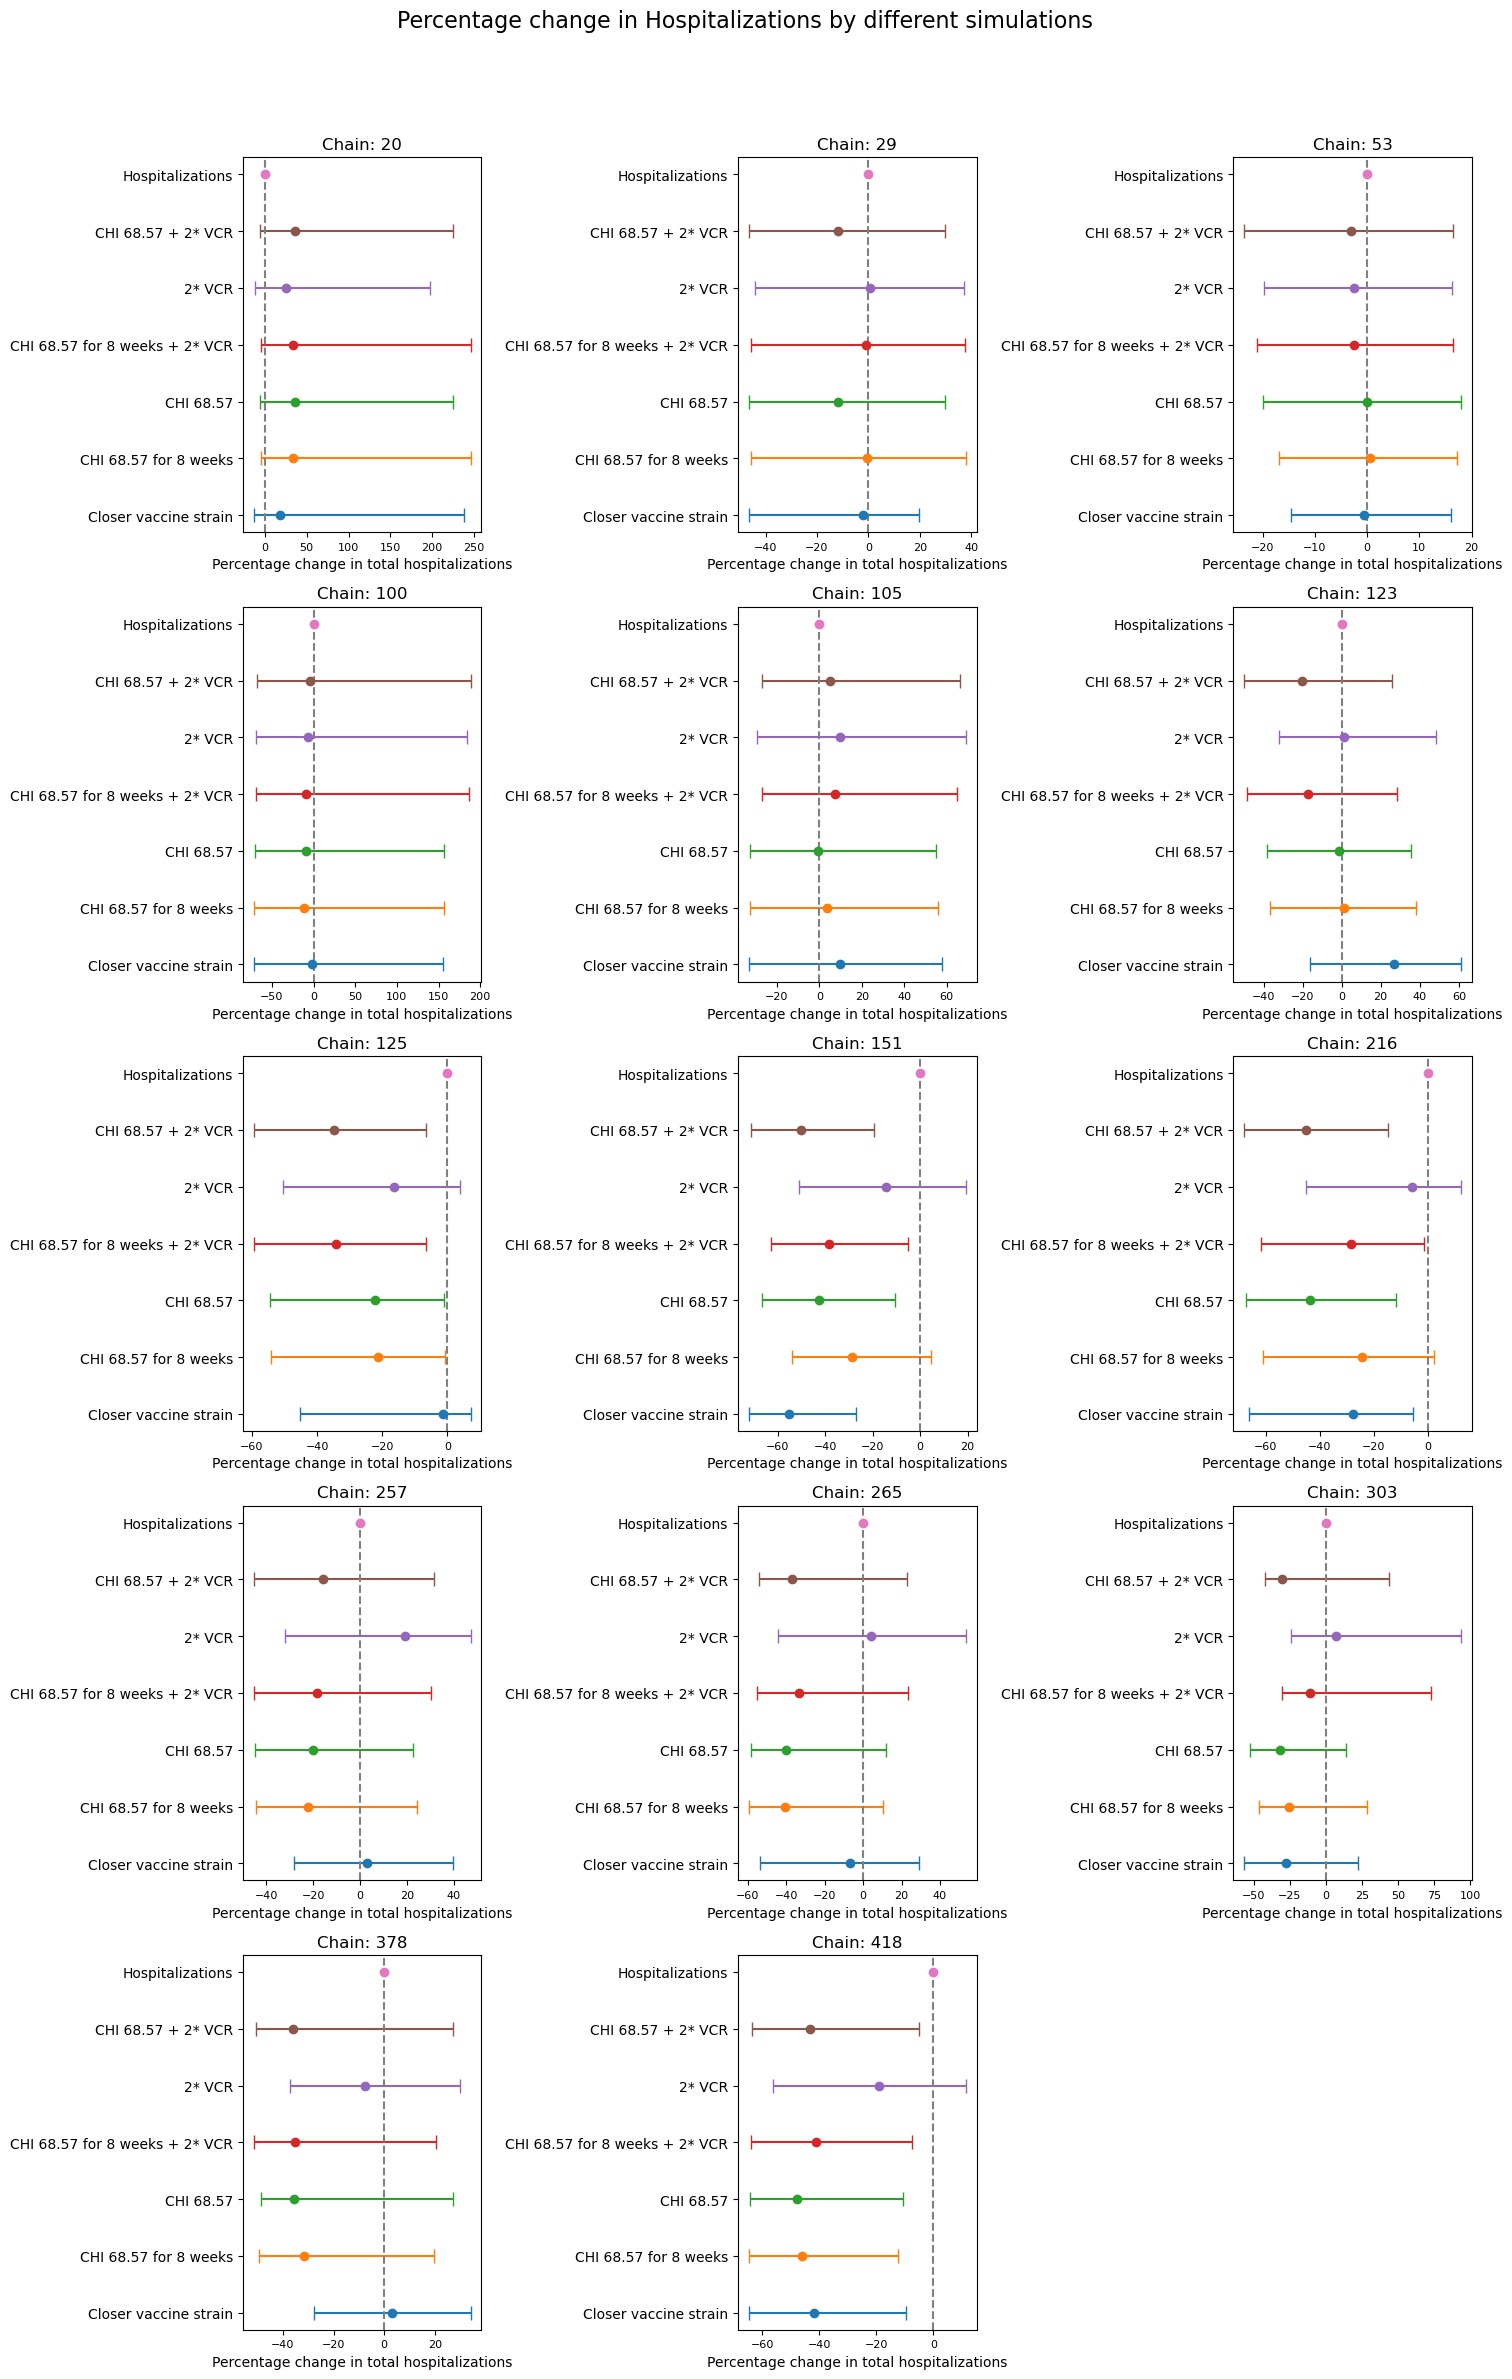

In [57]:
# Calculate the number of rows and columns for the subplots grid
ncols = 3  # Adjust as needed
nrows = (len(chains) + ncols - 1) // ncols  # Calculate rows dynamically

# Create the figure and subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows), dpi=100) #sharex for the same x axis

# Flatten the axes array for easier iteration (if needed)
if isinstance(axes, np.ndarray): #If there are more than 1 subplot
    axes = axes.flatten()
else:
    axes = [axes] #If there is only one subplot, make it a list

# Iterate over each unique 'chain' value and plot on separate subplots
for i, chain_val in enumerate(chains):
    ax = axes[i]  # Select the correct subplot axes

    chain_df = combined_df[combined_df['chain'] == chain_val]

    for name2_val in chain_df['name2'].unique():
        subset = chain_df[chain_df['name2'] == name2_val]
        ax.errorbar(subset['percent_reduction'], subset['name2'],
                     xerr=[subset['percent_reduction'] - subset['percent_reduction_lci'], subset['percent_reduction_uci'] - subset['percent_reduction']],
                     fmt='o', capsize=5, label=name2_val)  # Label without chain

    # Add vertical line for 'simulation_2024' (if it exists for this chain)
    simulation_2024_val = subset[subset['name'] == 'weekly_hospitalization']['percent_reduction'].values
    if len(simulation_2024_val) > 0:  # Check if it exists
        ax.axvline(x=simulation_2024_val[0], linestyle='--', color='gray', label='Actual')

    ax.set_xlabel('Percentage change in total hospitalizations')
    ax.set_title(f'Chain: {chain_val}')  # Title for each subplot
    #ax.legend(fontsize='small') #Legend for each subplot
    ax.tick_params(axis='x', labelsize=8) #Adjust x label size

# Hide any unused subplots
for j in range(i + 1, len(axes)):  # Hide empty subplots
    axes[j].set_axis_off()

fig.suptitle('Percentage change in Hospitalizations by different simulations', fontsize=16) #Overall title for the figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap with suptitle
plt.savefig('hospitalizations_pct2.png')
plt.show()

In [58]:
name_to_sim = {
    'Closer vaccine strain': 'Simulation 1 - better-matched vaccine strain',
    'CHI 68.57': 'Simulation 2 - sustained high CHI',
    'CHI 68.57 for 8 weeks': 'Simulation 3 - temporary high CHI',
    '2* VCR': 'Simulation 4 - doubling Vaccination Coverage (VCR)',
    'CHI 68.57 + 2* VCR': 'Simulation 5 - sustained high CHI + doubling VCR',
    'CHI 68.57 for 8 weeks + 2* VCR': 'Simulation 6 - temporary high CHI + doubling VCR',
    'Hospitalizations': 'Hospitalizations'
}
# Apply the mapping
combined_df['Simulation'] = combined_df['name2'].map(name_to_sim)
count_table = combined_df.groupby(['name2', 'Simulation']).size().reset_index(name='Count')
count_table = count_table[count_table['Count'] > 0]

print(count_table)

                            name2  \
0                          2* VCR   
1                       CHI 68.57   
2              CHI 68.57 + 2* VCR   
3           CHI 68.57 for 8 weeks   
4  CHI 68.57 for 8 weeks + 2* VCR   
5           Closer vaccine strain   
6                Hospitalizations   

                                          Simulation  Count  
0  Simulation 4 - doubling Vaccination Coverage (...     14  
1                  Simulation 2 - sustained high CHI     14  
2   Simulation 5 - sustained high CHI + doubling VCR     14  
3                  Simulation 3 - temporary high CHI     14  
4   Simulation 6 - temporary high CHI + doubling VCR     14  
5       Simulation 1 - better-matched vaccine strain     14  
6                                   Hospitalizations     14  


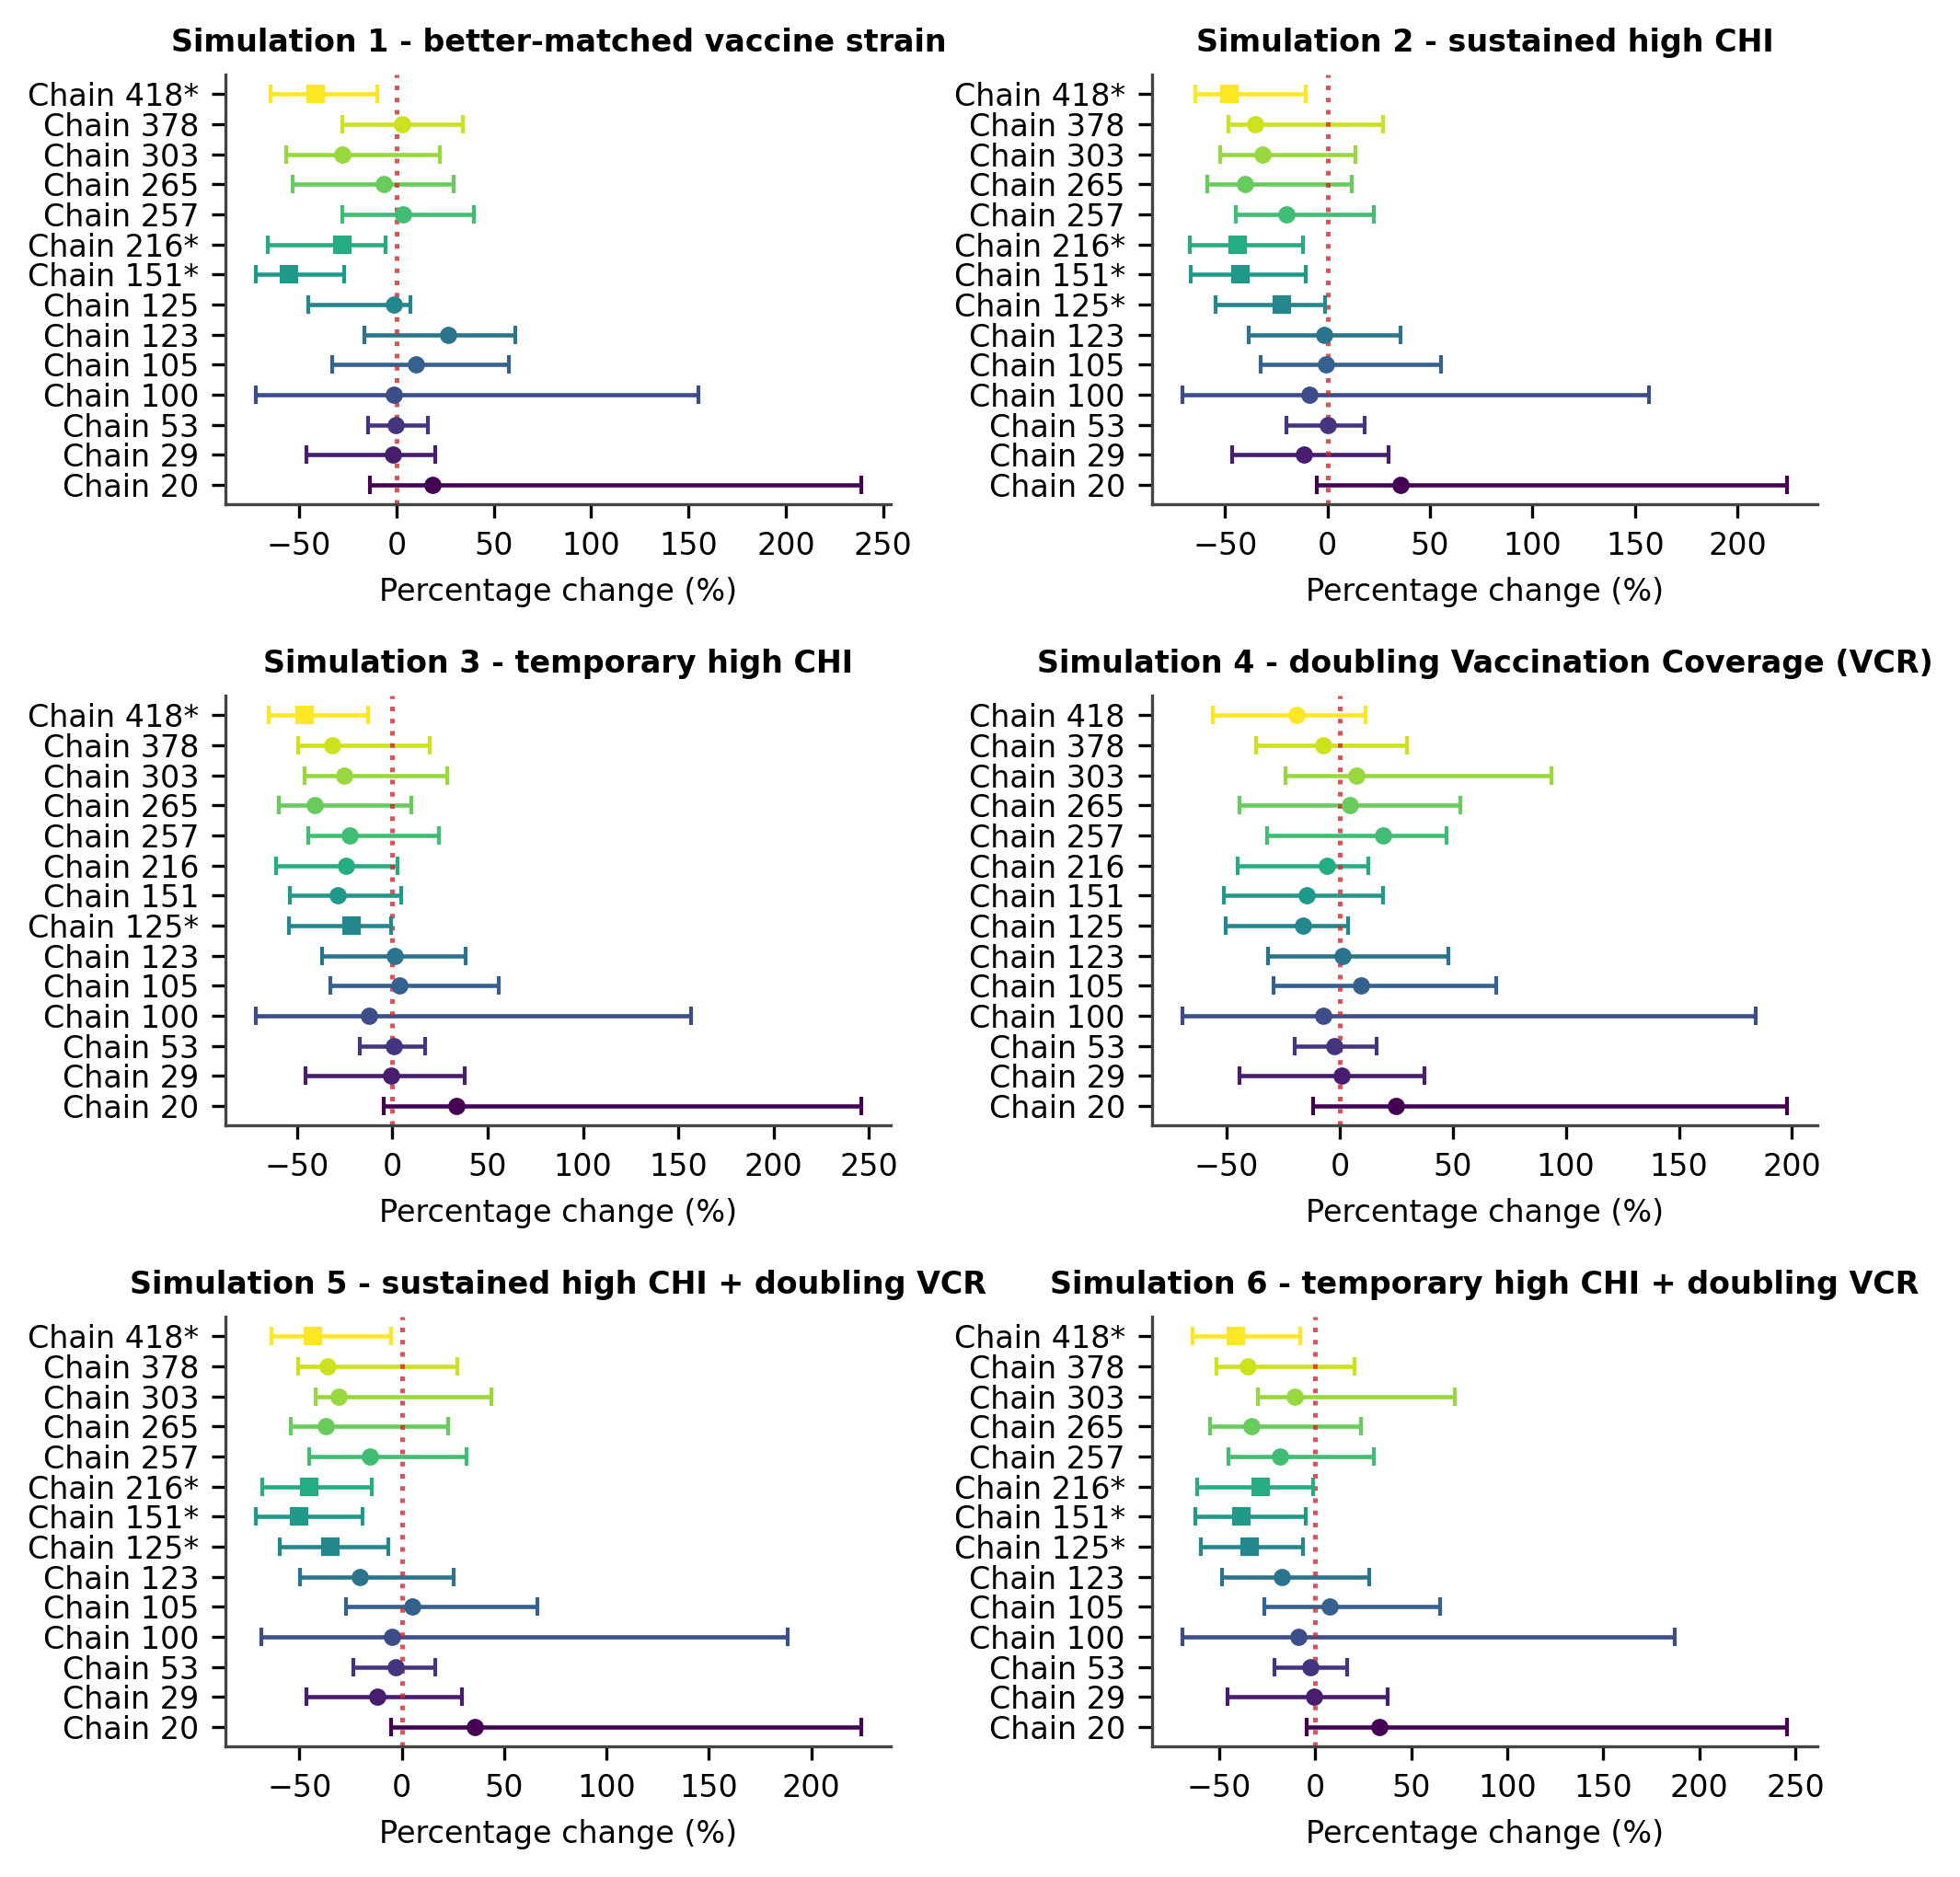

In [67]:
df = combined_df[combined_df['name2'] != 'Hospitalizations']

# Get unique name2 values
name2_values = sorted(df['Simulation'].unique())
# Get unique chain values for coloring
chains = sorted(df['chain'].unique(), key=lambda x: int(x))

def forward(x):
    return np.where(x <= 75, x, 75 + np.log10(x - 74))

# Create a numerical mapping for the y-axis
chain_to_y = {chain: i for i, chain in enumerate(chains)}

chain_colors = plt.cm.viridis(np.linspace(0, 1, len(chains)))
color_map = dict(zip(chains, chain_colors))


# Establish layout structure
ncols = 2
nrows = (len(name2_values) + ncols - 1) // ncols

# --- PLOS DIMENSION BOUNDING BOX ---
# Max allowed width: 6.81 in (17.3 cm). Max allowed height: 9.17 in (23.3 cm).
fig_width = 6.81
fig_height = min(2.3 * nrows, 9.17)  # Dynamically scales but caps safely at max height

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_width, fig_height), dpi=300)
axes = axes.flatten()

# Apply uniform editorial fonts globally
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Populate subplots
for i, name2_val in enumerate(name2_values):
    ax = axes[i]
    name2_df = df[df['Simulation'] == name2_val]
    
    # Red dotted baseline representing no statistical change
    ax.axvline(x=0, color='#d62728', linestyle='dotted', linewidth=1.2, alpha=0.8)

    # Dictionary to hold custom y-tick labels with significance flags per subplot
    subplot_yticklabels = [f'Chain {c}' for c in chains]

    for idx, chain_val in enumerate(chains):
        chain_df = name2_df[name2_df['chain'] == chain_val]

        if not chain_df.empty:
            # We assume one row per chain/simulation group for error bar metrics
            row = chain_df.iloc[0]
            val = row['percent_reduction']
            lci = row['percent_reduction_lci']
            uci = row['percent_reduction_u_ci'] if 'percent_reduction_u_ci' in row else row['percent_reduction_uci']

            # CRITERIA: If the 95% CI completely excludes 0, it is statistically significant
            is_significant = (lci > 0 and uci > 0) or (lci < 0 and uci < 0)

            # Define visual representation based on significance
            if is_significant:
                subplot_yticklabels[idx] = f'Chain {chain_val}*'
                fmt_style = 's'          # Filled circle
                ms_size = 4.0            # Slightly larger
                
            else:
                fmt_style = 'o'          # Base marker is a circle
                ms_size = 3.5            # Slightly smaller
            

            # Plot error bars
            ax.errorbar(
                val,
                chain_to_y[chain_val],
                xerr=[[val - lci], [uci - val]],
                fmt=fmt_style,
                capsize=2.5,
                elinewidth=1.1, 
                ms=ms_size,  
                color=color_map[chain_val],
                label=f'Chain {chain_val}' if i == 0 else ''
            )
    
    # Text sizing adjustments to match PLOS peer-review specifications
    ax.set_title(f'{name2_val}', fontsize=8, fontweight='bold', pad=6)
    ax.set_xlabel('Percentage change (%)', fontsize=8, labelpad=4)
    
    # Format y-axis labels explicitly incorporating asterisk flags
    ax.set_yticks(list(chain_to_y.values()))
    ax.set_yticklabels(subplot_yticklabels, fontsize=8)
    ax.tick_params(axis='x', labelsize=8)
    
    # Clean vector layout formatting
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444444')
    ax.spines['bottom'].set_color('#444444')

# Deactivate unused axis blocks
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

# Finalizing strict layout processing to match geometric scale boundaries
plt.tight_layout()

# Save final graphic artifact as uncompressed production-ready TIFF
# Filename structured precisely per PLOS automated processing pipelines
plt.savefig('Fig6.tif', format='tiff', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
modified_data.to_csv('modified_data.csv', index=False)
merged_df.to_csv('results_data.csv', index=False)